# File Path Configuration

In [1]:
BASE_DIR = "../../../input_columns_1mm/input_columns"
QSM_DIR = "../../../QSM"
SUBJECT_IDS_CSV = "../../age_prediction_on_columns_analyses/subject_ids.csv"
AGE_CSV = "../../age_prediction_on_columns_analyses/ages.csv"
METADATA_PATH = "../../../AD_DECODE_data3.xlsx"
THICKNESS_DIR = '../../../thickness_in_region'

# COLUMNS MEAN

In [2]:
import os  # For handling file paths and directories
import pandas as pd  # For working with tabular data using DataFrames
import matplotlib.pyplot as plt  # For generating plots
import zipfile  # For reading compressed files without extracting them
import re  # For extracting numerical IDs using regular expressions

import torch
import random
import numpy as np

import os
import pandas as pd
import numpy as np

import networkx as nx  # For graph-level metrics

# === Set seed for reproducibility ===
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

## Load columns

In [3]:
# Base directory where subject folders (e.g., S00775_columns_1mm) are stored
BASE_DIR = BASE_DIR

In [4]:
# List of hemispheres
HEMIS = ["lh", "rh"]

# List of cortical regions (based on the parcellation used)
REGION_NAMES = ['bankssts',
'caudalanteriorcingulate',
'caudalmiddlefrontal',
'cuneus',
'entorhinal',
'fusiform',
'inferiorparietal',
'inferiortemporal',
'isthmuscingulate',
'lateraloccipital',
'lateralorbitofrontal',
'lingual',
'medialorbitofrontal',
'middletemporal',
'parahippocampal',
'paracentral',
'parsopercularis',
'parsorbitalis',
'parstriangularis',
'pericalcarine',
'postcentral',
'posteriorcingulate',
'precentral',
'precuneus',
'rostralanteriorcingulate',
'rostralmiddlefrontal',
'superiorfrontal',
'superiorparietal',
'superiortemporal',
'supramarginal',
'frontalpole',
'temporalpole',
'transversetemporal',
'insula'
]
region_keys = [f"{hemi}_{region}" for hemi in HEMIS for region in REGION_NAMES]

In [5]:
# Paths to CSVs
SUBJECT_IDS_CSV = SUBJECT_IDS_CSV
AGE_CSV = AGE_CSV

# Load both files (no headers)
subject_df = pd.read_csv(SUBJECT_IDS_CSV, header=None)
age_df = pd.read_csv(AGE_CSV, header=None)

# Zero-pad subject IDs to 5 digits
subject_ids = subject_df[0].astype(str).apply(lambda x: x.zfill(5)).tolist()
ages = age_df[0].astype(float).tolist()

# Build dictionary: subject_id → age
age_dict = dict(zip(subject_ids, ages))
# The abnormal QSM subjects list
abnormal_qsm_subjects = [2765, 2320, 3343, 3350, 1412
                         , 1619, 3866, 2231]
# Delete the abnormal QSM subjects from the subject_df
subject_df = subject_df[~subject_df[0].isin(abnormal_qsm_subjects)]
subject_ids = subject_df[0].astype(str).apply(lambda x: x.zfill(5)).tolist()
# Filter age_dict to only include valid subject IDs
age_dict = {k: v for k, v in age_dict.items() if k in subject_ids}

# df_metadata = pd.read_excel(METADATA_PATH)
# df_metadata["MRI_Exam_fixed"] = (
#     df_metadata["MRI_Exam"]
#     .fillna(0)
#     .astype(int)
#     .astype(str)
#     .str.zfill(5)
# )
# df_metadata_cleaned = df_metadata.dropna(how="all")
# df_metadata_cleaned = df_metadata_cleaned.dropna(subset=["MRI_Exam"])
# df_matched = df_metadata_cleaned[df_metadata_cleaned["MRI_Exam_fixed"].isin(subject_ids)].copy()
# valid_ids = [sid for sid in subject_ids if sid in df_matched["MRI_Exam_fixed"].values]
# df_matched = df_matched.set_index("MRI_Exam_fixed").loc[valid_ids].reset_index()
# df_matched["Risk"] = (
#     df_matched["Risk"]
#     .fillna("NoRisk")                              # Replace NaNs
#     .replace(r'^\s*$', "NoRisk", regex=True)       # Replace empty strings or whitespace
#     .str.strip()                                   # Remove leading/trailing spaces
# )
# df_matched_filtered = df_matched[df_matched["Risk"].isin(["NoRisk", "Familial"])].copy()
# age_dict = dict(zip(df_matched_filtered["MRI_Exam_fixed"], df_matched_filtered["age"]))
# subject_ids = df_matched_filtered["MRI_Exam_fixed"].tolist()


In [6]:
# Final dictionary: subject_id -> region -> matrix
column_data_md = {}
column_data_QSM = {}
column_data_thickness = {}

# Loop through subjects
for subj_id in subject_ids:
    subj_dict = {}
    subj_dir = os.path.join(BASE_DIR, f"S{subj_id}_columns_1mm")  # Path to subject's folder
    subj_dict_thickness = {}
    subj_dir_to_thickness = os.path.join(THICKNESS_DIR, f"S{subj_id}")  # Path to subject's thickness folder
    subj_dict_QSM = {}
    subj_dir_to_QSM = os.path.join(QSM_DIR, f"S{subj_id}", "QSM")  # Path to subject's QSM folder

    for hemi in HEMIS:
        for region in REGION_NAMES:
            region_key = f"{hemi}_{region}"
            filename = f"S{subj_id}_{region_key}_md.csv"
            thickness_filename = f"S{subj_id}{region_key}_thickness.csv"
            QSM_filename = f"S{subj_id}_{region_key}_QSM.csv"
            # Construct full file path
            filepath = os.path.join(subj_dir, filename)
            thickness_filepath = os.path.join(subj_dir_to_thickness, thickness_filename)
            QSM_filepath = os.path.join(subj_dir_to_QSM, QSM_filename)

            if not os.path.exists(filepath):
                # print(f"[WARNING] Missing: {filepath}")
                continue
            if not os.path.exists(thickness_filepath):
                # print(f"[WARNING] Missing thickness file: {thickness_filepath}")
                continue

            if not os.path.exists(QSM_filepath):
                # print(f"[WARNING] Missing QSM file: {QSM_filepath}")
                continue

            # Load the thickness CSV matrix and get the mean thickness value
            thickness_mat = pd.read_csv(thickness_filepath, header=None).values.astype(np.float32)
            if thickness_mat.size == 0:
                print(f"[WARNING] Empty thickness matrix for {thickness_filepath}")
                continue
            # Calculate mean thickness for the region
            mean_thickness = np.mean(thickness_mat)
            subj_dict_thickness[region_key] = mean_thickness

            # Load MD CSV matrix as numpy array (float32)
            mat = pd.read_csv(filepath, header=None).values.astype(np.float32)
            # Add mean thickness as an additional attribute to the matrix
            if mat.size == 0:
                print(f"[WARNING] Empty matrix for {filepath}")
                continue
            subj_dict[region_key] = mat

            # Load QSM CSV matrix as numpy array (float32)
            QSM_mat = pd.read_csv(QSM_filepath, header=None).values.astype(np.float32)
            if QSM_mat.size == 0:
                print(f"[WARNING] Empty QSM matrix for {QSM_filepath}")
                continue
            subj_dict_QSM[region_key] = QSM_mat



    if len(subj_dict) > 0:
        column_data_md[subj_id] = subj_dict
    else:
        print(f"[INFO] Skipping subject {subj_id} (no valid regions found)")
    
    if len(subj_dict_thickness) > 0:
        column_data_thickness[subj_id] = subj_dict_thickness
    else:
        print(f"[INFO] Skipping subject {subj_id} (no valid regions found)")
    
    if len(subj_dict_QSM) > 0:
        column_data_QSM[subj_id] = subj_dict_QSM
    else:
        print(f"[INFO] Skipping subject {subj_id} (no valid regions found)")


# CONSTRUCT GRAPHS 

In [7]:
import os
import numpy as np
import pandas as pd
import torch
from torch_geometric.data import Data
from sklearn.neighbors import NearestNeighbors

In [8]:
# === STEP 1: Build edge_index from K-Nearest Neighbors ===

def build_knn_edge_index(x_np, k=10):
    """
    Builds the edge_index for a graph using KNN based on node features.

    Args:
        x_np (np.ndarray): shape [n_nodes, n_features]
        k (int): number of neighbors per node

    Returns:
        edge_index (torch.LongTensor): shape [2, num_edges]
    """
    knn = NearestNeighbors(n_neighbors=k, metric="euclidean")
    knn.fit(x_np)
    knn_graph = knn.kneighbors_graph(x_np).tocoo()

    edge_index = torch.tensor(
        np.vstack((knn_graph.row, knn_graph.col)),
        dtype=torch.long
    )
    return edge_index

# === STEP 2: Build PyG graph from a single subject ===

def build_graph_from_subject(subj_id, column_data, age_dict, thickness_dict=None, k=10):
    """
    Builds a PyG Data object for a subject.
    If `thickness_dict` is provided, thickness will be attached as a global feature.
    """
    subj_regions = column_data[subj_id]
    x_np = np.vstack(list(subj_regions.values()))  # shape [N, F]
    x = torch.tensor(x_np, dtype=torch.float32)

    edge_index = build_knn_edge_index(x_np, k=k)
    y = torch.tensor([age_dict[subj_id]], dtype=torch.float32)

    data = Data(x=x, edge_index=edge_index, y=y)
    data.subject_id = subj_id

    # Optional: add thickness as a global graph attribute
    if thickness_dict is not None and subj_id in thickness_dict:
        region_dict = thickness_dict[subj_id]  # dict: {region_key: value}
        
        # Use consistent ordering
        thickness_vec = [region_dict.get(key, 0.0) for key in region_keys]  # default to 0.0 for missing
        data.thickness = torch.tensor(thickness_vec, dtype=torch.float32)


    return data


# Standard scale
# Standard scale the matrices
def standard_scale(matrix):
    """
    Standard scale a single matrix: (matrix - mean) / std
    """
    mean = matrix.mean()
    std = matrix.std()
    if std != 0:
        matrix = (matrix - mean) / std
    return matrix

# Standard scale the matrices in dictionaries
def standard_scale_dict(data_dict):
    """
    Apply standard scaling to all matrices in a nested dictionary structure
    """
    for subj_id, region_data in data_dict.items():
        for region_key, matrix in region_data.items():
            data_dict[subj_id][region_key] = standard_scale(matrix)
    return data_dict

# Standard scale thickness values across all subjects
def standard_scale_thickness_dict(thickness_dict, save_stats=True, stats_filename="thickness_scaling_stats.csv"):
    """
    Apply standard scaling to thickness values across all subjects and regions
    
    Args:
        thickness_dict: Dictionary of thickness values
        save_stats: Whether to save global mean and std to CSV
        stats_filename: Filename for saving statistics
    
    Returns:
        scaled thickness_dict and tuple of (global_mean, global_std)
    """
    # First, collect all thickness values across all subjects and regions
    all_thickness_values = []
    for subj_id, region_data in thickness_dict.items():
        for region_key, thickness_value in region_data.items():
            all_thickness_values.append(thickness_value)
    
    global_mean = 2.870124
    global_std = 0.481487
        
    # Apply scaling to each subject's thickness values
    for subj_id, region_data in thickness_dict.items():
        for region_key, thickness_value in region_data.items():
            if global_std != 0:
                thickness_dict[subj_id][region_key] = (thickness_value - global_mean) / global_std
            else:
                thickness_dict[subj_id][region_key] = 0.0
    
    return thickness_dict, (global_mean, global_std)

print("Applying standard scaling to MD, QSM, and thickness data...")

# Apply standard scaling to all data
column_data_md = standard_scale_dict(column_data_md)
column_data_QSM = standard_scale_dict(column_data_QSM)
column_data_thickness, thickness_stats = standard_scale_thickness_dict(
    column_data_thickness, 
    save_stats=True, 
    stats_filename="thickness_scaling_stats.csv"
)

print("Standard scaling completed!")

# === STEP 3: Loop through all subjects and build their graphs ===
# Build MD graphs for each subject
graph_data_list_md = []
graph_data_list_QSM = []

for subj_id in subject_ids:
    if subj_id not in age_dict:
        continue

    # Build MD graph with thickness attached
    if subj_id in column_data_md and subj_id in column_data_thickness:
        md_graph = build_graph_from_subject(subj_id, column_data_md, age_dict, thickness_dict=column_data_thickness)
        graph_data_list_md.append(md_graph)

    # Build QSM graph (no thickness)
    if subj_id in column_data_QSM:
        qsm_graph = build_graph_from_subject(subj_id, column_data_QSM, age_dict)
        graph_data_list_QSM.append(qsm_graph)

# Create lookup dictionary from subject IDs to their graphs
md_dict = {data.subject_id: data for data in graph_data_list_md}
qsm_dict = {data.subject_id: data for data in graph_data_list_QSM}

# Define region keys in a fixed order
region_keys = [f"{hemi}_{region}" for hemi in HEMIS for region in REGION_NAMES]

# Build aligned list of MD, QSM graphs and thickness
aligned_graph_list = [
    (md_dict[sid], qsm_dict[sid], md_dict[sid].thickness)
    for sid in md_dict if sid in qsm_dict
]

print(len(aligned_graph_list))  # Should be ~number of subjects, e.g., 67
print(type(aligned_graph_list[0]))  # Should be tuple
print(aligned_graph_list[0][0].x.shape)  # Should be (num_nodes_for_subject, 21) — e.g., (68, 21)


Applying standard scaling to MD, QSM, and thickness data...
Standard scaling completed!
64
<class 'tuple'>
torch.Size([68, 21])


## Visualize graph

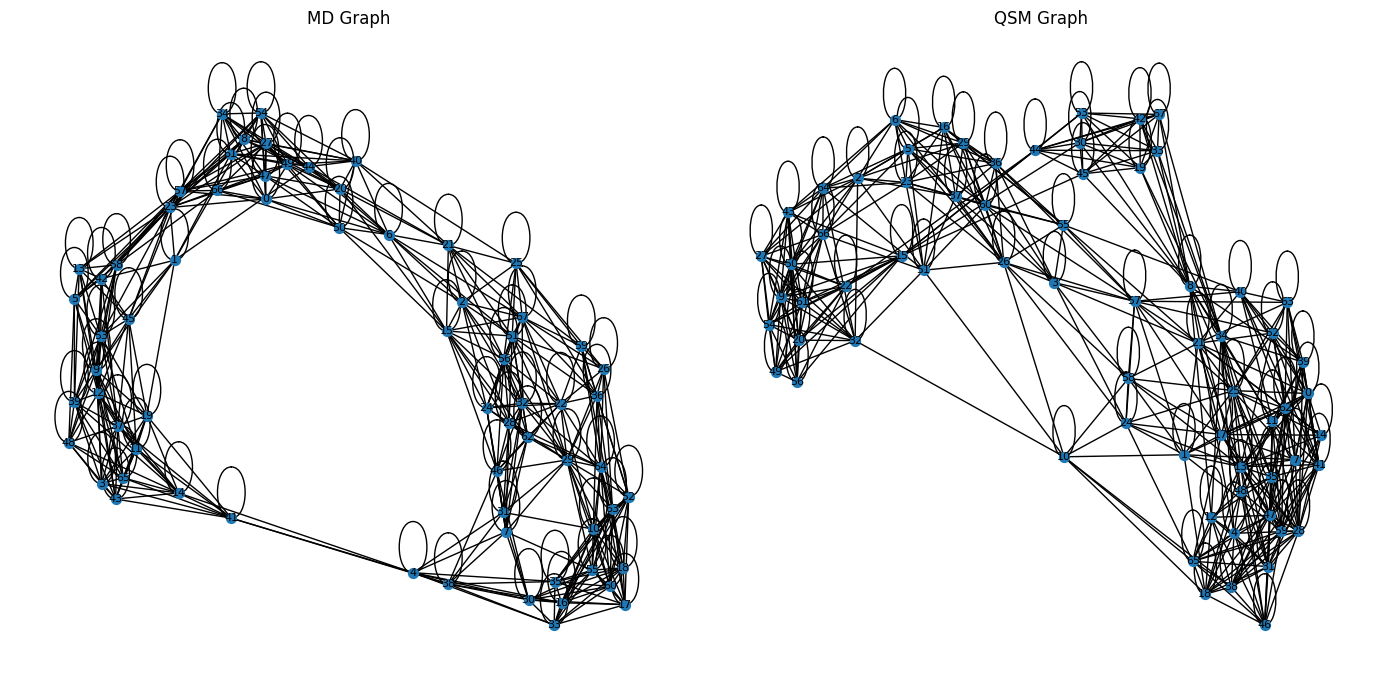

In [9]:

import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx

# === Pick the first subject's graph_md ===
graph_md = graph_data_list_md[0]

# === Convert PyG graph_md to NetworkX for visualization ===
G_md = to_networkx(graph_md, to_undirected=True)

# === Optional: layout (slower for large graphs) ===
pos_md = nx.spring_layout(G_md, seed=42)  # force-directed layout

graph_QSM = graph_data_list_QSM[0]
G_QSM = to_networkx(graph_QSM, to_undirected=True)
pos_QSM = nx.spring_layout(G_QSM, seed=42)  # force-directed layout

# === Plot the MD and QSM graphs side by side ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
# === MD Graph ===
nx.draw(G_md, pos=pos_md, with_labels=True, node_size=50, font_size=8, ax=ax1)
ax1.set_title("MD Graph")
# === QSM Graph ===
nx.draw(G_QSM, pos=pos_QSM, with_labels=True, node_size=50, font_size=8, ax=ax2)
ax2.set_title("QSM Graph")
plt.tight_layout()
plt.show()


In [10]:
# Save the graph data lists as csv files for later use
import os
os.makedirs("processed_graph_data", exist_ok=True)
torch.save(graph_data_list_md, "processed_graph_data/graph_data_list_md.pt")
torch.save(graph_data_list_QSM, "processed_graph_data/graph_data_list_QSM.pt")

# Load the graph data lists from the saved files for later use
# graph_data_list_md = torch.load("processed_graph_data/graph_data_list_md.pt")
# graph_data_list_QSM = torch.load("processed_graph_data/graph_data_list_QSM.pt")


## Apply pretraining

In [11]:
#####################  DEVICE CONFIGURATION  #######################

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [12]:
import torch
print(torch.__version__)
print(torch.version.cuda)  # should NOT be None if CUDA is enabled
print(torch.cuda.is_available())  # should be True if GPU is usable


2.5.1+cu121
12.1
True


# Define the GCN model

In [13]:
#DEFINE MODEL GCNs
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool, BatchNorm

class BrainAgeGNN(nn.Module):
    def __init__(self, input_dim=21, thickness_dim=68):  # ← match your thickness vector size
        super(BrainAgeGNN, self).__init__()

        # GCN layers for MD
        self.md_conv1 = GCNConv(input_dim, 64)
        self.md_bn1 = BatchNorm(64)
        self.md_conv2 = GCNConv(64, 128)
        self.md_bn2 = BatchNorm(128)
        self.md_conv3 = GCNConv(128, 128)
        self.md_bn3 = BatchNorm(128)

        # GCN layers for QSM
        self.qsm_conv1 = GCNConv(input_dim, 64)
        self.qsm_bn1 = BatchNorm(64)
        self.qsm_conv2 = GCNConv(64, 128)
        self.qsm_bn2 = BatchNorm(128)
        self.qsm_conv3 = GCNConv(128, 128)
        self.qsm_bn3 = BatchNorm(128)

        self.dropout = nn.Dropout(p=0.5)

        # Final MLP
        self.fc = nn.Sequential(
            nn.Linear(128 + 128 + thickness_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, data_md, data_qsm, data_thickness=None):
        # MD stream
        x_md = F.relu(self.md_bn1(self.md_conv1(data_md.x, data_md.edge_index)))
        x_md = F.relu(self.md_bn2(self.md_conv2(x_md, data_md.edge_index)))
        x_md_res = x_md
        x_md = F.relu(self.md_bn3(self.md_conv3(x_md, data_md.edge_index)))
        x_md = x_md + x_md_res
        x_md = global_mean_pool(x_md, data_md.batch)
        x_md = self.dropout(x_md)

        # QSM stream
        x_qsm = F.relu(self.qsm_bn1(self.qsm_conv1(data_qsm.x, data_qsm.edge_index)))
        x_qsm = F.relu(self.qsm_bn2(self.qsm_conv2(x_qsm, data_qsm.edge_index)))
        x_qsm_res = x_qsm
        x_qsm = F.relu(self.qsm_bn3(self.qsm_conv3(x_qsm, data_qsm.edge_index)))
        x_qsm = x_qsm + x_qsm_res
        x_qsm = global_mean_pool(x_qsm, data_qsm.batch)
        x_qsm = self.dropout(x_qsm)

        # Combine MD, QSM, and thickness
        if data_thickness is not None:
            thickness = data_thickness  # already [B, R]
            x = torch.cat([x_md, x_qsm, thickness], dim=1)
        else:
            x = torch.cat([x_md, x_qsm], dim=1)

        return self.fc(x)


In [14]:
from torch_geometric.data import Batch
def collate_fn_aligned(batch):
    md_data, qsm_data, _ = zip(*batch)  # we’ll re-fetch thickness below

    md_batch = Batch.from_data_list(md_data)
    qsm_batch = Batch.from_data_list(qsm_data)

    # Stack thickness from md_data (which now contains `.thickness`)
    thickness_tensor = torch.stack([d.thickness for d in md_data])

    return md_batch, qsm_batch, thickness_tensor

In [15]:
state = torch.load("column_md_model_trained_on_all_healthy.pt")
print("Loaded keys:", list(state.keys())[:3])


C:\Users\22679\AppData\Local\Temp\ipykernel_20996\3227729324.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load("column_md_model_trained_on_all_healthy.p

Loaded keys: ['md_conv1.bias', 'md_conv1.lin.weight', 'md_bn1.module.weight']


In [16]:
from torch_geometric.loader import DataLoader
import pandas as pd
import numpy as np
import torch

# === Load the trained model on all healthy+familial subjects ===
model = BrainAgeGNN(input_dim=21, thickness_dim=68).to(device)
import os
state = torch.load("E:\\test\\column_md_model_trained_on_all_healthy.pt")
print(model.load_state_dict(state, strict=True))  # check for missing/unexpected keys
model.eval()

# === Prepare storage for results ===
all_preds = []        # Predicted ages
all_ids = []          # Subject IDs
all_true_ages = []    # Ground-truth chronological ages

all_graph_loader = DataLoader(aligned_graph_list, batch_size=6, shuffle=False, collate_fn=collate_fn_aligned)


# === Perform inference ===
with torch.no_grad():  # Disable gradient computation for efficiency
    for data_md, data_qsm, data_thickness in all_graph_loader:
        #print(data_md.x.shape, data_md.batch.shape)  # sanity check
        data_md = data_md.to(device)  # Move data to GPU or CPU
        data_qsm = data_qsm.to(device)
        data_thickness = data_thickness.to(device)  # Move thickness to device
        output = model(data_md, data_qsm, data_thickness).view(-1)  # Predict age for each graph in the batch
        all_preds.extend(output.cpu().tolist())        # Store predictions
        all_true_ages.extend(data_md.y.cpu().tolist())    # Store true ages
        all_ids.extend(data_md.subject_id)                # Store subject IDs
        #print("Thickness shape:", data_thickness.shape)  # should be [batch_size, 68]
        #print("Sample thickness[0]:", data_thickness[0][:5])


# === Organize results into a DataFrame ===
df_results = pd.DataFrame({
    "subject_id": all_ids,
    "age": all_true_ages,
    "predicted_age": all_preds
})

df_results["BAG"] = df_results["predicted_age"] - df_results["age"]

# === Save results to CSV file ===
df_results.to_csv("column_model_predictions_all_subjects.csv", index=False)
print(" Predictions saved to 'column_model_predictions_all_subjects.csv'")
print("Pred mean:", np.mean(all_preds))
print("Pred std:", np.std(all_preds))


<All keys matched successfully>


C:\Users\22679\AppData\Local\Temp\ipykernel_20996\4093002553.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load("E:\\test\\column_md_model_trained_on_all

 Predictions saved to 'column_model_predictions_all_subjects.csv'
Pred mean: 53.575491428375244
Pred std: 14.559794009990494


# cbag

In [17]:
from sklearn.linear_model import LinearRegression
import numpy as np

# === Compute corrected BAG (cBAG) ===

# Fit linear regression: BAG ~ age
X = df_results["age"].values.reshape(-1, 1)  # Predictor: age
y = df_results["BAG"].values                # Target: BAG
reg = LinearRegression().fit(X, y)

# Predict age effect (regression line)
age_effect = reg.predict(X)

# Subtract regression line to get cBAG
df_results["cBAG"] = df_results["BAG"] - age_effect

# === Save updated results ===
df_results.to_csv("column_model_predictions_all_subjects_with_cBAG.csv", index=False)
print(" Results with cBAG saved to 'column_model_predictions_all_subjects_with_cBAG.csv'")

 Results with cBAG saved to 'column_model_predictions_all_subjects_with_cBAG.csv'


# plot bag and cbag

In [18]:
#Metadata
import pandas as pd

# === Paths ===
SUBJECT_IDS_CSV = SUBJECT_IDS_CSV
AGE_CSV = AGE_CSV
METADATA_PATH = METADATA_PATH

# === Load subject IDs and pad to 5 digits ===
subject_df = pd.read_csv(SUBJECT_IDS_CSV, header=None)
# The abnormal QSM subjects list
abnormal_qsm_subjects = [2765, 2320, 3343, 3350, 1412
                         , 1619, 3866, 2231]
# Delete the abnormal QSM subjects from the subject_df
subject_df = subject_df[~subject_df[0].isin(abnormal_qsm_subjects)]
subject_ids = subject_df[0].astype(str).apply(lambda x: x.zfill(5)).tolist()
# === Load metadata ===
df_metadata = pd.read_excel(METADATA_PATH)

df_metadata["Risk"] = df_metadata["Risk"].fillna("NoRisk")

In [19]:
# Standardize MRI Exam ID column
df_metadata["MRI_Exam_fixed"] = (
    df_metadata["MRI_Exam"]
    .fillna(0)
    .astype(int)
    .astype(str)
    .str.zfill(5)
)

# Drop fully empty rows and rows without MRI_Exam
df_metadata_cleaned = df_metadata.dropna(how="all")
df_metadata_cleaned = df_metadata_cleaned.dropna(subset=["MRI_Exam"])

# Filter metadata to only subjects we have columns for
df_matched = df_metadata_cleaned[df_metadata_cleaned["MRI_Exam_fixed"].isin(subject_ids)].copy()

# Optional: reset index
df_matched = df_matched.reset_index(drop=True)

In [20]:
# Print the statistics of the column data
print(f"\nTotal subjects with data: {len(aligned_graph_list)}")
# Print the mean age and standard deviation of ages
mean_age = np.mean(list(age_dict.values()))
std_age = np.std(list(age_dict.values()))
print(f"Mean age: {mean_age:.2f}, Standard deviation of ages: {std_age:.2f}")
# Print the range of ages
age_max = np.max(list(age_dict.values()))
age_min = np.min(list(age_dict.values()))
print(f"Age range: {age_min:.2f} - {age_max:.2f}")
# Print the statics of 'Risk' = 'None' 'AD' 'MCI' 'Familial' in metadata
risk_counts = df_matched['Risk'].value_counts()
print(f"\nRisk statistics:")
for risk_type in ['NoRisk', 'AD', 'MCI', 'Familial']:
    count = risk_counts.get(risk_type, 0)
    print(f" {risk_type}: {count} subjects")

# Print the statistics of sex
print(f"\nSex statistics:")
sex_count = df_matched['sex'].value_counts()
print(f" Famel: {sex_count.get('F', 0)}")
print(f" Male: {sex_count.get('M', 0)}")

# Print the statistics of 'genotype' = 'APOE33' 'APOE34' 'APOE44' 'APOE23'
genotype_counts = df_matched['genotype'].value_counts()
print(f"\nGenotype statistics:")
for genotype in ['APOE33', 'APOE34', 'APOE44', 'APOE23']:
    count = genotype_counts.get(genotype, 0)
    print(f" {genotype}: {count} subjects")

# Save the metadata for matched subjects
df_matched.to_csv("matched_metadata.csv", index=False)



Total subjects with data: 64
Mean age: 53.61, Standard deviation of ages: 15.01
Age range: 20.21 - 82.00

Risk statistics:
 NoRisk: 17 subjects
 AD: 1 subjects
 MCI: 4 subjects
 Familial: 42 subjects

Sex statistics:
 Famel: 37
 Male: 27

Genotype statistics:
 APOE33: 27 subjects
 APOE34: 24 subjects
 APOE44: 7 subjects
 APOE23: 6 subjects


In [21]:
# Merge predicted results with metadata
df_plot = pd.merge(df_results, df_matched, left_on="subject_id", right_on="MRI_Exam_fixed", how="left")
# Save the merged DataFrame
df_plot.to_csv("column_model_predictions_all_subjects_with_metadata.csv", index=False)
print(" Merged results saved to 'column_model_predictions_all_subjects_with_metadata.csv'")

 Merged results saved to 'column_model_predictions_all_subjects_with_metadata.csv'


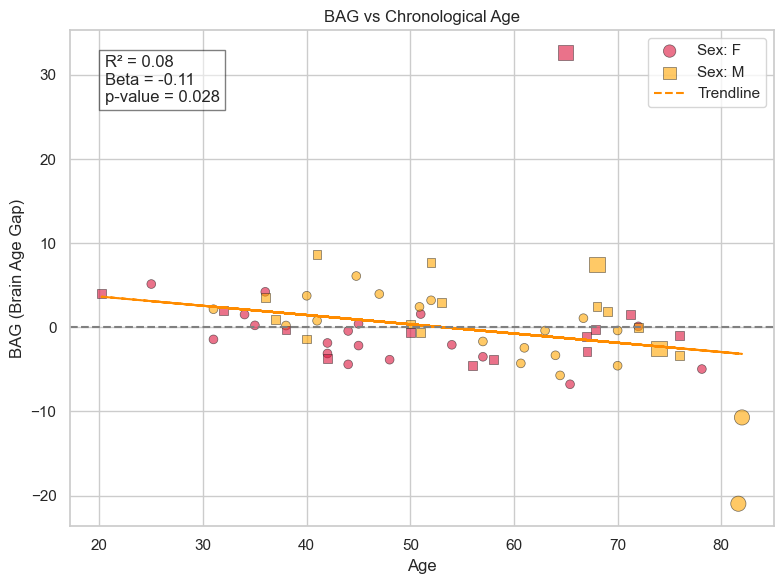

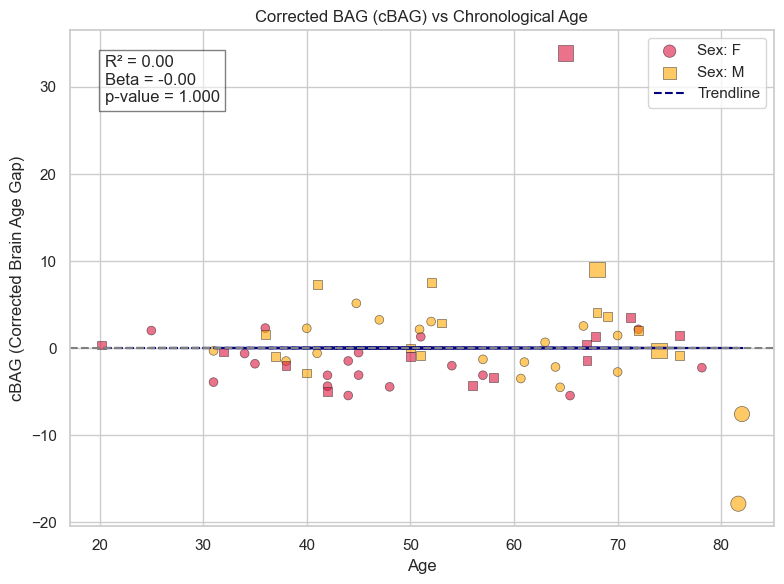

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy.stats import linregress

# For BAG
slope_bag, intercept_bag, r_value_bag, pvalue_bag, std_err_bag = linregress(df_results["age"].values, df_results["BAG"].values)

# For cBAG
slope_cbag, intercept_cbag, r_value_cbag, pvalue_cbag, std_err_cbag = linregress(df_results["age"].values, df_results["cBAG"].values)
# Set plot style
sns.set(style="whitegrid")

# ========================== Plot 1: BAG vs Age ==========================
plt.figure(figsize=(8, 6))

# Scatter plot
# Define color by APOE4 carrier status
colors = df_plot["genotype"].apply(lambda g: "crimson" if "4" in str(g) else "orange")
# Assign marker style by sex
markers = df_plot["sex"].map({"F": "o", "M": "s"}).fillna("o")
# Assign point size: larger for 'MCI' and 'AD'
sizes = df_plot["Risk"].apply(lambda r: 120 if r in ["MCI", "AD"] else 40)

# Plot each sex group separately for different marker shapes
for sex, marker in [("F", "o"), ("M", "s")]:
   idx = df_plot["sex"] == sex
   sns.scatterplot(
      x=df_results.loc[idx, "age"],
      y=df_results.loc[idx, "BAG"],
      color=colors[idx],
      marker=marker,
      alpha=0.6,
      edgecolor="k",
      label=f"Sex: {sex}",
      legend=False,
      s=sizes[idx]
   )

# Trendline
X_age = df_results["age"].values.reshape(-1, 1)
y_bag = df_results["BAG"].values
reg_bag = LinearRegression().fit(X_age, y_bag)
y_pred_bag = reg_bag.predict(X_age)

# Compute p-value using statsmodels
plt.plot(df_results["age"], y_pred_bag, color="darkorange", linestyle="--", label="Trendline")
plt.text(0.05, 0.95, f"R² = {reg_bag.score(X_age, y_bag):.2f}\nBeta = {reg_bag.coef_[0]:.2f}\np-value = {pvalue_bag:.3f}",
         transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='black'))
# Labels and style
plt.title("BAG vs Chronological Age")
plt.xlabel("Age")
plt.ylabel("BAG (Brain Age Gap)")
plt.axhline(0, linestyle="--", color="gray")
plt.legend()
plt.tight_layout()
plt.show()

# ========================== Plot 2: cBAG vs Age ==========================
plt.figure(figsize=(8, 6))

# Scatter plot
# Define color by APOE4 carrier status
colors = df_plot["genotype"].apply(lambda g: "crimson" if "4" in str(g) else "orange")
# Assign marker style by sex
markers = df_plot["sex"].map({"F": "o", "M": "s"}).fillna("o")
# Assign point size: larger for 'MCI' and 'AD'
sizes = df_plot["Risk"].apply(lambda r: 120 if r in ["MCI", "AD"] else 40)

# Plot each sex group separately for different marker shapes
for sex, marker in [("F", "o"), ("M", "s")]:
   idx = df_plot["sex"] == sex
   sns.scatterplot(
      x=df_results.loc[idx, "age"],
      y=df_results.loc[idx, "cBAG"],
      color=colors[idx],
      marker=marker,
      alpha=0.6,
      edgecolor="k",
      label=f"Sex: {sex}",
      legend=False,
      s=sizes[idx]
   )

# Trendline
y_cbag = df_results["cBAG"].values
reg_cbag = LinearRegression().fit(X_age, y_cbag)
y_pred_cbag = reg_cbag.predict(X_age)

# Compute p-value using statsmodels
plt.plot(df_results["age"], y_pred_cbag, color="navy", linestyle="--", label="Trendline")
plt.text(0.05, 0.95, f"R² = {reg_cbag.score(X_age, y_cbag):.2f}\nBeta = {reg_cbag.coef_[0]:.2f}\np-value = {pvalue_cbag:.3f}",
         transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='black'))
# Labels and style
plt.title("Corrected BAG (cBAG) vs Chronological Age")
plt.xlabel("Age")
plt.ylabel("cBAG (Corrected Brain Age Gap)")
plt.axhline(0, linestyle="--", color="gray")
plt.legend()
plt.tight_layout()
plt.show()

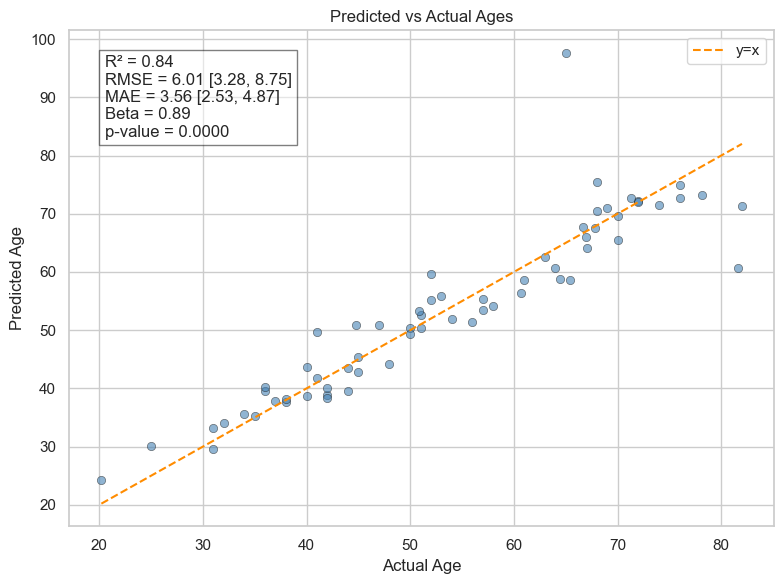

In [ ]:
# Plot the predicted vs actual ages
plt.figure(figsize=(8, 6))
# Scatter plot
sns.scatterplot(
    x=df_results["age"],
    y=df_results["predicted_age"],
    color="steelblue",
    alpha=0.6,
    edgecolor="k"
)
# Add R2, beta and p-value, RMSE +- std, MAE +- std
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
r2 = r2_score(df_results["age"], df_results["predicted_age"])
rmse = np.sqrt(mean_squared_error(df_results["age"], df_results["predicted_age"]))
mae = mean_absolute_error(df_results["age"], df_results["predicted_age"])
# Bootstrap confidence intervals for MAE and RMSE
n_bootstrap = 1000
rng = np.random.default_rng(42)
mae_samples = []
rmse_samples = []
# Empty y_true and y_pred arrays
y_true = []
y_pred = []
y_true = df_results["age"].values
y_pred = df_results["predicted_age"].values
n = len(y_true)
for _ in range(n_bootstrap):
    idx = rng.integers(0, n, n)
    mae_samples.append(mean_absolute_error(y_true[idx], y_pred[idx]))
    rmse_samples.append(np.sqrt(mean_squared_error(y_true[idx], y_pred[idx])))
mae_ci = np.percentile(mae_samples, [2.5, 97.5])
rmse_ci = np.percentile(rmse_samples, [2.5, 97.5])
# Calculate beta and p-value based on the model
X = df_results["age"].values.reshape(-1, 1)
y = df_results["predicted_age"].values
reg = LinearRegression().fit(X, y)
beta = reg.coef_[0]
pvalue = linregress(df_results["age"], df_results["predicted_age"]).pvalue
plt.text(
    0.05, 0.95,
    f"R² = {r2:.2f}\n"
    f"RMSE = {rmse:.2f} [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]\n"
    f"MAE = {mae:.2f} [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]\n"
    f"Beta = {beta:.2f}\n"
    f"p-value = {pvalue:.4f}",
    transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.5, edgecolor='black')
)
# plt.text(0.05, 0.95, f"R² = {r2:.2f}\nRMSE = {rmse:.2f} ± {std_rmse:.2f}\nMAE = {mae:.2f} ± {std_mae:.2f}\nBeta = {beta:.2f}\np-value = {pvalue:.4f}",
#          transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
#             bbox=dict(facecolor='white', alpha=0.5, edgecolor='black'))
# plt.text(0.05, 0.95, f"R² = {r2:.2f}\nRMSE = {rmse:.2f}\nMAE = {mae:.2f}\nBeta = {beta:.2f}\np-value = {pvalue:.2e}",
#          transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
#          bbox=dict(facecolor='white', alpha=0.5, edgecolor='black'))
# Labels and style
plt.title("Predicted vs Actual Ages")
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.plot([df_results["age"].min(), df_results["age"].max()],
         [df_results["age"].min(), df_results["age"].max()],
         color="darkorange", linestyle="--", label="y=x")
plt.legend()
plt.tight_layout()
plt.show()


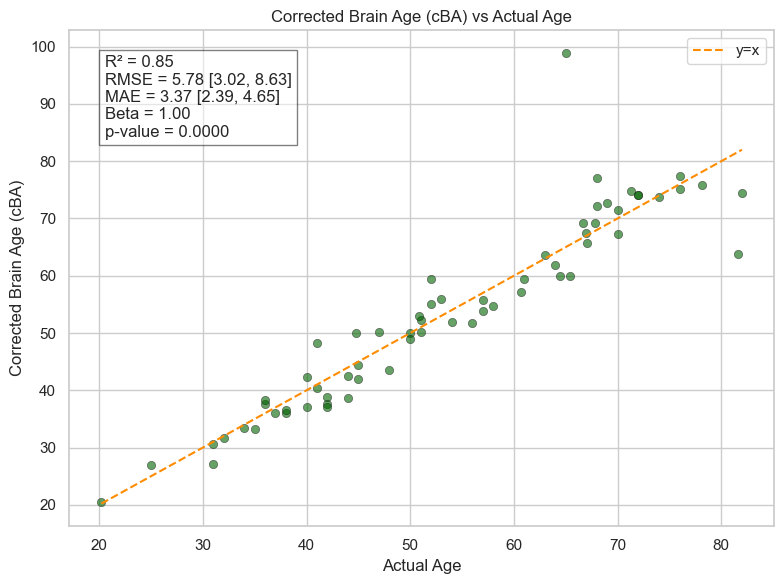

In [26]:
# Plot the corrected Brain age (cBA) vs age
plt.figure(figsize=(8, 6))
# Scatter plot
sns.scatterplot(
    x=df_results["age"],
    y=df_results["age"] + df_results["cBAG"],
    color="darkgreen",
    alpha=0.6,
    edgecolor="k"
)
# Add R2, beta and p-value, RMSE +- std, MAE +- std
r2 = r2_score(df_results["age"], df_results["age"] + df_results["cBAG"])
rmse = np.sqrt(mean_squared_error(df_results["age"], df_results["age"] + df_results["cBAG"]))
mae = mean_absolute_error(df_results["age"], df_results["age"] + df_results["cBAG"])
# Bootstrap confidence intervals for MAE and RMSE
n_bootstrap = 1000
rng = np.random.default_rng(42)
mae_samples = []
rmse_samples = []
y_true = df_results["age"].values
y_pred = df_results["age"].values + df_results["cBAG"].values
n = len(y_true)
for _ in range(n_bootstrap):
    idx = rng.integers(0, n, n)
    mae_samples.append(mean_absolute_error(y_true[idx], y_pred[idx]))
    rmse_samples.append(np.sqrt(mean_squared_error(y_true[idx], y_pred[idx])))
mae_ci = np.percentile(mae_samples, [2.5, 97.5])
rmse_ci = np.percentile(rmse_samples, [2.5, 97.5])
# Calculate beta and p-value based on the model
X = df_results["age"].values.reshape(-1, 1)
y = df_results["age"] + df_results["cBAG"]
reg = LinearRegression().fit(X, y)
beta = reg.coef_[0]
pvalue = linregress(df_results["age"], df_results["age"] + df_results["cBAG"]).pvalue
plt.text(
    0.05, 0.95,
    f"R² = {r2:.2f}\n"
    f"RMSE = {rmse:.2f} [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]\n"
    f"MAE = {mae:.2f} [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]\n"
    f"Beta = {beta:.2f}\n"
    f"p-value = {pvalue:.4f}",
    transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.5, edgecolor='black')
)
# plt.text(0.05, 0.95, f"R² = {r2:.2f}\nRMSE = {rmse:.2f} ± {std_rmse:.2f}\nMAE = {mae:.2f} ± {std_mae:.2f}\nBeta = {beta:.2f}\np-value = {pvalue:.4f}",
#          transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
#             bbox=dict(facecolor='white', alpha=0.5, edgecolor='black'))
# plt.text(0.05, 0.95, f"R² = {r2:.2f}\nRMSE = {rmse:.2f}\nMAE = {mae:.2f}\nBeta = {beta:.2f}\np-value = {pvalue:.2e}",
#          transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
#          bbox=dict(facecolor='white', alpha=0.5, edgecolor='black'))
# Labels and style
plt.title("Corrected Brain Age (cBA) vs Actual Age")
plt.xlabel("Actual Age")
plt.ylabel("Corrected Brain Age (cBA)")
plt.plot([df_results["age"].min(), df_results["age"].max()],
         [df_results["age"].min(), df_results["age"].max()],
         color="darkorange", linestyle="--", label="y=x")
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\22679\AppData\Local\Temp\ipykernel_26844\2810264676.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x="Risk", y="BAG", inner="point", palette="pastel")


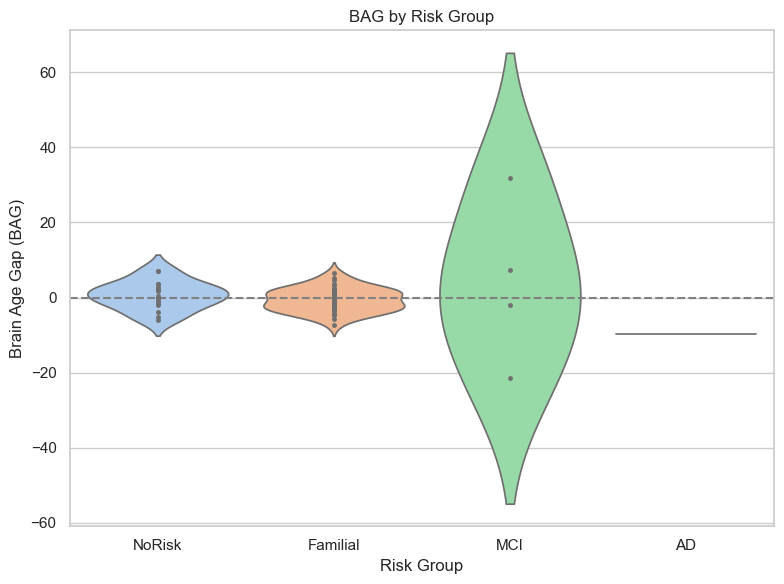

C:\Users\22679\AppData\Local\Temp\ipykernel_26844\2810264676.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x="Risk", y="cBAG", inner="point", palette="pastel")


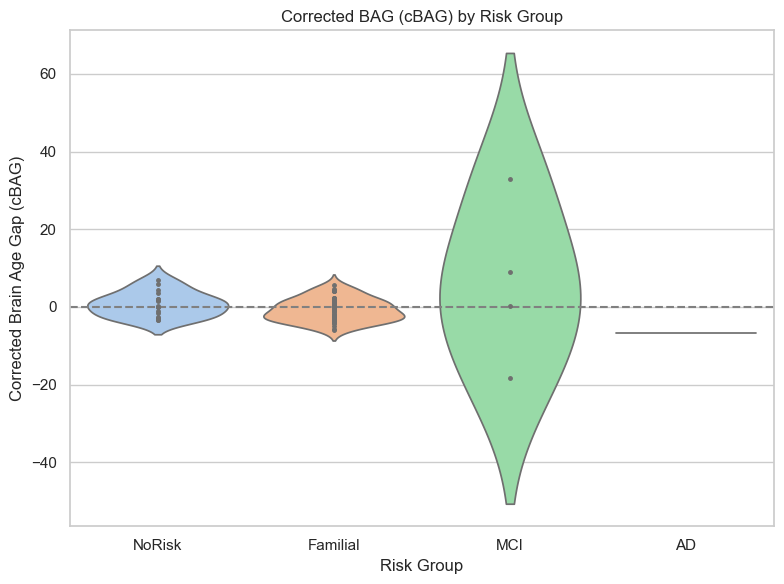

In [24]:
#Violin plots RISK
import seaborn as sns
import matplotlib.pyplot as plt

# Set plot style
sns.set(style="whitegrid")

# === BAG by Risk group ===
plt.figure(figsize=(8, 6))
sns.violinplot(data=df_plot, x="Risk", y="BAG", inner="point", palette="pastel")
plt.axhline(0, linestyle="--", color="gray")
plt.title("BAG by Risk Group")
plt.ylabel("Brain Age Gap (BAG)")
plt.xlabel("Risk Group")
plt.tight_layout()
plt.show()

# === cBAG by Risk group ===
plt.figure(figsize=(8, 6))
sns.violinplot(data=df_plot, x="Risk", y="cBAG", inner="point", palette="pastel")
plt.axhline(0, linestyle="--", color="gray")
plt.title("Corrected BAG (cBAG) by Risk Group")
plt.ylabel("Corrected Brain Age Gap (cBAG)")
plt.xlabel("Risk Group")
plt.tight_layout()
plt.show()

C:\Users\22679\AppData\Local\Temp\ipykernel_26844\1110768381.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x="Risk_combined", y="BAG", inner="point", palette="pastel")


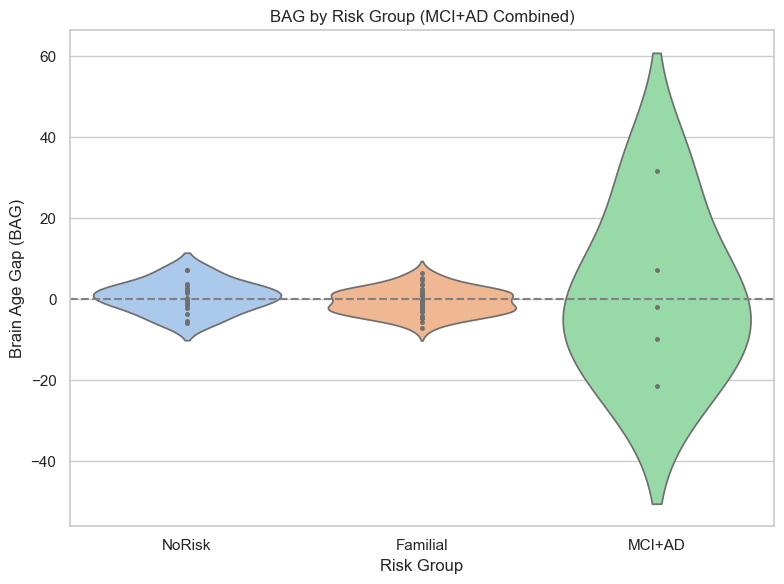

C:\Users\22679\AppData\Local\Temp\ipykernel_26844\1110768381.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x="Risk_combined", y="cBAG", inner="point", palette="pastel")


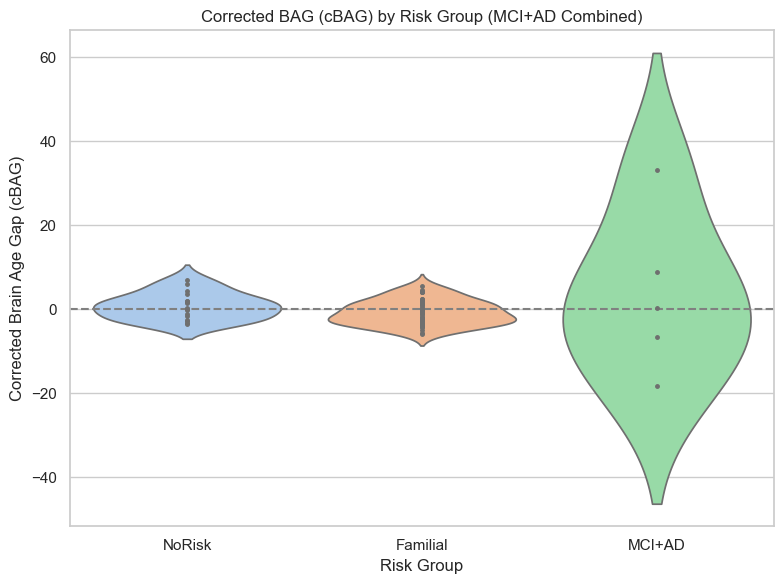

In [25]:
# Set plot style
sns.set(style="whitegrid")

# Combine MCI and AD into one group labeled as 'MCI+AD'
df_plot["Risk_combined"] = df_plot["Risk"].replace({"MCI": "MCI+AD", "AD": "MCI+AD"})

# === BAG by Risk group (combined) ===
plt.figure(figsize=(8, 6))
sns.violinplot(data=df_plot, x="Risk_combined", y="BAG", inner="point", palette="pastel")
plt.axhline(0, linestyle="--", color="gray")
plt.title("BAG by Risk Group (MCI+AD Combined)")
plt.ylabel("Brain Age Gap (BAG)")
plt.xlabel("Risk Group")
plt.tight_layout()
plt.show()

# === cBAG by Risk group ===
plt.figure(figsize=(8, 6))
sns.violinplot(data=df_plot, x="Risk_combined", y="cBAG", inner="point", palette="pastel")
plt.axhline(0, linestyle="--", color="gray")
plt.title("Corrected BAG (cBAG) by Risk Group (MCI+AD Combined)")
plt.ylabel("Corrected Brain Age Gap (cBAG)")
plt.xlabel("Risk Group")
plt.tight_layout()
plt.show()

C:\Users\22679\AppData\Local\Temp\ipykernel_26844\4064984708.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x="sex", y="BAG", inner="point", palette="pastel")


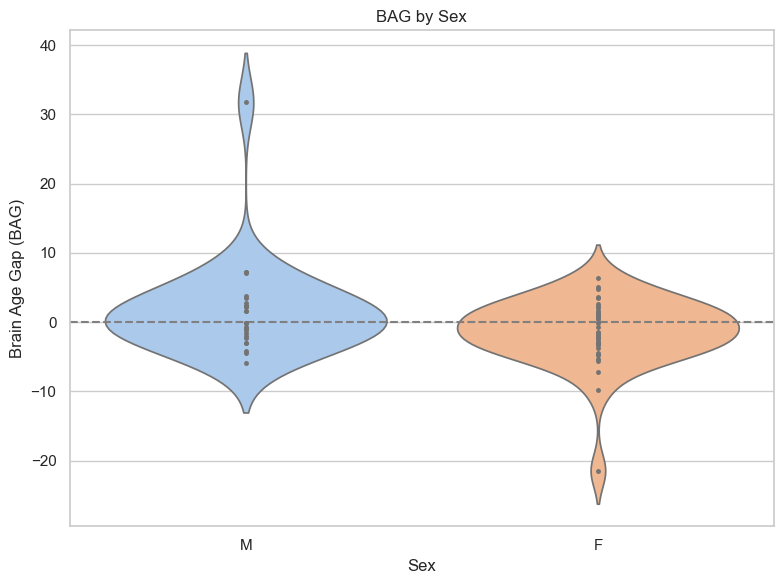

C:\Users\22679\AppData\Local\Temp\ipykernel_26844\4064984708.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x="sex", y="cBAG", inner="point", palette="pastel")


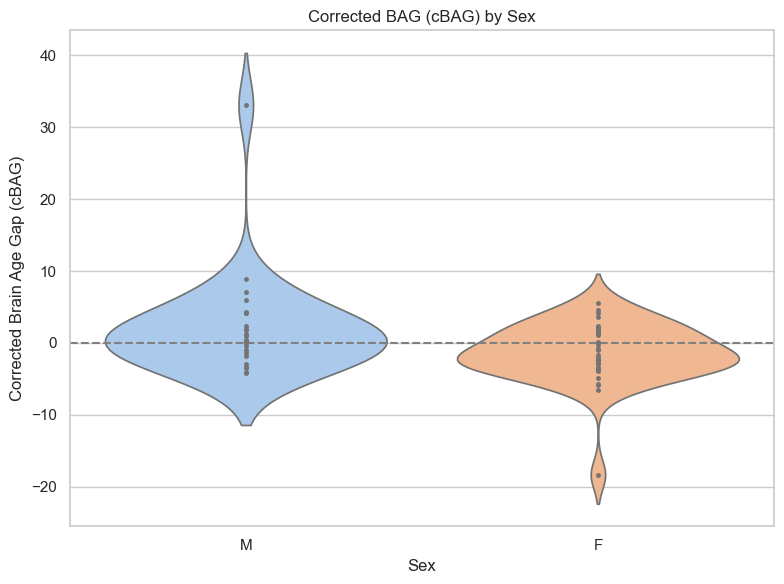

In [26]:
# Set plot style
sns.set(style="whitegrid")

# BAG by sex
plt.figure(figsize=(8, 6))
sns.violinplot(data=df_plot, x="sex", y="BAG", inner="point", palette="pastel")
plt.axhline(0, linestyle="--", color="gray")
plt.title("BAG by Sex")
plt.ylabel("Brain Age Gap (BAG)")
plt.xlabel("Sex")
plt.tight_layout()
plt.show()

# cBAG by sex
plt.figure(figsize=(8, 6))
sns.violinplot(data=df_plot, x="sex", y="cBAG", inner="point", palette="pastel")
plt.axhline(0, linestyle="--", color="gray")
plt.title("Corrected BAG (cBAG) by Sex")
plt.ylabel("Corrected Brain Age Gap (cBAG)")
plt.xlabel("Sex")
plt.tight_layout()
plt.show()

C:\Users\22679\AppData\Local\Temp\ipykernel_26844\1917420560.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x="genotype", y="BAG", inner="point", palette="muted", order=genotype_order)


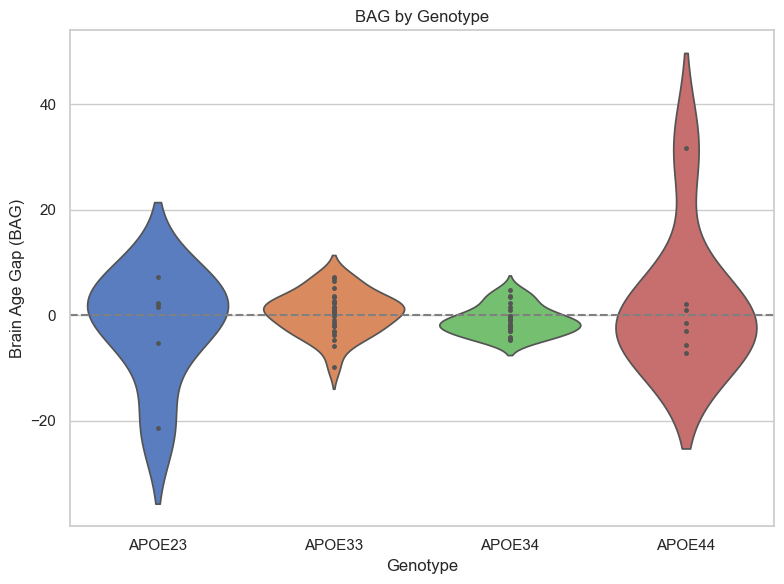

C:\Users\22679\AppData\Local\Temp\ipykernel_26844\1917420560.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x="genotype", y="cBAG", inner="point", palette="muted", order=genotype_order)


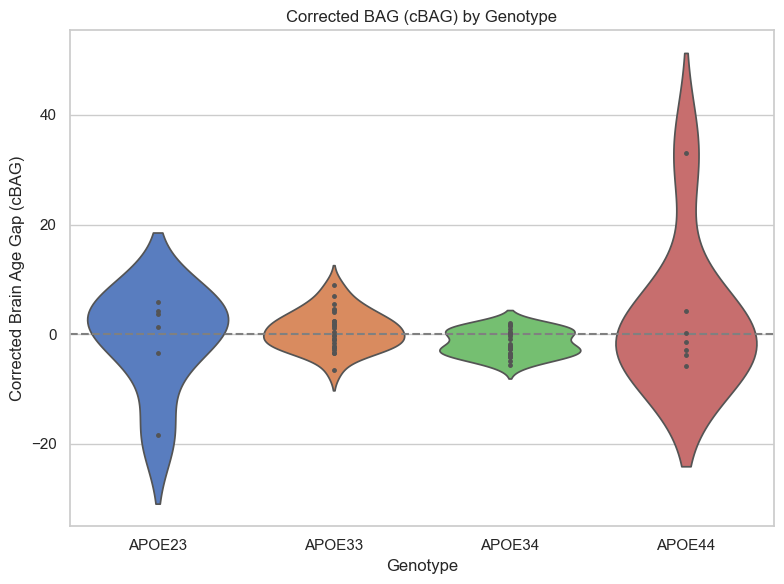

In [27]:
#VIOLIN GENOTYPE
import seaborn as sns
import matplotlib.pyplot as plt

# Set seaborn style
sns.set(style="whitegrid")

# Define correct APOE genotype order
genotype_order = ["APOE23", "APOE33", "APOE34", "APOE44"]

# === BAG by Genotype (ordered) ===
plt.figure(figsize=(8, 6))
sns.violinplot(data=df_plot, x="genotype", y="BAG", inner="point", palette="muted", order=genotype_order)
plt.axhline(0, linestyle="--", color="gray")
plt.title("BAG by Genotype")
plt.xlabel("Genotype")
plt.ylabel("Brain Age Gap (BAG)")
plt.tight_layout()
plt.show()

# === cBAG by Genotype (ordered) ===
plt.figure(figsize=(8, 6))
sns.violinplot(data=df_plot, x="genotype", y="cBAG", inner="point", palette="muted", order=genotype_order)
plt.axhline(0, linestyle="--", color="gray")
plt.title("Corrected BAG (cBAG) by Genotype")
plt.xlabel("Genotype")
plt.ylabel("Corrected Brain Age Gap (cBAG)")
plt.tight_layout()
plt.show()

C:\Users\22679\AppData\Local\Temp\ipykernel_26844\1921486781.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x="APOE", y="BAG", inner="point", palette="pastel")


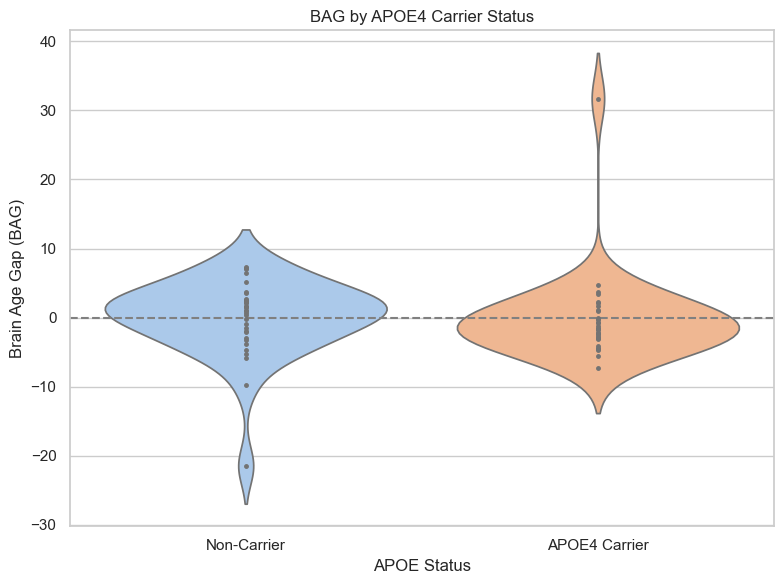

C:\Users\22679\AppData\Local\Temp\ipykernel_26844\1921486781.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x="APOE", y="cBAG", inner="point", palette="pastel")


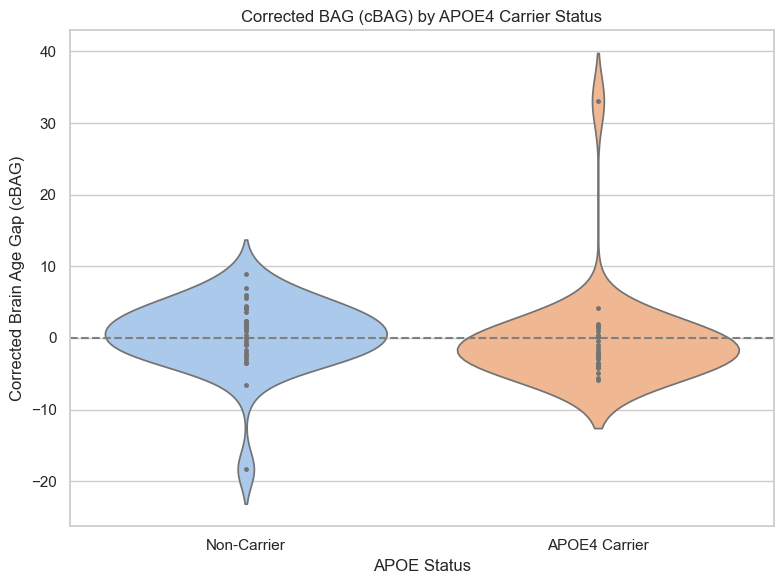

In [28]:
#Violin genotype 4+ or 4-
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style
sns.set(style="whitegrid")

# Define new APOE status based on genotype
def define_apoe_status(genotype):
    if "4" in genotype:
        return "APOE4 Carrier"
    else:
        return "Non-Carrier"
# Apply the function to create a new column
df_plot["APOE"] = df_plot["genotype"].apply(define_apoe_status)

# === BAG by APOE status ===
plt.figure(figsize=(8, 6))
sns.violinplot(data=df_plot, x="APOE", y="BAG", inner="point", palette="pastel")
plt.axhline(0, linestyle="--", color="gray")
plt.title("BAG by APOE4 Carrier Status")
plt.xlabel("APOE Status")
plt.ylabel("Brain Age Gap (BAG)")
plt.tight_layout()
plt.show()

# === cBAG by APOE status ===
plt.figure(figsize=(8, 6))
sns.violinplot(data=df_plot, x="APOE", y="cBAG", inner="point", palette="pastel")
plt.axhline(0, linestyle="--", color="gray")
plt.title("Corrected BAG (cBAG) by APOE4 Carrier Status")
plt.xlabel("APOE Status")
plt.ylabel("Corrected Brain Age Gap (cBAG)")
plt.tight_layout()
plt.show()

# Saliency (updated)

This section computes feature attributions **w.r.t. node features** for any PyTorch GNN model
using Captum's `IntegratedGradients` (robust to architecture changes). It wraps the model so we
can pass in a flattened feature vector and rebuild a `torch_geometric.data.Data` object using a
template graph (same topology/metadata), making it agnostic to your current model's `forward` signature.


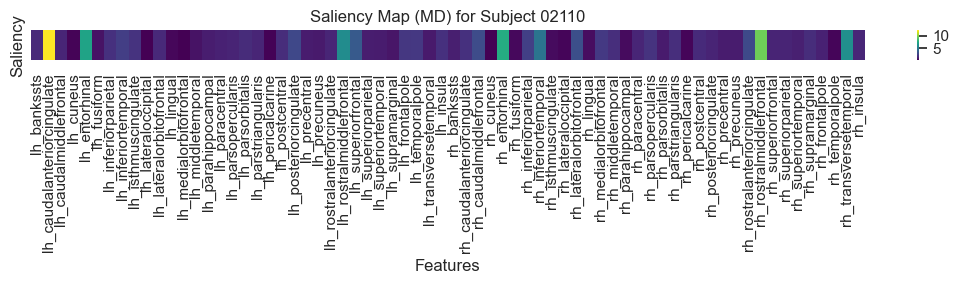

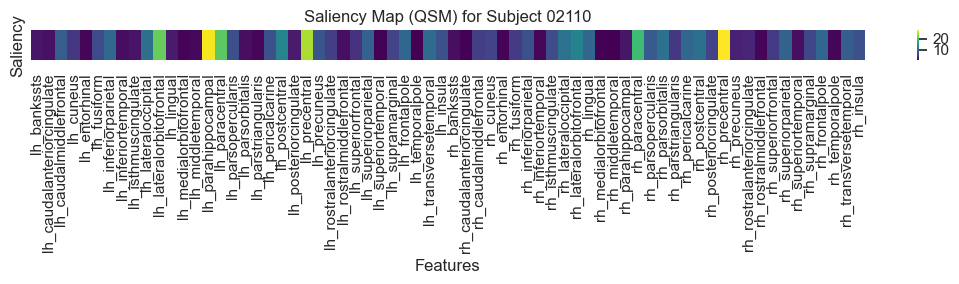

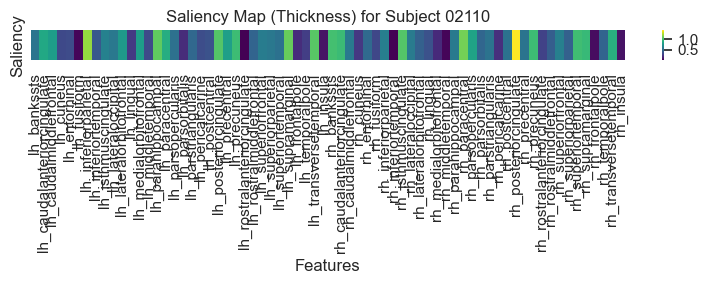

In [29]:
# Saliency maps
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances


# === Function to compute saliency maps ===

def compute_saliency_map(model, subject_graph, target_class=None):
    """
    Computes the saliency map for a given graph data. (region)

    Args:
        model (torch.nn.Module): Trained model.
        subject_graph (torch_geometric.data.Data): Subject graph data.
        target_class (int, optional): Class index to compute saliency for. If None, uses the model's output.

    Returns:
        saliency_map (np.ndarray): Saliency map for the graph.
    """
    # Set model to evaluation mode
    model.eval()

    # Forward pass
    data_md, data_qsm, _= subject_graph
    data_thickness = data_md.thickness.unsqueeze(0).to(device)  # Add batch dimension
    data_md = data_md.to(device)
    data_qsm = data_qsm.to(device)
    data_thickness.requires_grad = True
    data_md.x.requires_grad = True
    data_qsm.x.requires_grad = True

    output = model(data_md, data_qsm, data_thickness)

    # If target_class is not provided, use the model's output
    if target_class is None:
        target_class = output.argmax(dim=0).item()

    # Zero gradients
    model.zero_grad()

    # Backward pass to compute gradients
    output[0].backward()

    # Get gradients and convert to numpy
    gradients_md = data_md.x.grad.cpu().numpy()
    saliency_map_md = np.abs(gradients_md).sum(axis=1)  # Sum gradients across features

    gradients_qsm = data_qsm.x.grad.cpu().numpy()
    saliency_map_qsm = np.abs(gradients_qsm).sum(axis=1)  # Sum gradients across features

    gradients_thickness = data_thickness.grad.cpu().numpy()
    saliency_map_thickness = np.abs(gradients_thickness)

    return saliency_map_md, saliency_map_qsm, saliency_map_thickness

def compute_saliency_map_by_layer(model, subject_graph, target_class=None):
    """
    Computes the saliency map for a given graph data. (region)

    Args:
        model (torch.nn.Module): Trained model.
        subject_graph (torch_geometric.data.Data): Subject graph data.
        target_class (int, optional): Class index to compute saliency for. If None, uses the model's output.

    Returns:
        saliency_map (np.ndarray): Saliency map for the graph.
    """
    # Set model to evaluation mode
    model.eval()

    # Forward pass
    data_md, data_qsm, _= subject_graph
    data_thickness = data_md.thickness.unsqueeze(0).to(device)  # Add batch dimension
    data_md = data_md.to(device)
    data_qsm = data_qsm.to(device)
    data_thickness.requires_grad = True
    data_md.x.requires_grad = True
    data_qsm.x.requires_grad = True

    output = model(data_md, data_qsm, data_thickness)

    # If target_class is not provided, use the model's output
    if target_class is None:
        target_class = output.argmax(dim=0).item()

    # Zero gradients
    model.zero_grad()

    # Backward pass to compute gradients
    output[0].backward()

    # Get gradients and convert to numpy
    gradients_md = data_md.x.grad.cpu().numpy()
    saliency_map_md = np.abs(gradients_md)  # Sum gradients across features

    gradients_qsm = data_qsm.x.grad.cpu().numpy()
    saliency_map_qsm = np.abs(gradients_qsm)# Sum gradients across features

    return saliency_map_md, saliency_map_qsm

# === Function to visualize saliency map ===
def visualize_saliency_map(saliency_map, title="Saliency Map"):
    """
    Visualizes the saliency map as a heatmap.

    Args:
        saliency_map (np.ndarray): Saliency map to visualize.
        title (str, optional): Title of the plot.
    """
    xlabel = []
    for hemi in HEMIS:
        for region in REGION_NAMES:
            region_key = f"{hemi}_{region}"
            xlabel.append(region_key)
    plt.figure(figsize=(max(8, len(saliency_map) // 6), 3))
    ax = sns.heatmap(saliency_map.reshape(1, -1), cmap="viridis", cbar=True, 
                     xticklabels=xlabel, yticklabels=False)
    ax.set_xticks(np.arange(len(xlabel)) + 0.5)
    ax.set_xticklabels(xlabel, rotation=90, ha='center')
    plt.title(title)
    plt.xlabel("Features")
    plt.ylabel("Saliency")
    plt.tight_layout()
    plt.show()

# === Function to visualize saliency map with PCA ===
def visualize_saliency_map_pca(saliency_map, title="Saliency Map (PCA)"):
    """
    Visualizes the saliency map after applying PCA.

    Args:
        saliency_map (np.ndarray): Saliency map to visualize.
        title (str, optional): Title of the plot.
    """
    # Apply PCA to reduce dimensionality
    pca = PCA(n_components=2)
    saliency_map_pca = pca.fit_transform(saliency_map.reshape(-1, 1))

    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=saliency_map_pca[:, 0], y=saliency_map_pca[:, 1], cmap="viridis")
    plt.title(title)
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.tight_layout()
    plt.show()
# Choose a subject's graph
subject_graph = aligned_graph_list[0]  # Replace with the desired subject's graph
# Compute saliency map
saliency_map_md, saliency_map_qsm, saliency_map_thickness = compute_saliency_map(model, subject_graph)
# Visualize saliency map
visualize_saliency_map(saliency_map_md, title="Saliency Map (MD) for Subject " + str(subject_graph[0].subject_id))
visualize_saliency_map(saliency_map_qsm, title="Saliency Map (QSM) for Subject " + str(subject_graph[0].subject_id))
visualize_saliency_map(saliency_map_thickness, title="Saliency Map (Thickness) for Subject " + str(subject_graph[0].subject_id))


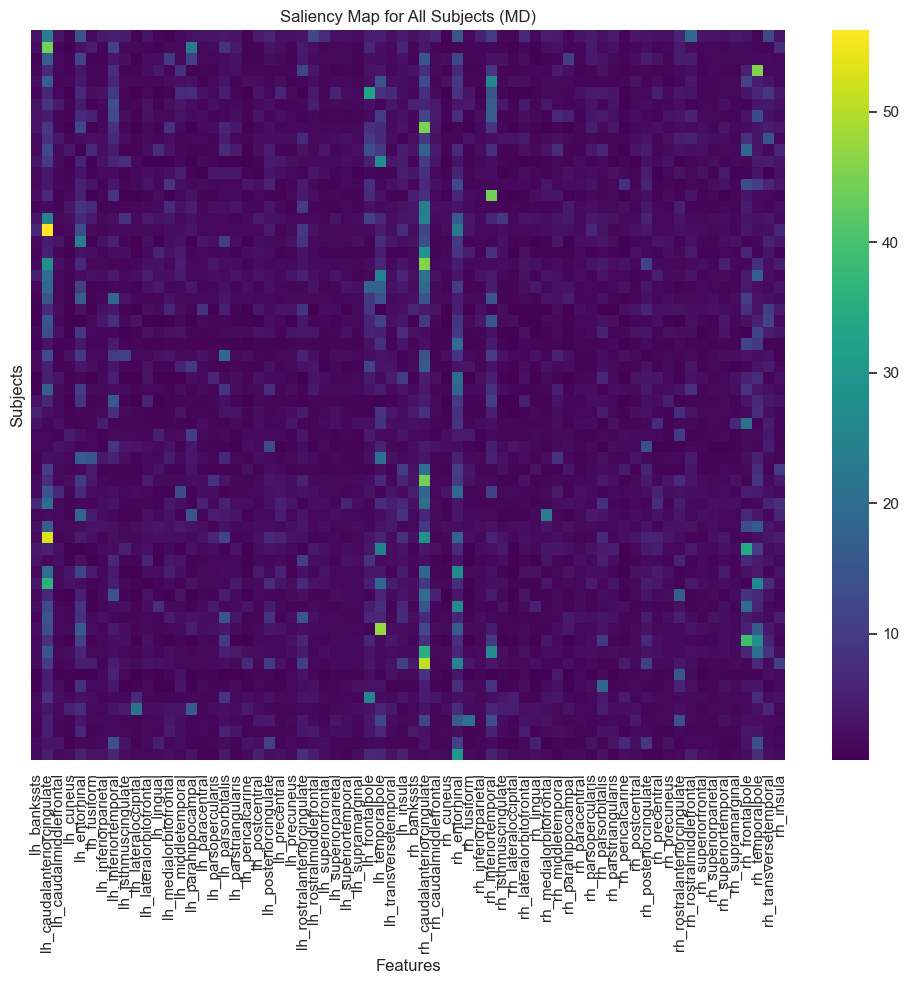

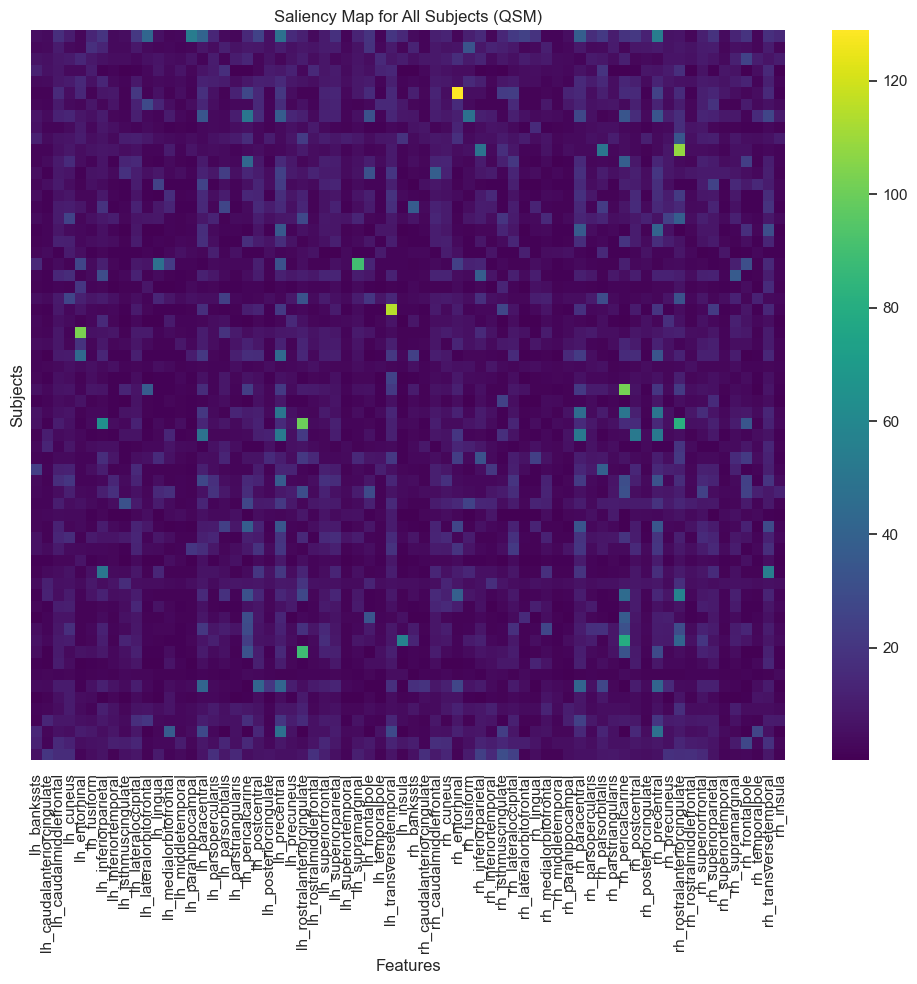

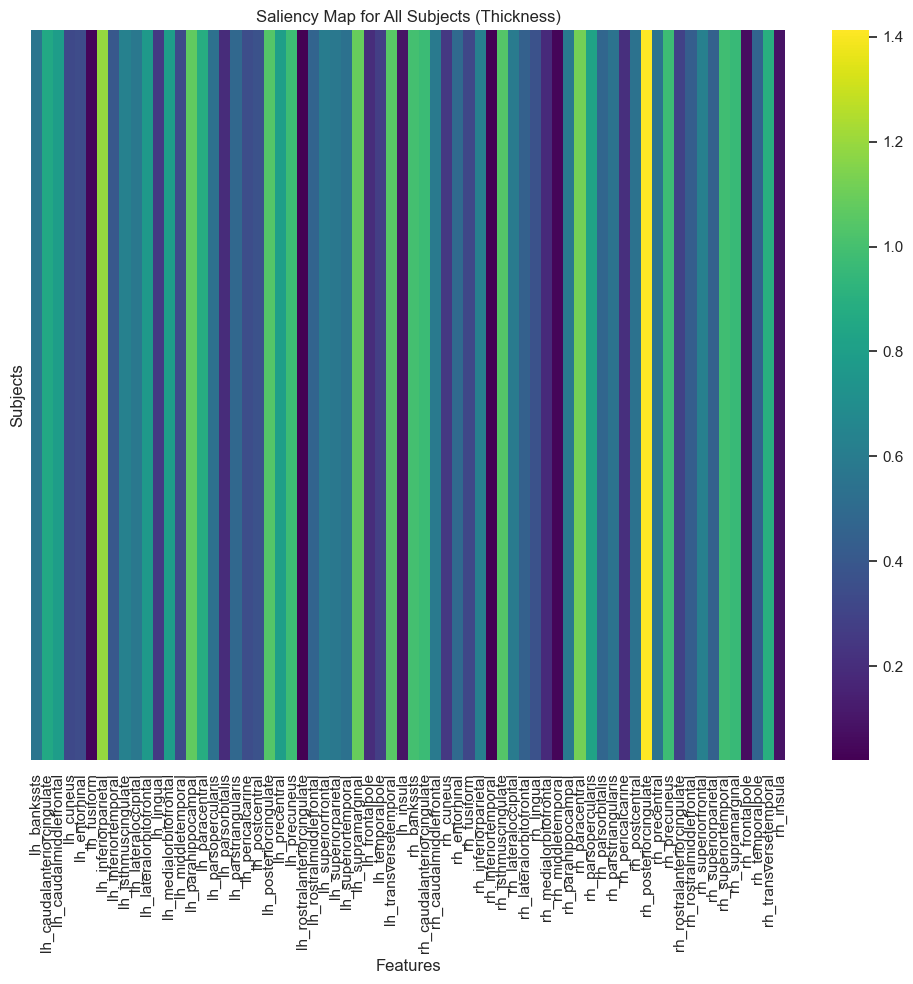

In [30]:
# Plot the saliency map of all subjects stacked
saliency_maps_md_all = []
saliency_maps_qsm_all = []
saliency_maps_thickness_all = []
for graph in aligned_graph_list:
    saliency_map_md, saliency_map_qsm, saliency_map_thickness = compute_saliency_map(model, graph)
    saliency_maps_md_all.append(saliency_map_md)
    saliency_maps_qsm_all.append(saliency_map_qsm)
    # Squeeze thickness saliency to shape (68,)
    saliency_maps_thickness_all.append(np.squeeze(saliency_map_thickness))

# Convert to numpy array
saliency_maps_md_all = np.array(saliency_maps_md_all)
saliency_maps_qsm_all = np.array(saliency_maps_qsm_all)
saliency_maps_thickness_all = np.array(saliency_maps_thickness_all)

# Visualize MD saliency map for all subjects
xlabel = []
for hemi in HEMIS:
    for region in REGION_NAMES:
        region_key = f"{hemi}_{region}"
        xlabel.append(region_key)
plt.figure(figsize=(max(8, len(saliency_maps_md_all) // 6),10))  # Adjust figure size based on number of subjects
ax = sns.heatmap(saliency_maps_md_all, cmap="viridis", cbar=True,
                    xticklabels=xlabel, yticklabels=False)
ax.set_xticks(np.arange(len(xlabel)) + 0.5)
ax.set_xticklabels(xlabel, rotation=90, ha='center')
plt.title("Saliency Map for All Subjects (MD)")
plt.xlabel("Features")
plt.ylabel("Subjects")
plt.tight_layout()
plt.show()

# Visualize QSM saliency map for all subjects
plt.figure(figsize=(max(8, len(saliency_maps_qsm_all) // 6),10))  # Adjust figure size based on number of subjects
ax = sns.heatmap(saliency_maps_qsm_all, cmap="viridis", cbar=True,
                    xticklabels=xlabel, yticklabels=False)
ax.set_xticks(np.arange(len(xlabel)) + 0.5)
ax.set_xticklabels(xlabel, rotation=90, ha='center')
plt.title("Saliency Map for All Subjects (QSM)")
plt.xlabel("Features")
plt.ylabel("Subjects")
plt.tight_layout()
plt.show()

# Visualize Thickness saliency map for all subjects
plt.figure(figsize=(max(8, len(saliency_maps_thickness_all) // 6),10))  # Adjust figure size based on number of subjects
ax = sns.heatmap(saliency_maps_thickness_all, cmap="viridis", cbar=True,
                    xticklabels=xlabel, yticklabels=False)
ax.set_xticks(np.arange(len(xlabel)) + 0.5)
ax.set_xticklabels(xlabel, rotation=90, ha='center')
plt.title("Saliency Map for All Subjects (Thickness)")
plt.xlabel("Features")
plt.ylabel("Subjects")
plt.tight_layout()
plt.show()


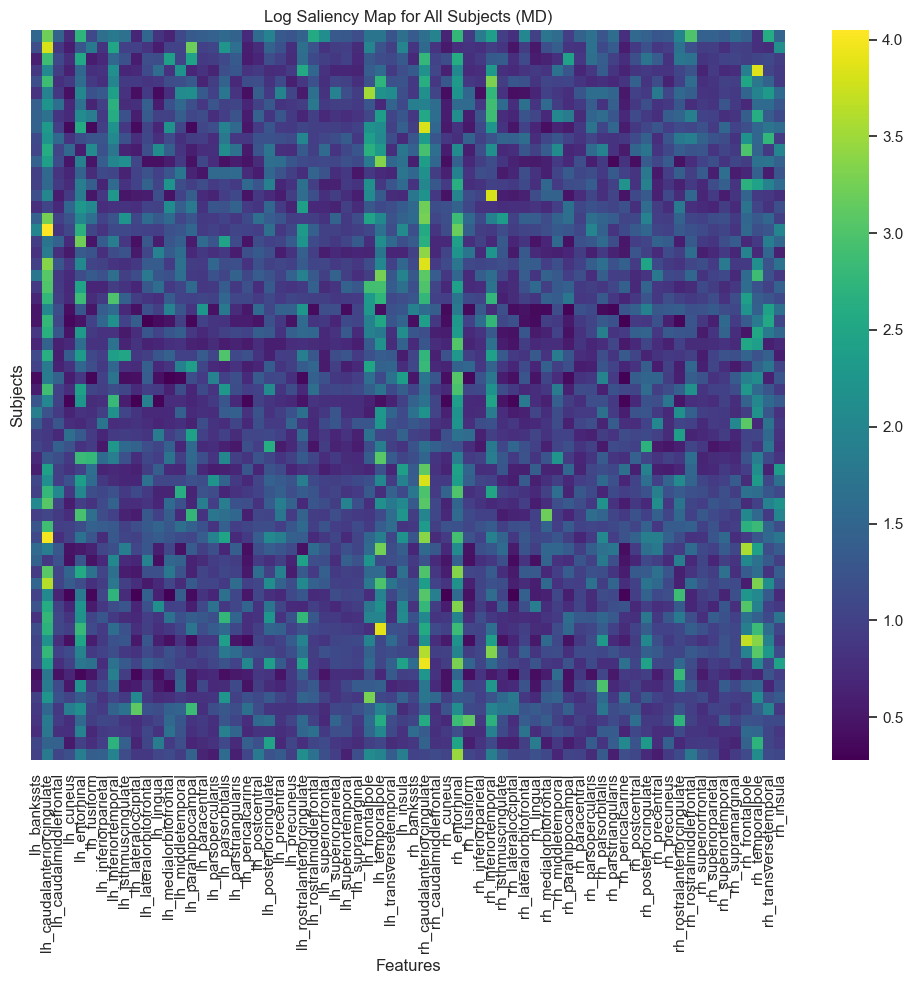

In [31]:
# Plot the log saliency map
saliency_maps_md_all_log = np.log1p(saliency_maps_md_all)  # Apply log transformation
plt.figure(figsize=(max(8, len(saliency_maps_md_all_log) // 6), 10))  # Adjust figure size based on number of subjects
ax = sns.heatmap(saliency_maps_md_all_log, cmap="viridis", cbar=True,
                    xticklabels=xlabel, yticklabels=False)
ax.set_xticks(np.arange(len(xlabel)) + 0.5)
ax.set_xticklabels(xlabel, rotation=90, ha='center')
plt.title("Log Saliency Map for All Subjects (MD)")
plt.xlabel("Features")
plt.ylabel("Subjects")
plt.tight_layout()
plt.show()

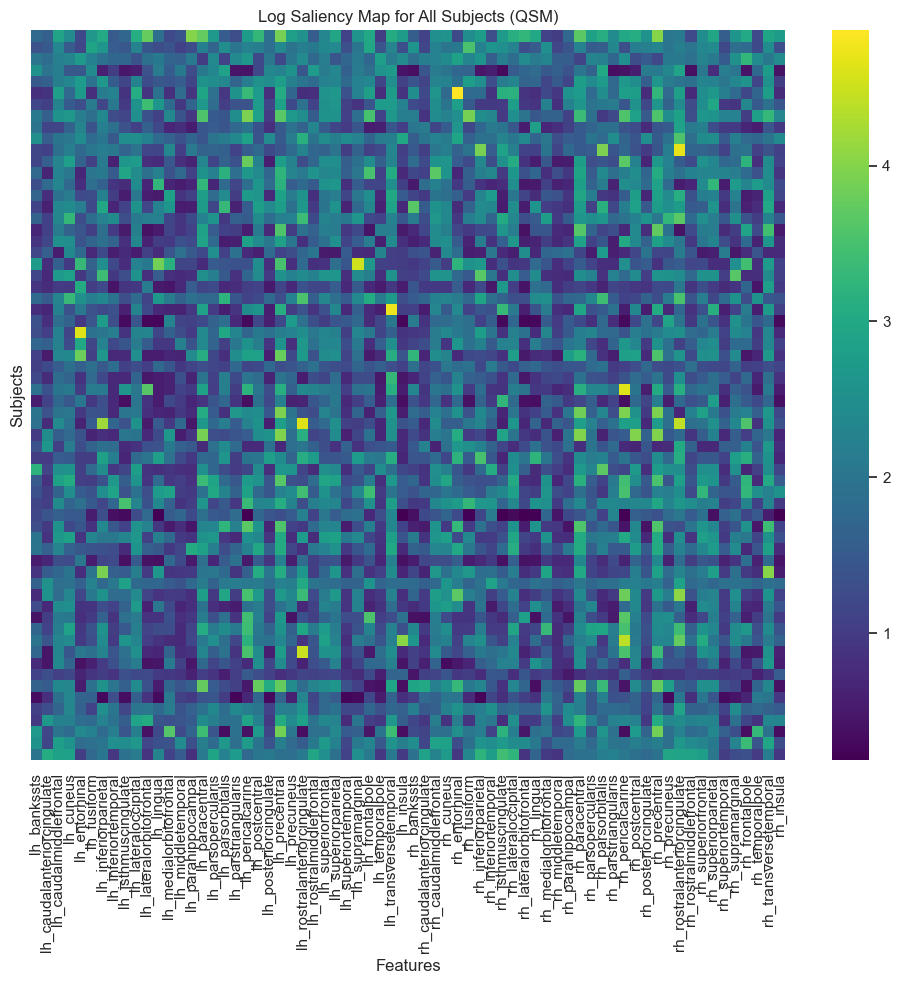

In [32]:
# Plot the log saliency map
saliency_maps_qsm_all_log = np.log1p(saliency_maps_qsm_all)  # Apply log transformation
plt.figure(figsize=(max(8, len(saliency_maps_qsm_all_log) // 6), 10))  # Adjust figure size based on number of subjects
ax = sns.heatmap(saliency_maps_qsm_all_log, cmap="viridis", cbar=True,
                    xticklabels=xlabel, yticklabels=False)
ax.set_xticks(np.arange(len(xlabel)) + 0.5)
ax.set_xticklabels(xlabel, rotation=90, ha='center')
plt.title("Log Saliency Map for All Subjects (QSM)")
plt.xlabel("Features")
plt.ylabel("Subjects")
plt.tight_layout()
plt.show()

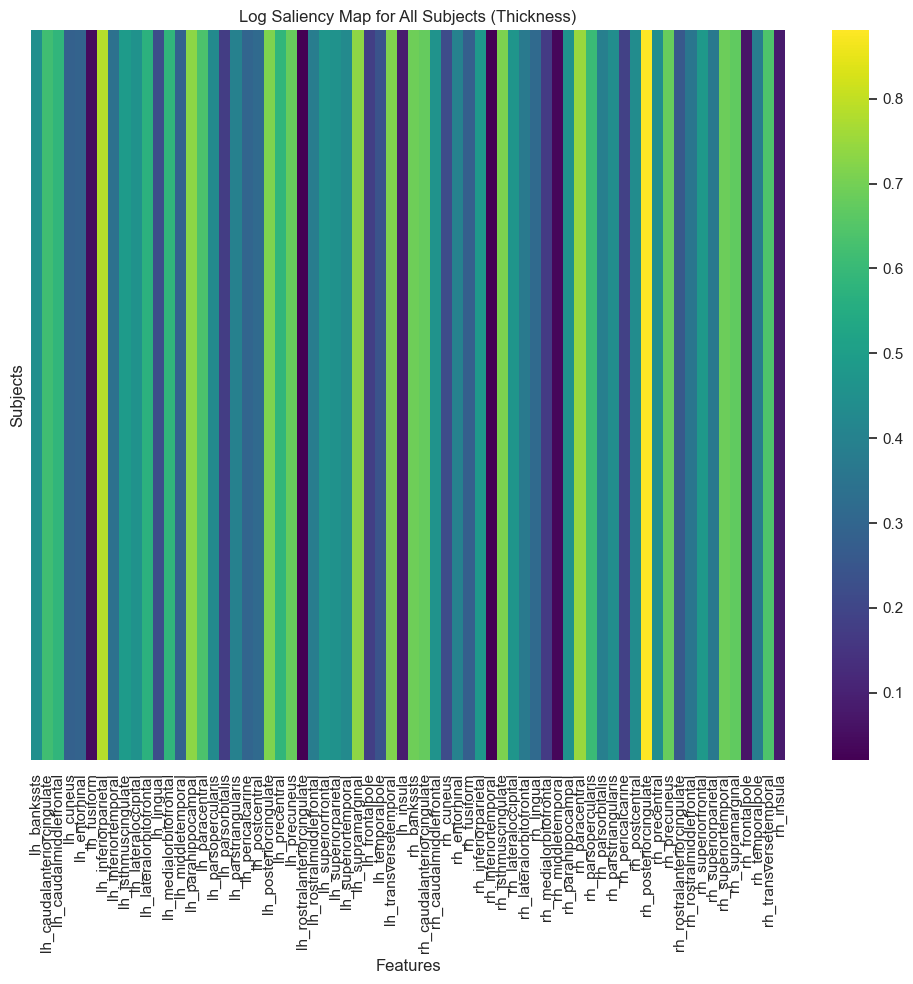

In [33]:
# Plot the log saliency map
saliency_maps_thickness_all_log = np.log1p(saliency_maps_thickness_all)  # Apply log transformation
plt.figure(figsize=(max(8, len(saliency_maps_thickness_all_log) // 6), 10))  # Adjust figure size based on number of subjects
ax = sns.heatmap(saliency_maps_thickness_all_log, cmap="viridis", cbar=True,
                    xticklabels=xlabel, yticklabels=False)
ax.set_xticks(np.arange(len(xlabel)) + 0.5)
ax.set_xticklabels(xlabel, rotation=90, ha='center')
plt.title("Log Saliency Map for All Subjects (Thickness)")
plt.xlabel("Features")
plt.ylabel("Subjects")
plt.tight_layout()
plt.show()

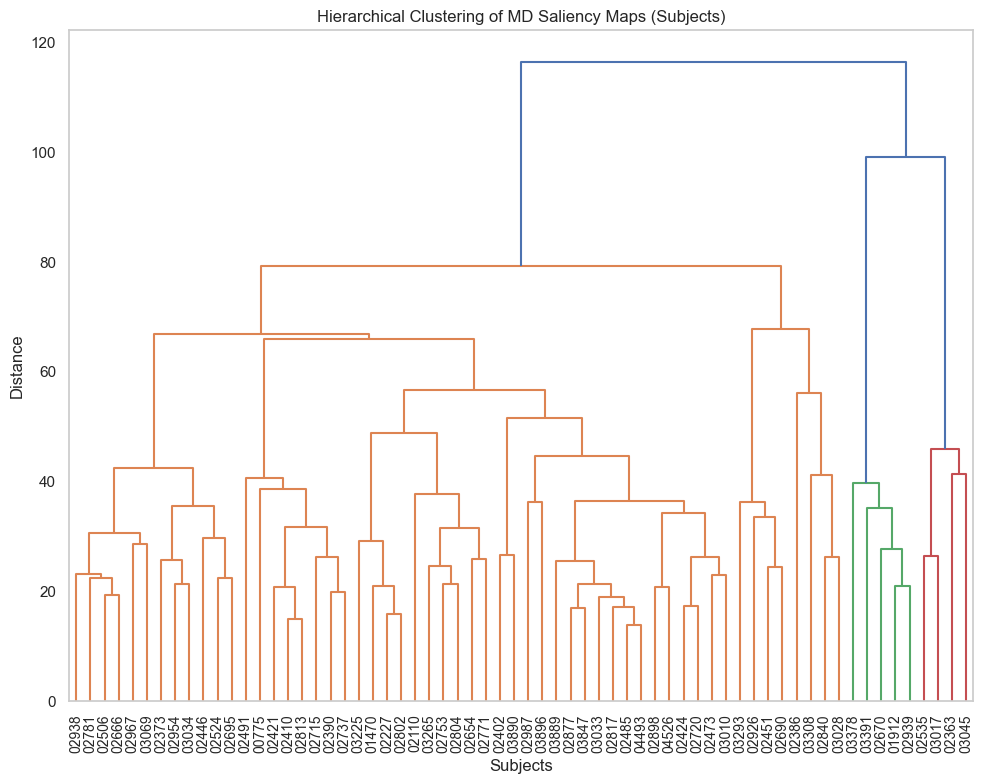

In [34]:
# Hierarchical clustering of saliency maps (subjects)
from scipy.cluster.hierarchy import dendrogram, linkage, leaves_list

# Use subject IDs corresponding to the rows in saliency_maps_all
saliency_subject_ids = [g[0].subject_id for g in aligned_graph_list]

# Cluster subjects (rows)
Z_subjects = linkage(saliency_maps_md_all, method='ward')
plt.figure(figsize=(10, 8))
dendrogram(Z_subjects, labels=saliency_subject_ids,  # Use correct subject IDs as labels
           leaf_rotation=90, leaf_font_size=10)
plt.title("Hierarchical Clustering of MD Saliency Maps (Subjects)")
plt.xlabel("Subjects")
plt.ylabel("Distance")
plt.tight_layout()
# Do not show the grid
plt.grid(False)
plt.show()

# Group the subjects into 4 clusters based on the dendrogram
from scipy.cluster.hierarchy import fcluster
n_clusters = 5  # Set the number of clusters
clusters = fcluster(Z_subjects, n_clusters, criterion='maxclust')
# Create a DataFrame to store subjects and their cluster assignments
# Ensure subject IDs are strings with leading zeros (5 digits)
df_clusters = pd.DataFrame({
    'subject_id': [str(sid).zfill(5) for sid in saliency_subject_ids],
    'cluster': clusters
})

# Define a color for each cluster (adjust as needed for n_clusters)
cluster_colors = {
    1: "#66c2a5",
    2: "#fc8d62",
    3: "#8da0cb",
    4: "#e78ac3",
    5: "#ffd92f"
}
df_clusters['color'] = df_clusters['cluster'].map(cluster_colors)

# Save the cluster assignments to a CSV file
df_clusters.to_csv("subject_clusters_saliency_MD.csv", index=False)

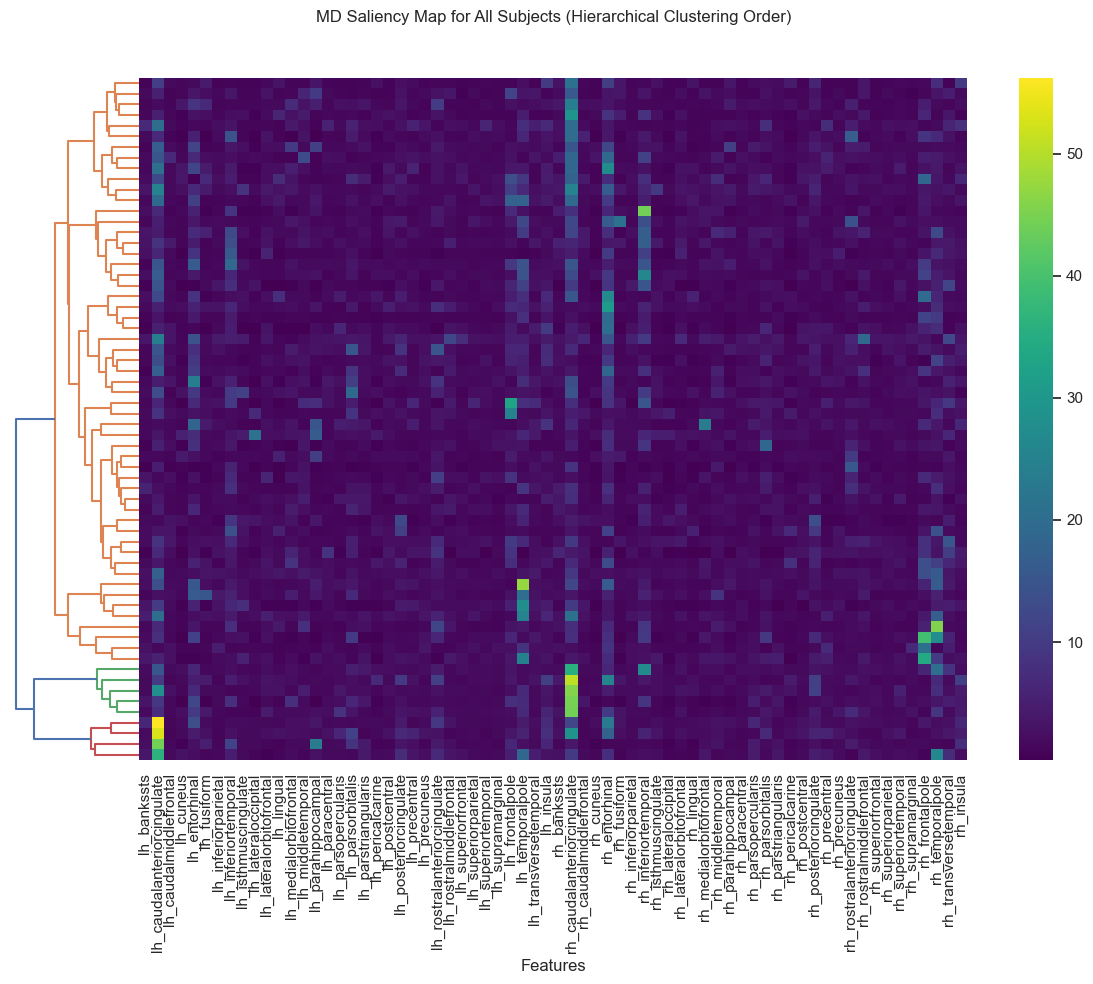

In [35]:
import matplotlib.gridspec as gridspec

from scipy.cluster.hierarchy import leaves_list

# Get the order of subjects from the dendrogram
subject_order = leaves_list(Z_subjects)

# Show the clustering result on the y axis of the saliency map
# Reorder the saliency map rows according to the clustering order
saliency_maps_all_reordered = saliency_maps_md_all[subject_order]

plt.figure(figsize=(max(10, len(saliency_maps_all_reordered) // 6) + 2, 10))  # Add width for dendrogram

# Create a gridspec for dendrogram and heatmap side by side

gs = gridspec.GridSpec(1, 2, width_ratios=[1, 8], wspace=0)
fig = plt.gcf()

# Plot dendrogram on the left
ax0 = plt.subplot(gs[0])
dendrogram(Z_subjects, orientation='left', labels=np.array(saliency_subject_ids)[subject_order],
           leaf_rotation=0, leaf_font_size=10, color_threshold=None, ax=ax0)
ax0.invert_yaxis()
ax0.axis('off')

# Plot heatmap on the right
ax1 = plt.subplot(gs[1])
sns.heatmap(saliency_maps_all_reordered, cmap="viridis", cbar=True,
            xticklabels=xlabel, yticklabels=False, ax=ax1)
ax1.set_xticklabels(xlabel, rotation=90, ha='center')
plt.title("MD Saliency Map for All Subjects (Hierarchical Clustering Order)", pad=40)
plt.xlabel("Features")
plt.tight_layout()
plt.show()

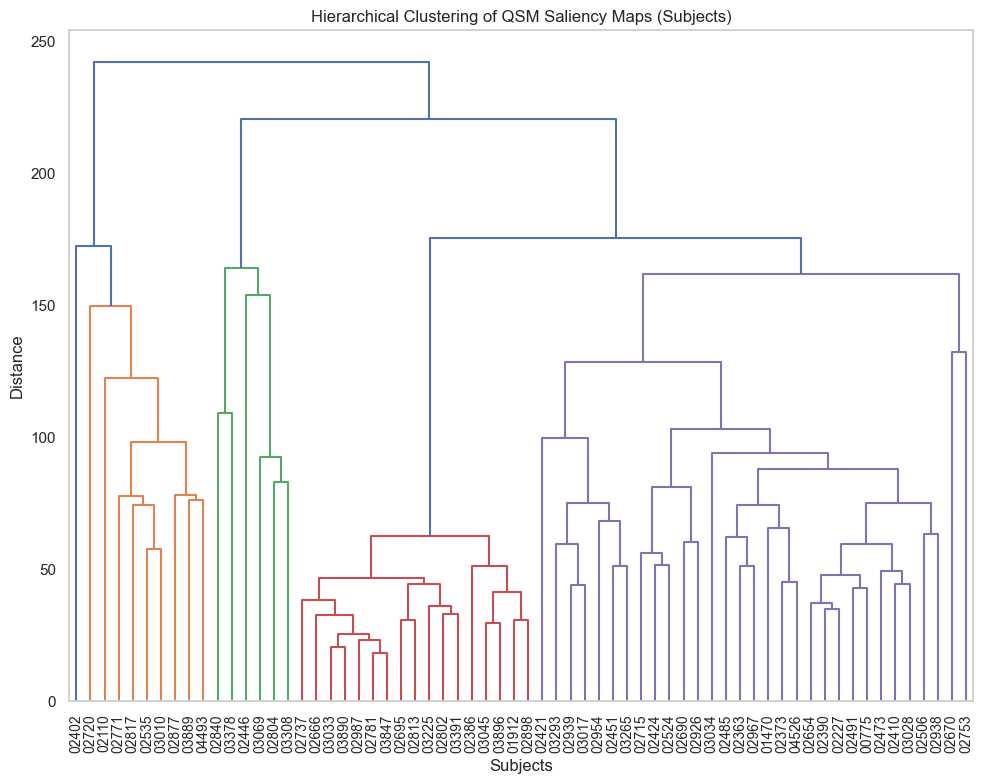

In [36]:
# Hierarchical clustering of saliency maps (subjects)
from scipy.cluster.hierarchy import dendrogram, linkage, leaves_list

# Cluster subjects (rows)
Z_subjects = linkage(saliency_maps_qsm_all, method='ward')
plt.figure(figsize=(10, 8))
dendrogram(Z_subjects, labels=saliency_subject_ids,  # Use correct subject IDs as labels
           leaf_rotation=90, leaf_font_size=10)
plt.title("Hierarchical Clustering of QSM Saliency Maps (Subjects)")
plt.xlabel("Subjects")
plt.ylabel("Distance")
plt.tight_layout()
# Do not show the grid
plt.grid(False)
plt.show()

# Group the subjects into 4 clusters based on the dendrogram
from scipy.cluster.hierarchy import fcluster
n_clusters = 4  # Set the number of clusters
clusters = fcluster(Z_subjects, n_clusters, criterion='maxclust')
# Create a DataFrame to store subjects and their cluster assignments
# Ensure subject IDs are strings with leading zeros (5 digits)
df_clusters = pd.DataFrame({
    'subject_id': [str(sid).zfill(5) for sid in saliency_subject_ids],
    'cluster': clusters
})

# Define a color for each cluster (adjust as needed for n_clusters)
cluster_colors = {
    1: "#66c2a5",
    2: "#fc8d62",
    3: "#8da0cb",
    4: "#e78ac3",
}
df_clusters['color'] = df_clusters['cluster'].map(cluster_colors)

# Save the cluster assignments to a CSV file
df_clusters.to_csv("subject_clusters_saliency_QSM.csv", index=False)

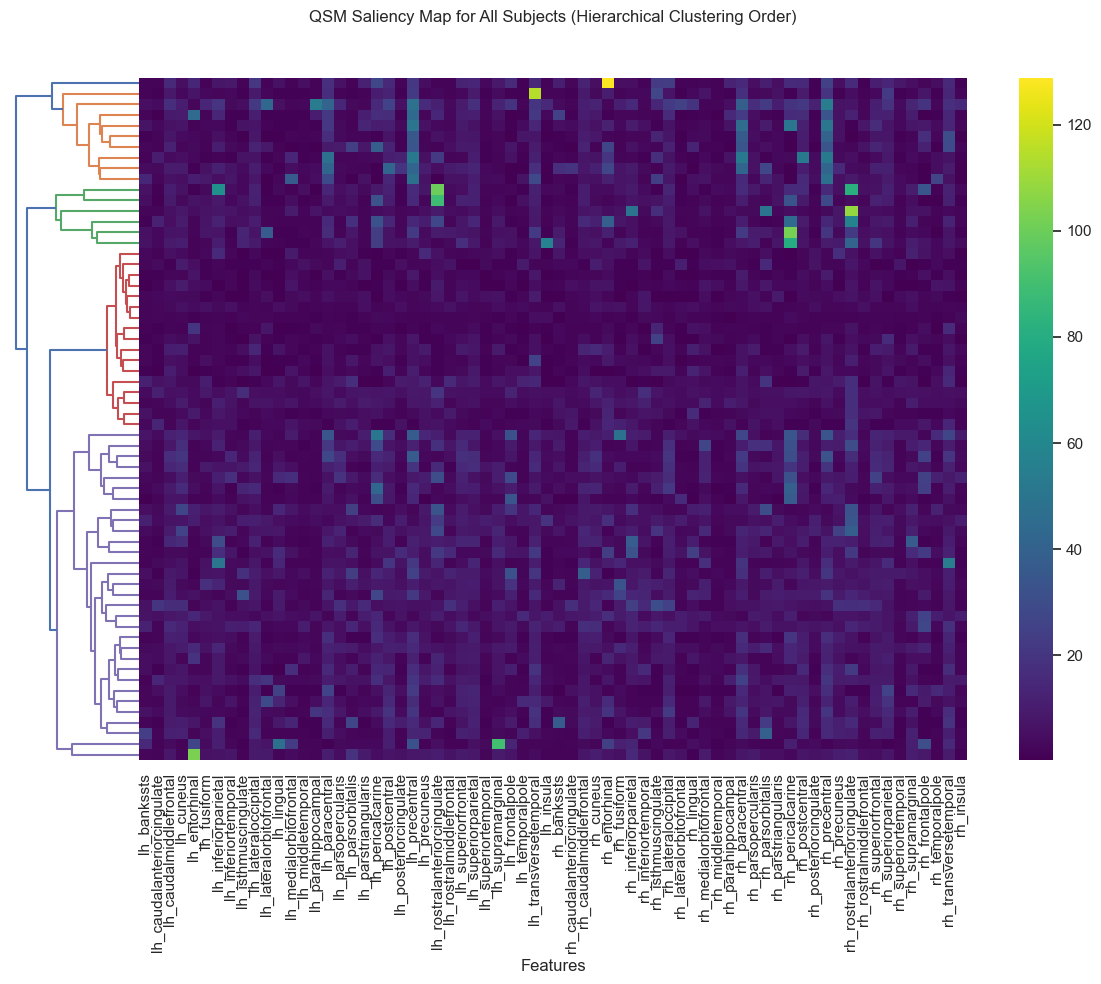

In [37]:
import matplotlib.gridspec as gridspec

from scipy.cluster.hierarchy import leaves_list

# Get the order of subjects from the dendrogram
subject_order = leaves_list(Z_subjects)

# Show the clustering result on the y axis of the saliency map
# Reorder the saliency map rows according to the clustering order
saliency_maps_all_reordered = saliency_maps_qsm_all[subject_order]

plt.figure(figsize=(max(10, len(saliency_maps_all_reordered) // 6) + 2, 10))  # Add width for dendrogram

# Create a gridspec for dendrogram and heatmap side by side

gs = gridspec.GridSpec(1, 2, width_ratios=[1, 8], wspace=0)
fig = plt.gcf()

# Plot dendrogram on the left
ax0 = plt.subplot(gs[0])
dendrogram(Z_subjects, orientation='left', labels=np.array(saliency_subject_ids)[subject_order],
           leaf_rotation=0, leaf_font_size=10, color_threshold=None, ax=ax0)
ax0.invert_yaxis()
ax0.axis('off')

# Plot heatmap on the right
ax1 = plt.subplot(gs[1])
sns.heatmap(saliency_maps_all_reordered, cmap="viridis", cbar=True,
            xticklabels=xlabel, yticklabels=False, ax=ax1)
ax1.set_xticklabels(xlabel, rotation=90, ha='center')
plt.title("QSM Saliency Map for All Subjects (Hierarchical Clustering Order)", pad=40)
plt.xlabel("Features")
plt.tight_layout()
plt.show()

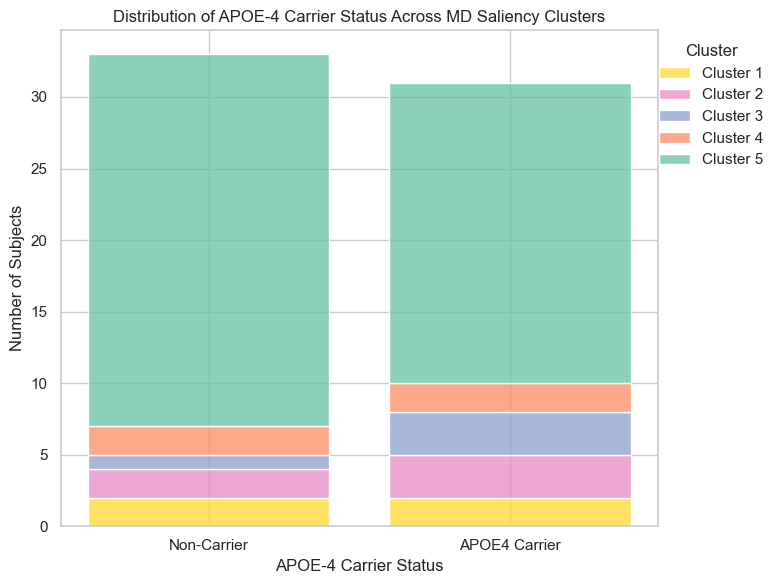

In [38]:
import pandas as pd

# Plot histogram with x-axis being APOE-4 carrier status and y-axis being the number of subjects in each cluster
# Load the cluster assignments
df_clusters = pd.read_csv("subject_clusters_saliency_md.csv")
# Insure the subject IDs are strings with leading zeros (5 digits)
df_clusters['subject_id'] = df_clusters['subject_id'].astype(str).str.zfill(5)

# Ensure subject_id is string for merge
df_clusters['subject_id'] = df_clusters['subject_id'].astype(str)

# Use df_matched from previous cells (already loaded)
# Ensure MRI_Exam_fixed is string
df_matched['MRI_Exam_fixed'] = df_matched['MRI_Exam_fixed'].astype(str)

# Merge with the metadata to get APOE-4 carrier status
df_clusters = pd.merge(df_clusters, df_matched[['MRI_Exam_fixed', 'genotype']], left_on='subject_id', right_on='MRI_Exam_fixed', how='left')

# Define APOE-4 carrier status
def define_apoe_status(genotype):
    if pd.isnull(genotype):
        return "Unknown"
    if "4" in str(genotype):
        return "APOE4 Carrier"
    else:
        return "Non-Carrier"

df_clusters['APOE'] = df_clusters['genotype'].apply(define_apoe_status)

cluster_colors = {
    1: "#66c2a5",
    2: "#fc8d62",
    3: "#8da0cb",
    4: "#e78ac3",
    5: "#ffd92f"
}
# Plot histogram with cluster colors
plt.figure(figsize=(8, 6))
sns.histplot(data=df_clusters, x='APOE', hue='cluster', multiple='stack', 
             palette=cluster_colors, shrink=0.8, discrete=True)
plt.title("Distribution of APOE-4 Carrier Status Across MD Saliency Clusters")
plt.xlabel("APOE-4 Carrier Status")
plt.ylabel("Number of Subjects")
# Add legend with cluster colors
plt.legend(title='Cluster', loc='upper right', labels=[f'Cluster {i}' for i in cluster_colors.keys()],
           bbox_to_anchor=(1.2, 1), frameon=False)
plt.tight_layout()
plt.show()


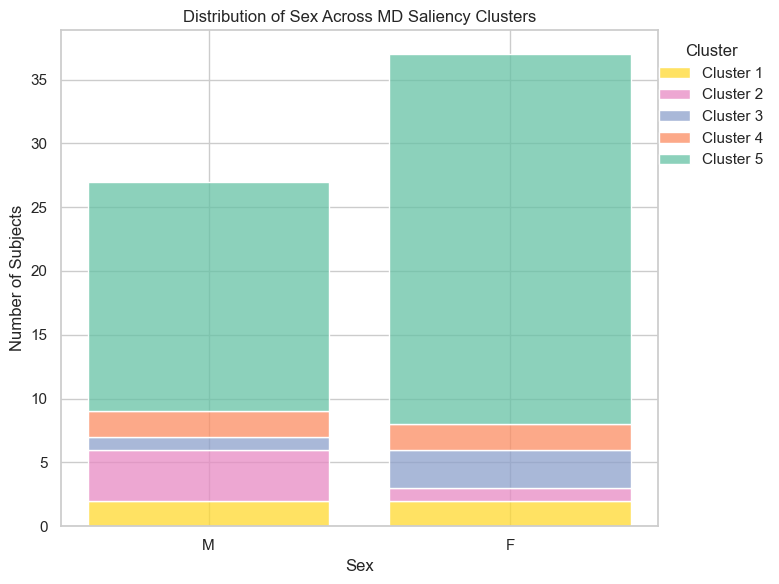

In [39]:
df_clusters = pd.merge(df_clusters, df_matched[['MRI_Exam_fixed', 'sex']], left_on='subject_id', right_on='MRI_Exam_fixed', how='left')
# Plot histogram with x-axis being sex being 'Female' or 'Male' and y-axis being the number of subjects in each cluster
plt.figure(figsize=(8, 6))
sns.histplot(data=df_clusters, x='sex', hue='cluster', multiple='stack',
             palette=cluster_colors, shrink=0.8, discrete=True)
plt.title("Distribution of Sex Across MD Saliency Clusters")
plt.xlabel('Sex')
plt.ylabel("Number of Subjects")
# Add legend with cluster colors
plt.legend(title='Cluster', loc='upper right', labels=[f'Cluster {i}' for i in cluster_colors.keys()],
           bbox_to_anchor=(1.2, 1), frameon=False)
plt.tight_layout()
plt.show()

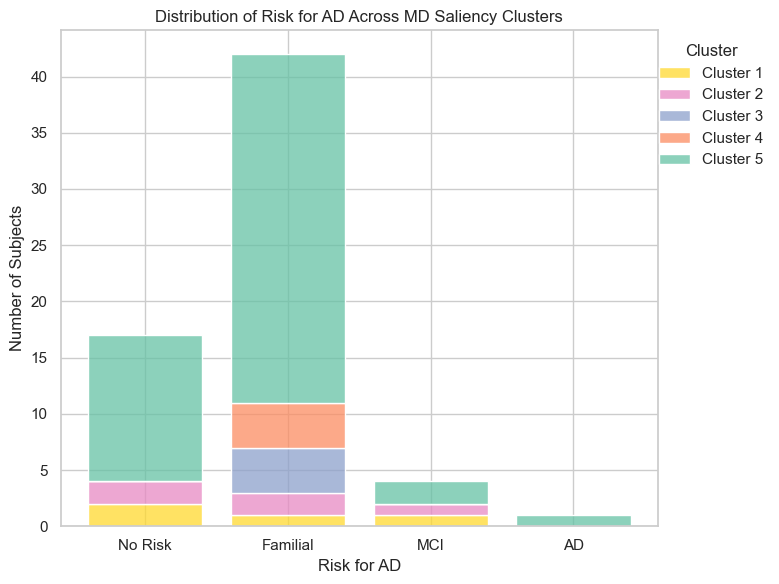

In [40]:
df_clusters = pd.merge(df_clusters, df_matched[['MRI_Exam_fixed', 'risk_for_ad']], left_on='subject_id', right_on='MRI_Exam_fixed', how='left')
# Plot histogram with x-axis being Risk for AD and y-axis being the number of subjects in each cluster
plt.figure(figsize=(8, 6))
sns.histplot(data=df_clusters, x='risk_for_ad', hue='cluster', multiple='stack',
             palette=cluster_colors, shrink=0.8, discrete=True)
plt.title("Distribution of Risk for AD Across MD Saliency Clusters")
plt.xlabel("Risk for AD")
plt.ylabel("Number of Subjects")
# Only show the x grid of 0,1,2,3
plt.xticks(ticks=[0, 1, 2, 3], labels=['No Risk', 'Familial', 'MCI', 'AD', ])
# Add legend with cluster colors
plt.legend(title='Cluster', loc='upper right', labels=[f'Cluster {i}' for i in cluster_colors.keys()],
           bbox_to_anchor=(1.2, 1), frameon=False)
plt.tight_layout()
plt.show()

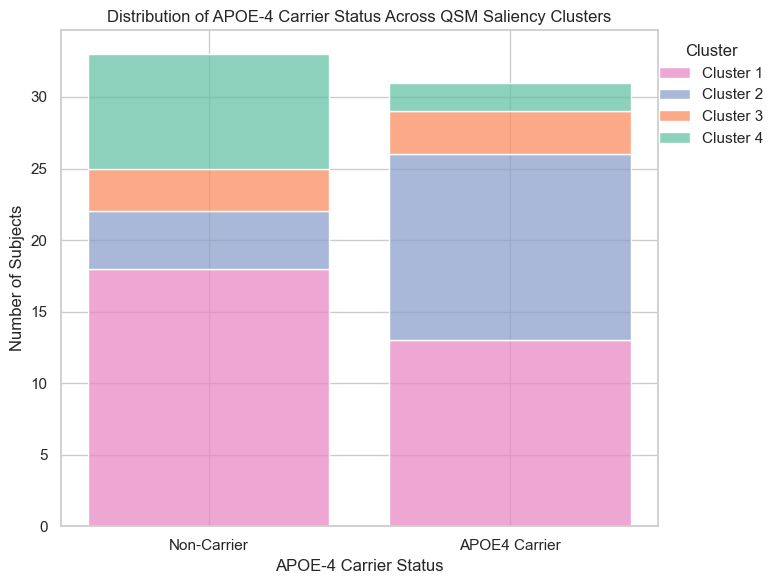

In [41]:
import pandas as pd

# Plot histogram with x-axis being APOE-4 carrier status and y-axis being the number of subjects in each cluster
# Load the cluster assignments
df_clusters = pd.read_csv("subject_clusters_saliency_qsm.csv")
# Insure the subject IDs are strings with leading zeros (5 digits)
df_clusters['subject_id'] = df_clusters['subject_id'].astype(str).str.zfill(5)

# Ensure subject_id is string for merge
df_clusters['subject_id'] = df_clusters['subject_id'].astype(str)

# Use df_matched from previous cells (already loaded)
# Ensure MRI_Exam_fixed is string
df_matched['MRI_Exam_fixed'] = df_matched['MRI_Exam_fixed'].astype(str)

# Merge with the metadata to get APOE-4 carrier status
df_clusters = pd.merge(df_clusters, df_matched[['MRI_Exam_fixed', 'genotype']], left_on='subject_id', right_on='MRI_Exam_fixed', how='left')

# Define APOE-4 carrier status
def define_apoe_status(genotype):
    if pd.isnull(genotype):
        return "Unknown"
    if "4" in str(genotype):
        return "APOE4 Carrier"
    else:
        return "Non-Carrier"

df_clusters['APOE'] = df_clusters['genotype'].apply(define_apoe_status)

cluster_colors = {
    1: "#66c2a5",
    2: "#fc8d62",
    3: "#8da0cb",
    4: "#e78ac3",
}
# Plot histogram with cluster colors
plt.figure(figsize=(8, 6))
sns.histplot(data=df_clusters, x='APOE', hue='cluster', multiple='stack', 
             palette=cluster_colors, shrink=0.8, discrete=True)
plt.title("Distribution of APOE-4 Carrier Status Across QSM Saliency Clusters")
plt.xlabel("APOE-4 Carrier Status")
plt.ylabel("Number of Subjects")
# Add legend with cluster colors
plt.legend(title='Cluster', loc='upper right', labels=[f'Cluster {i}' for i in cluster_colors.keys()],
           bbox_to_anchor=(1.2, 1), frameon=False)
plt.tight_layout()
plt.show()


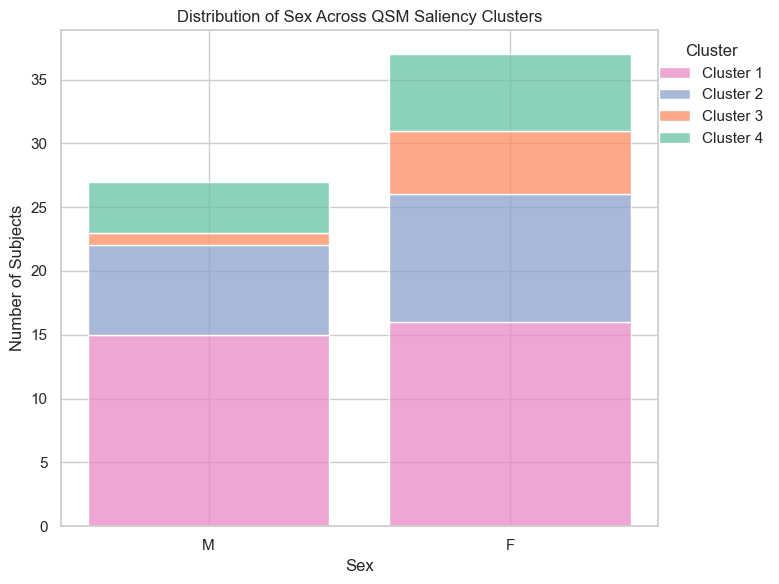

In [42]:
df_clusters = pd.merge(df_clusters, df_matched[['MRI_Exam_fixed', 'sex']], left_on='subject_id', right_on='MRI_Exam_fixed', how='left')
# Plot histogram with x-axis being sex being 'Female' or 'Male' and y-axis being the number of subjects in each cluster
plt.figure(figsize=(8, 6))
sns.histplot(data=df_clusters, x='sex', hue='cluster', multiple='stack',
             palette=cluster_colors, shrink=0.8, discrete=True)
plt.title("Distribution of Sex Across QSM Saliency Clusters")
plt.xlabel('Sex')
plt.ylabel("Number of Subjects")
# Add legend with cluster colors
plt.legend(title='Cluster', loc='upper right', labels=[f'Cluster {i}' for i in cluster_colors.keys()],
           bbox_to_anchor=(1.2, 1), frameon=False)
plt.tight_layout()
plt.show()

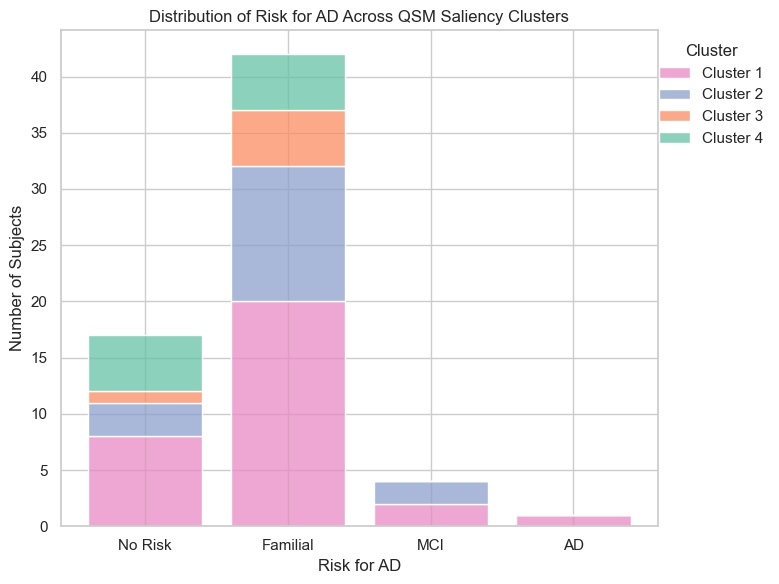

In [43]:
df_clusters = pd.merge(df_clusters, df_matched[['MRI_Exam_fixed', 'risk_for_ad']], left_on='subject_id', right_on='MRI_Exam_fixed', how='left')
# Plot histogram with x-axis being Risk for AD and y-axis being the number of subjects in each cluster
plt.figure(figsize=(8, 6))
sns.histplot(data=df_clusters, x='risk_for_ad', hue='cluster', multiple='stack',
             palette=cluster_colors, shrink=0.8, discrete=True)
plt.title("Distribution of Risk for AD Across QSM Saliency Clusters")
plt.xlabel("Risk for AD")
plt.ylabel("Number of Subjects")
# Only show the x grid of 0,1,2,3
plt.xticks(ticks=[0, 1, 2, 3], labels=['No Risk', 'Familial', 'MCI', 'AD', ])
# Add legend with cluster colors
plt.legend(title='Cluster', loc='upper right', labels=[f'Cluster {i}' for i in cluster_colors.keys()],
           bbox_to_anchor=(1.2, 1), frameon=False)
plt.tight_layout()
plt.show()

## Top 10 MD regions

Top 10 Regions with Highest Saliency: ['lh_frontalpole', 'lh_inferiortemporal', 'rh_frontalpole', 'lh_entorhinal', 'rh_inferiortemporal', 'rh_temporalpole', 'lh_temporalpole', 'rh_entorhinal', 'lh_caudalanteriorcingulate', 'rh_caudalanteriorcingulate']


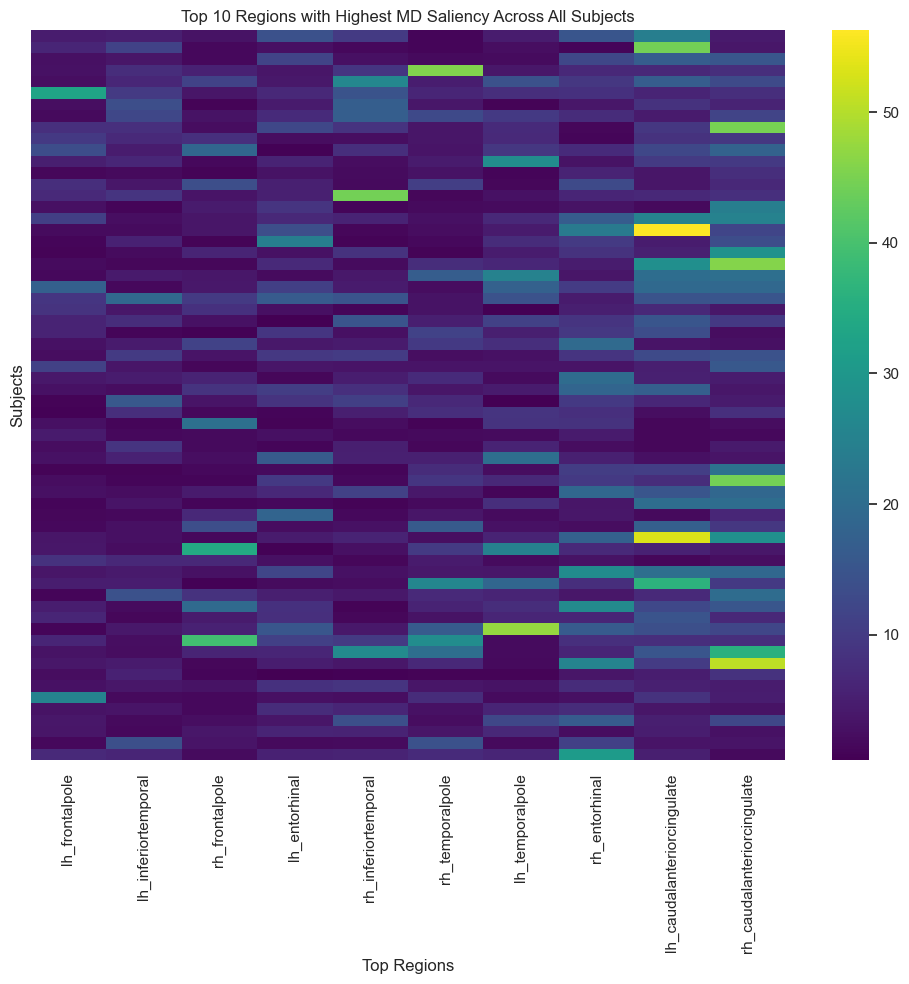

In [44]:
# Get the top 10 regions with the highest MD saliency across all subjects
top_regions_indices = np.argsort(np.mean(saliency_maps_md_all, axis=0))[-10:]  # Get indices of top 10 regions
top_regions = [xlabel[i] for i in top_regions_indices]  # Get region names
print("Top 10 Regions with Highest Saliency:", top_regions)
# Extract the saliency values for the top regions
top_saliency_values = saliency_maps_md_all[:, top_regions_indices]  # Shape: [n_subjects, 10]
# Visualize the top regions' saliency map
plt.figure(figsize=(10, 10))
ax = sns.heatmap(top_saliency_values, cmap="viridis", cbar=True,
                 xticklabels=top_regions, yticklabels=False)
ax.set_xticks(np.arange(len(top_regions)) + 0.5)
ax.set_xticklabels(top_regions, rotation=90, ha='center')
plt.title("Top 10 Regions with Highest MD Saliency Across All Subjects")
plt.xlabel("Top Regions")
plt.ylabel("Subjects")
plt.tight_layout()
plt.show()


Top 10 Regions with Highest Saliency: ['lh_pericalcarine', 'rh_transversetemporal', 'lh_rostralanteriorcingulate', 'lh_paracentral', 'lh_transversetemporal', 'rh_pericalcarine', 'rh_paracentral', 'rh_rostralanteriorcingulate', 'rh_precentral', 'lh_precentral']


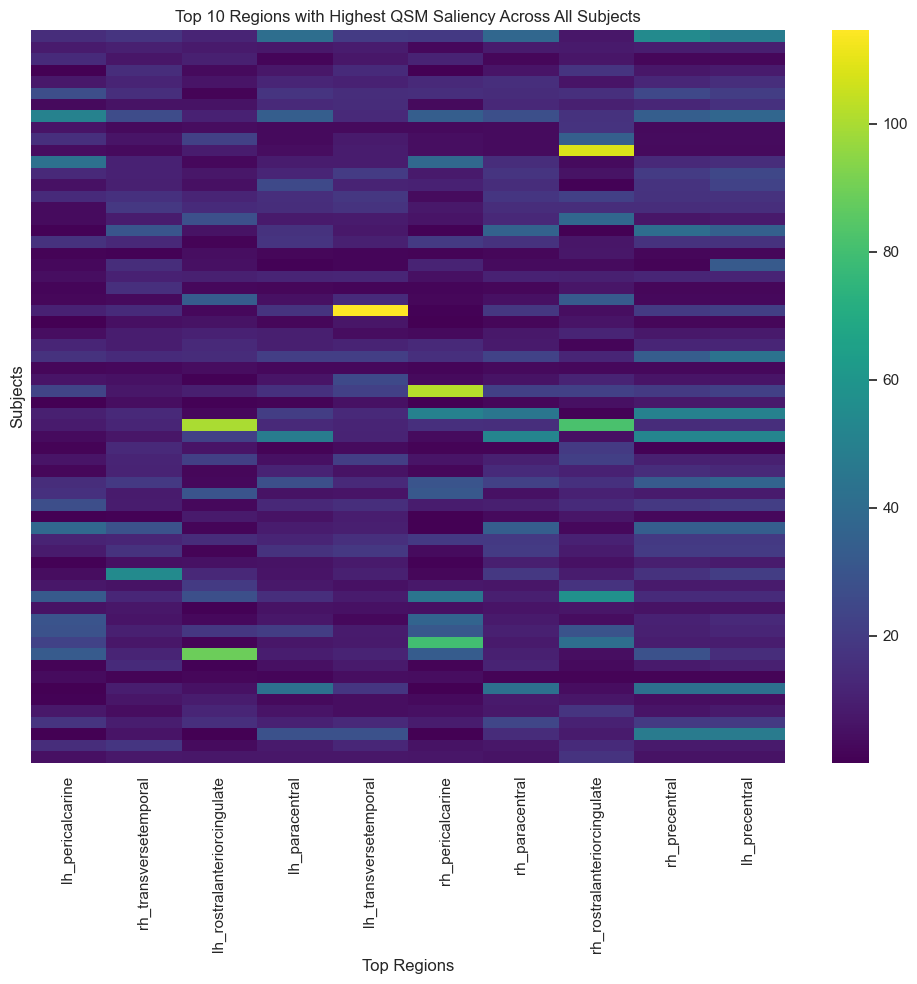

In [45]:
# Get the top 10 regions with the highest QSM saliency across all subjects
top_regions_indices = np.argsort(np.mean(saliency_maps_qsm_all, axis=0))[-10:]  # Get indices of top 10 regions
top_regions = [xlabel[i] for i in top_regions_indices]  # Get region names
print("Top 10 Regions with Highest Saliency:", top_regions)
# Extract the saliency values for the top regions
top_saliency_values = saliency_maps_qsm_all[:, top_regions_indices]  # Shape: [n_subjects, 10]
# Visualize the top regions' saliency map
plt.figure(figsize=(10, 10))
ax = sns.heatmap(top_saliency_values, cmap="viridis", cbar=True,
                 xticklabels=top_regions, yticklabels=False)
ax.set_xticks(np.arange(len(top_regions)) + 0.5)
ax.set_xticklabels(top_regions, rotation=90, ha='center')
plt.title("Top 10 Regions with Highest QSM Saliency Across All Subjects")
plt.xlabel("Top Regions")
plt.ylabel("Subjects")
plt.tight_layout()
plt.show()


## Saliency by layer

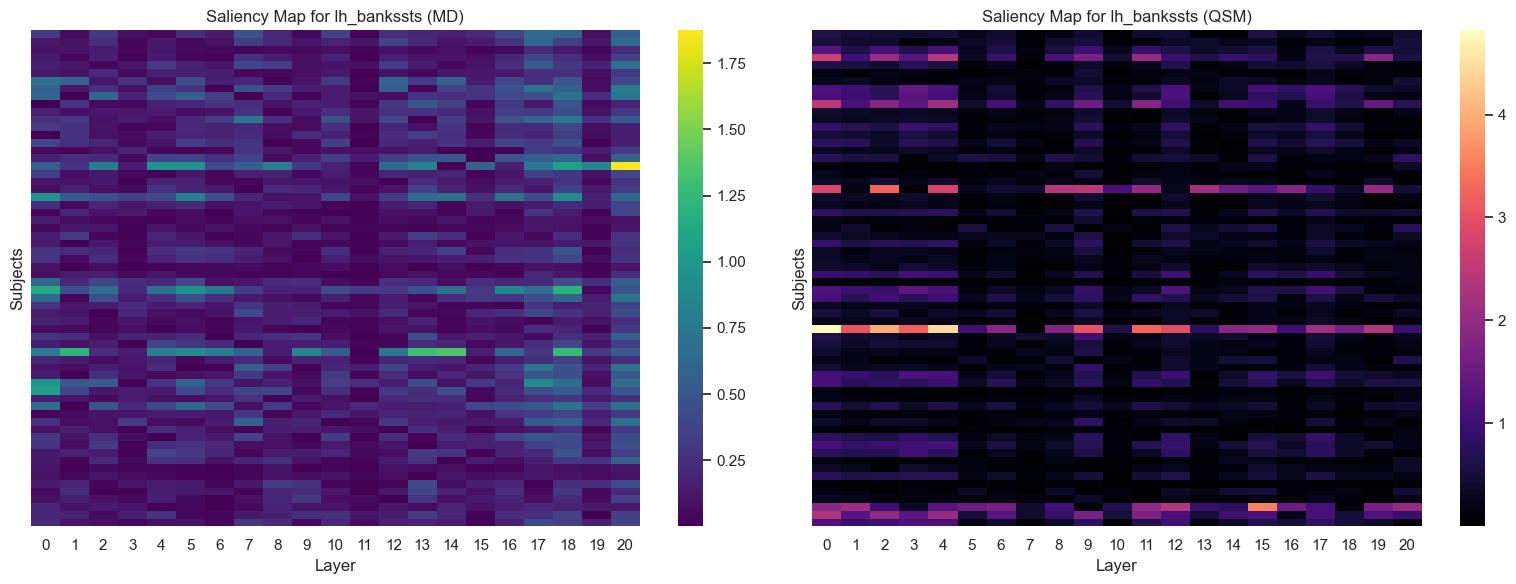

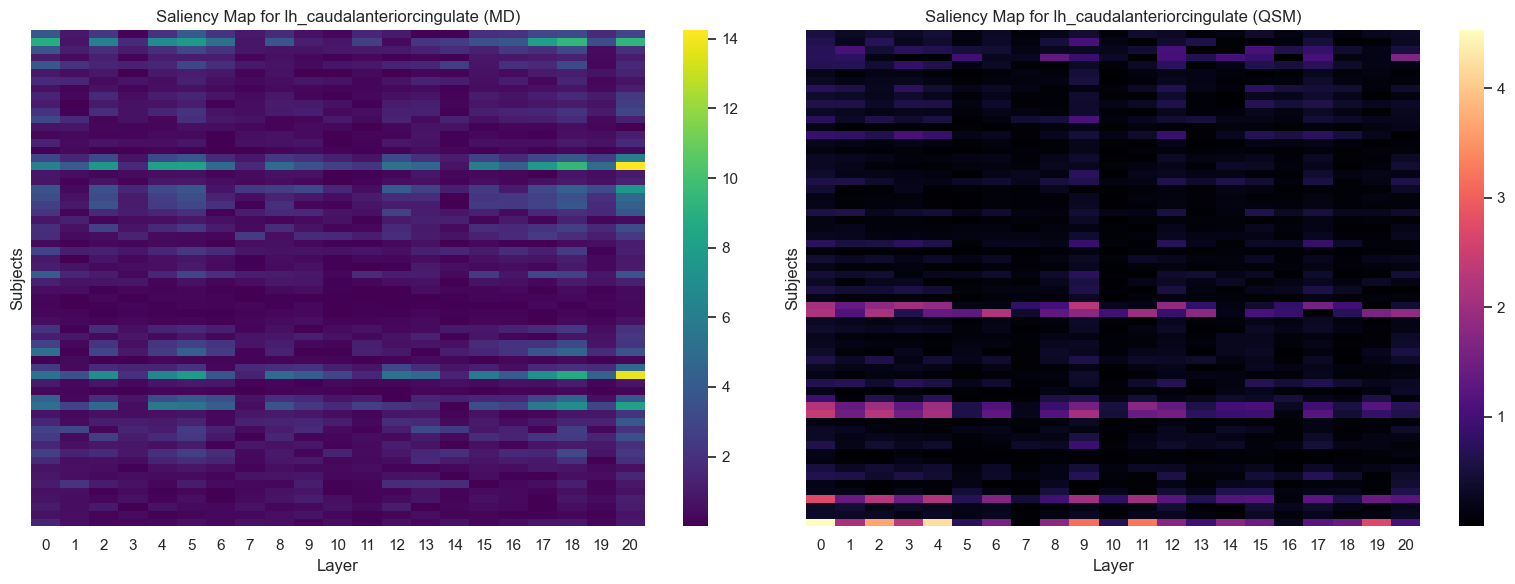

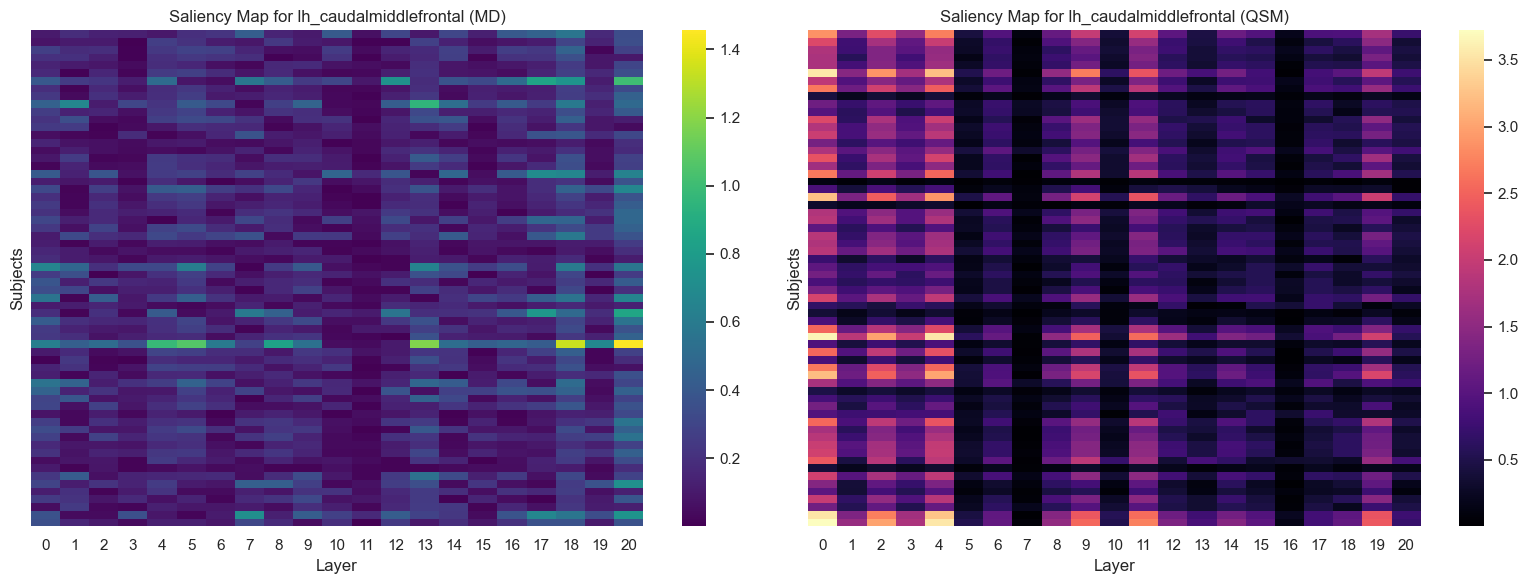

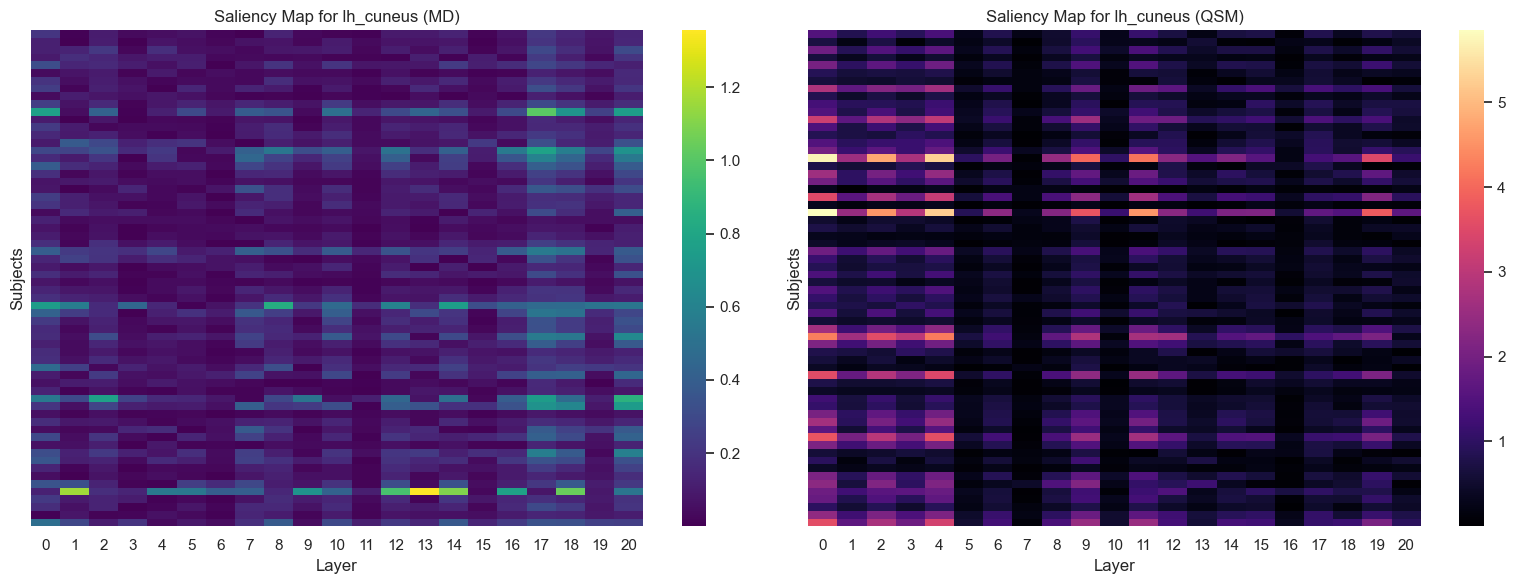

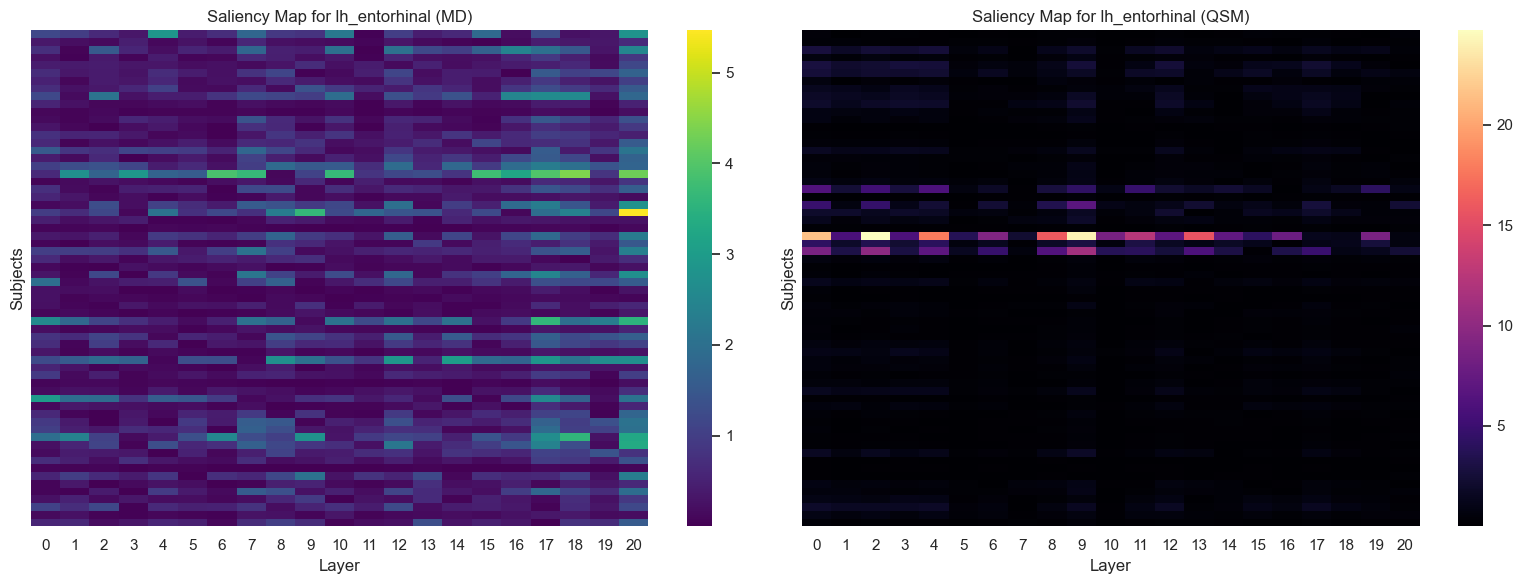

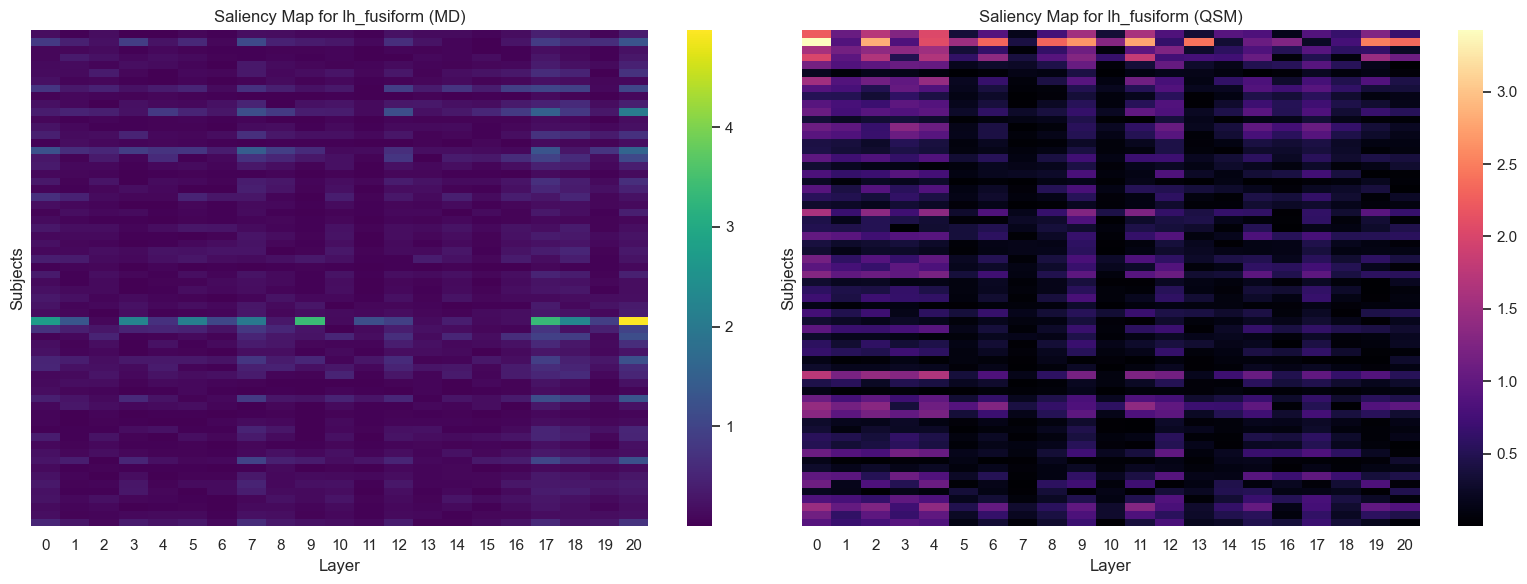

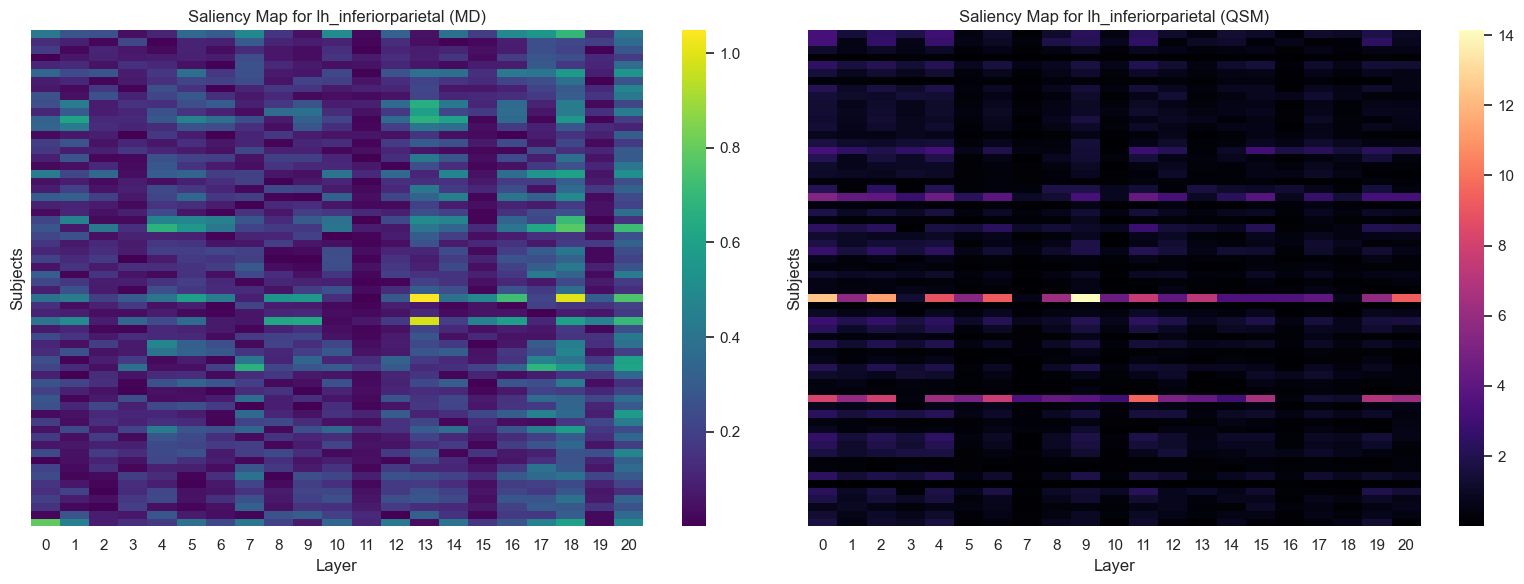

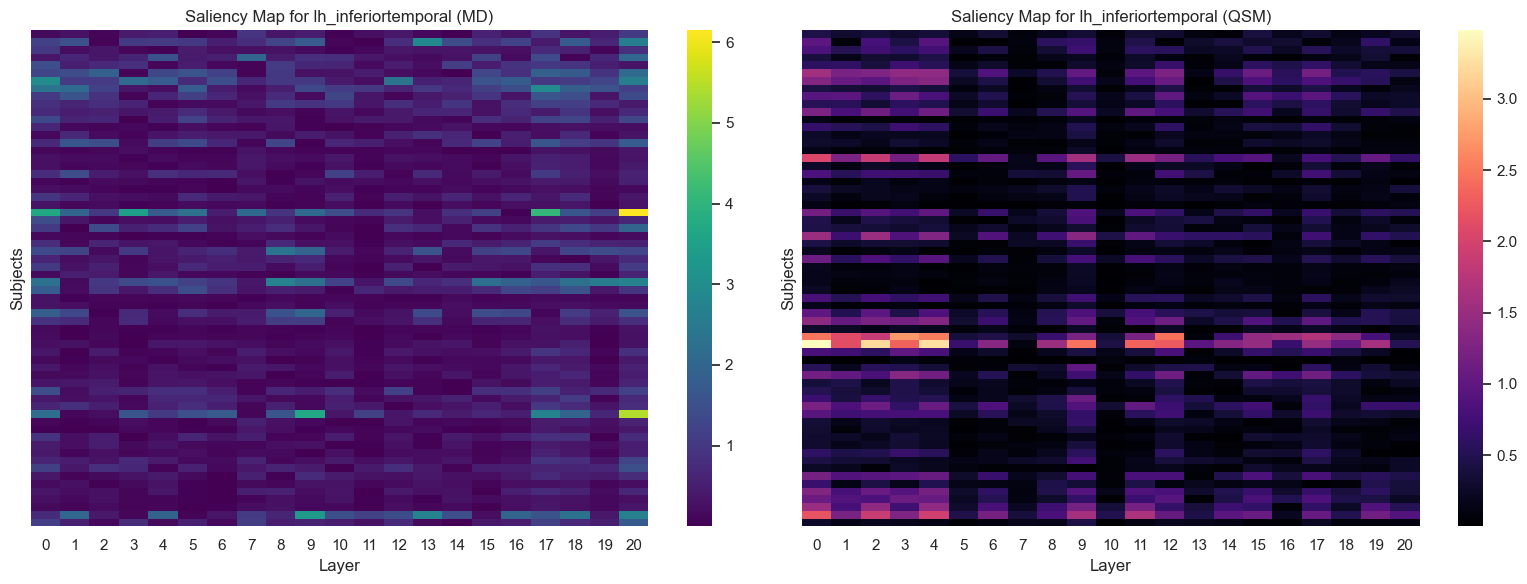

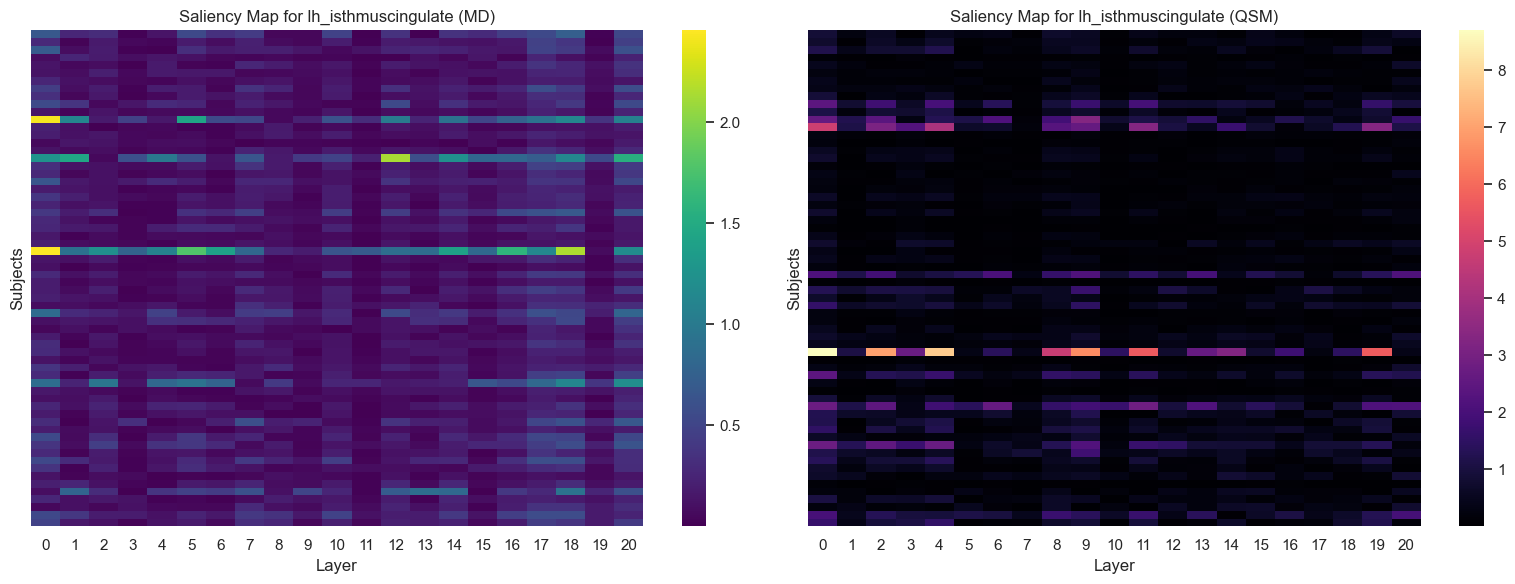

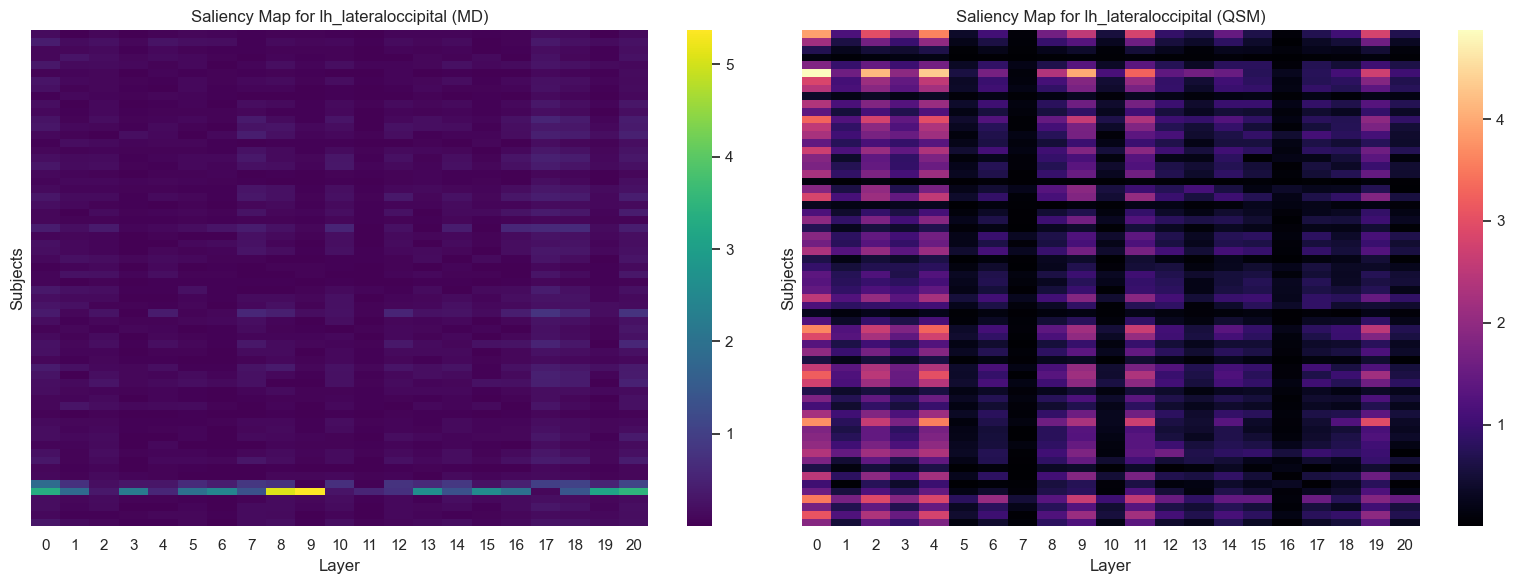

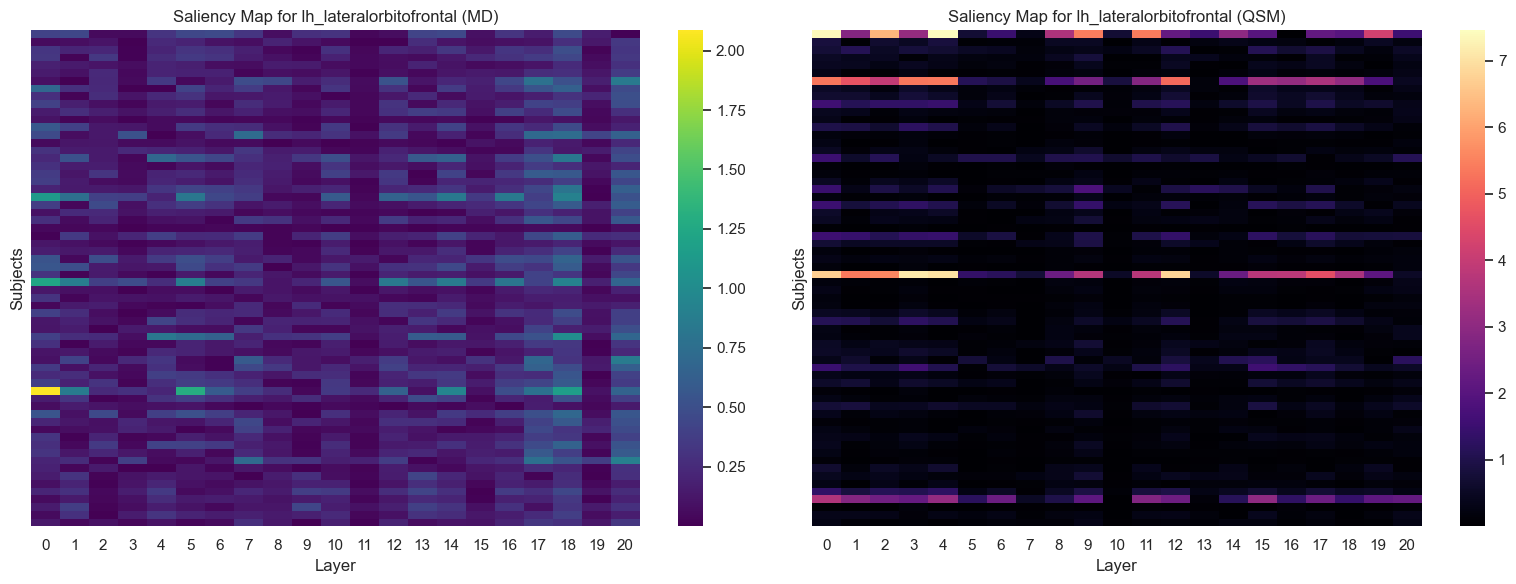

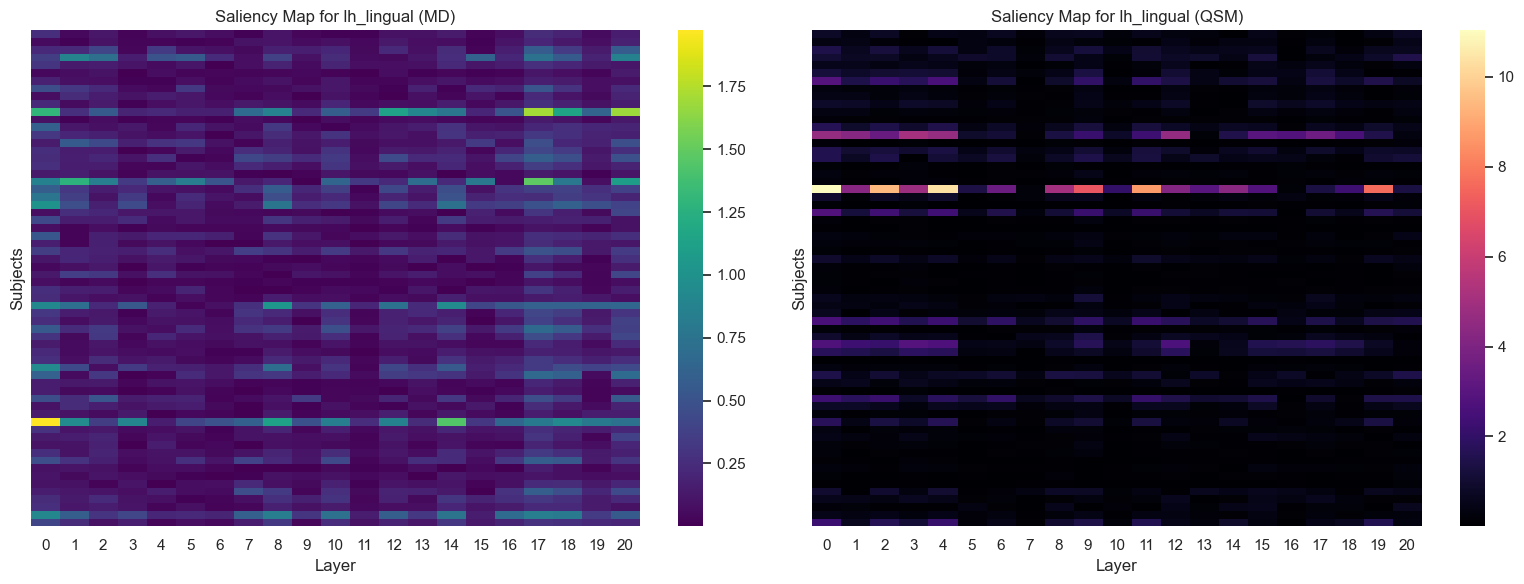

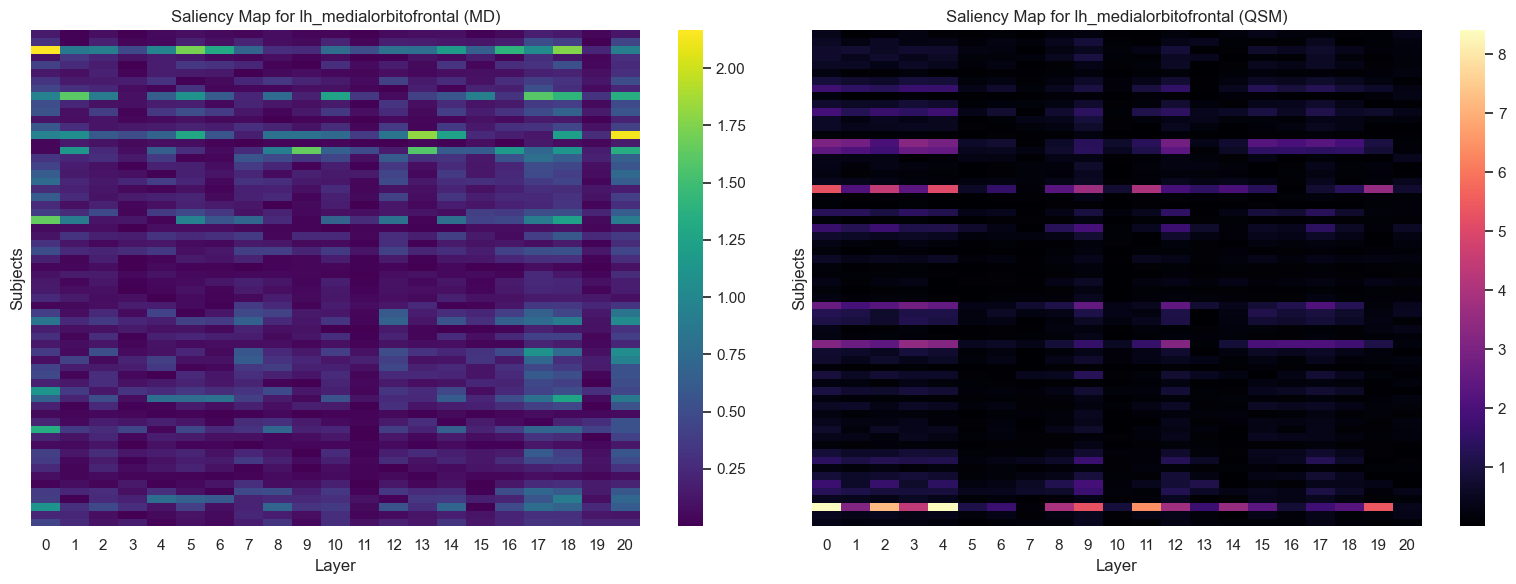

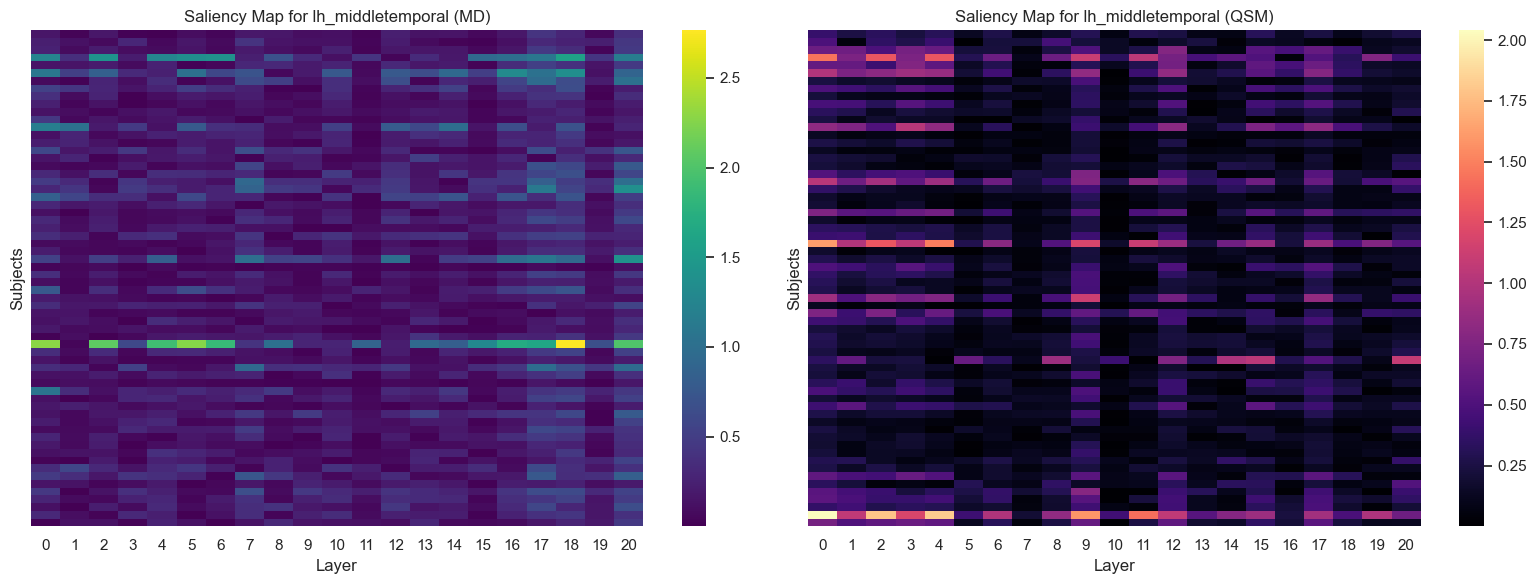

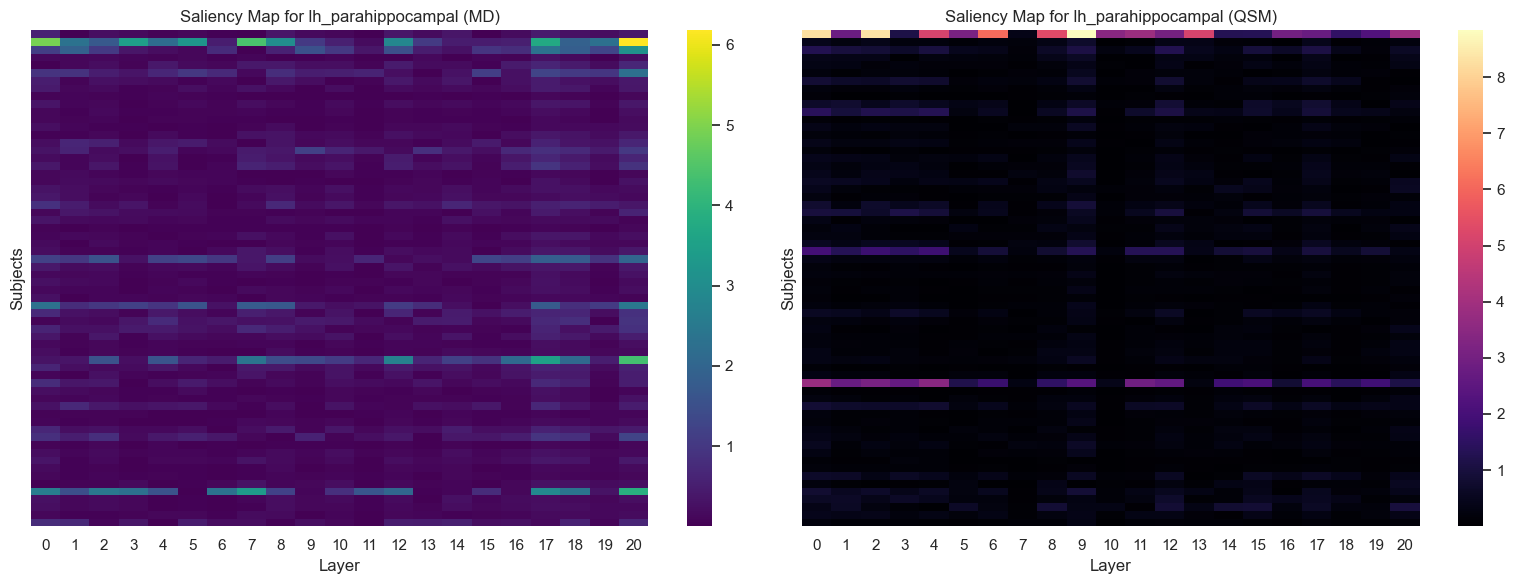

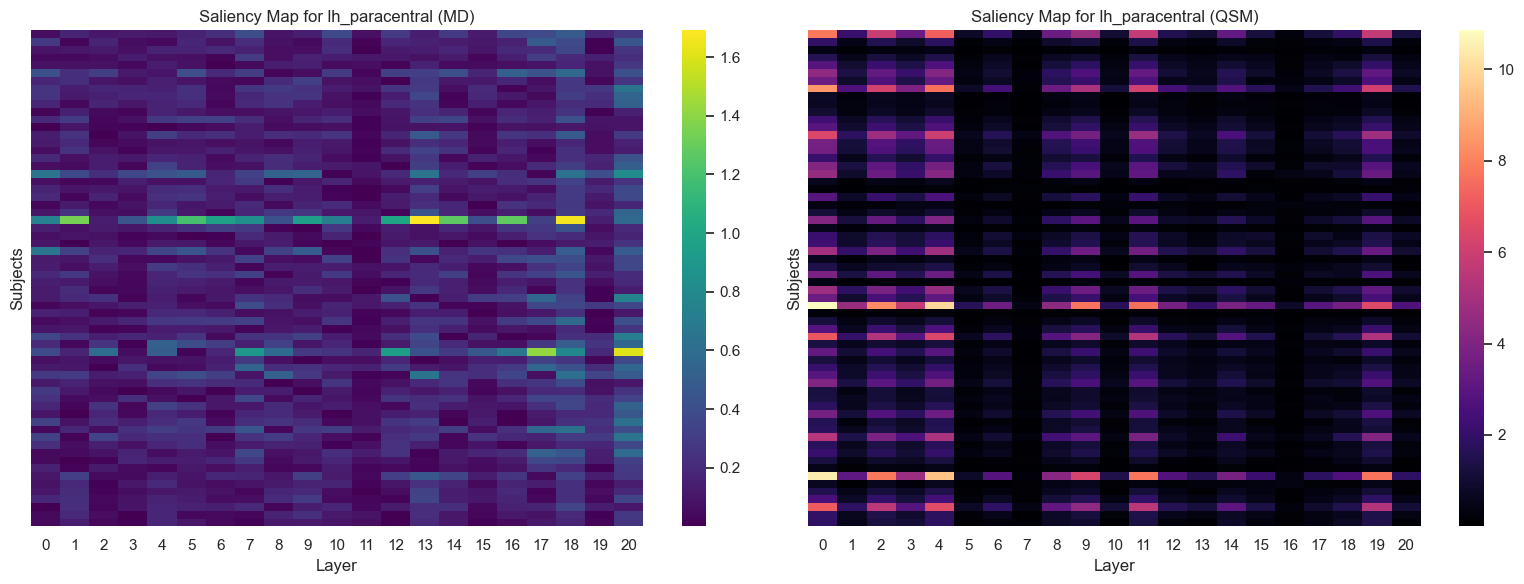

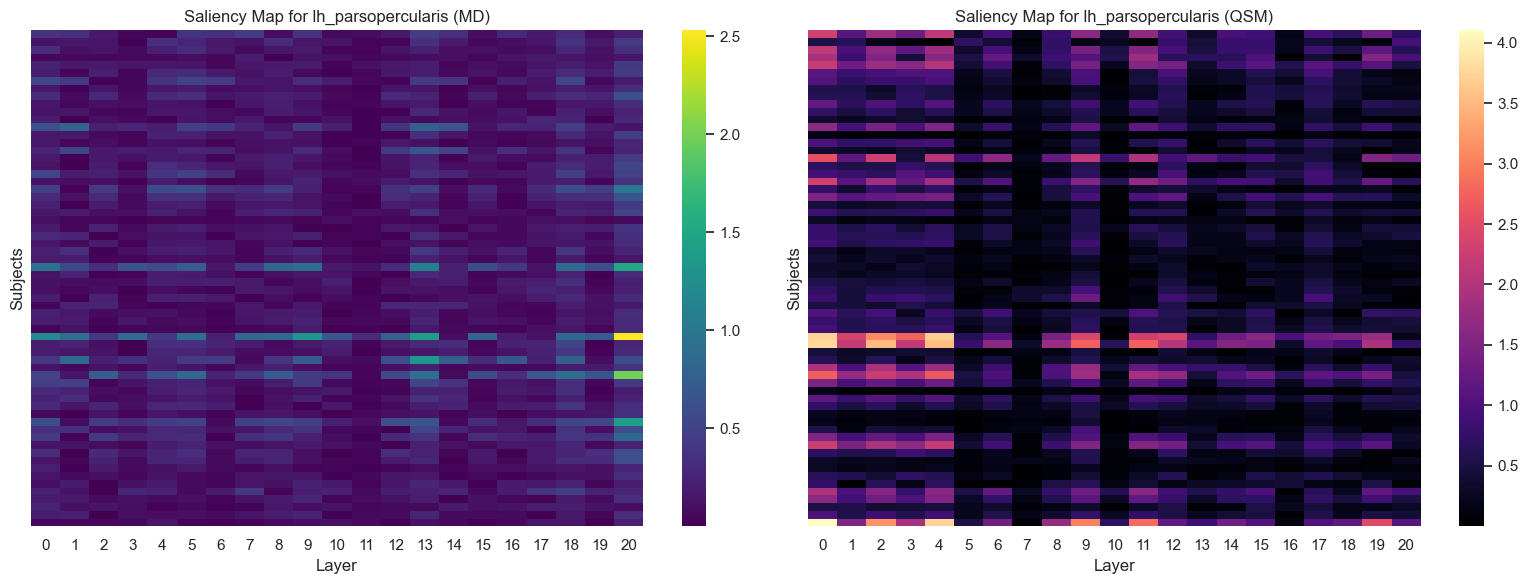

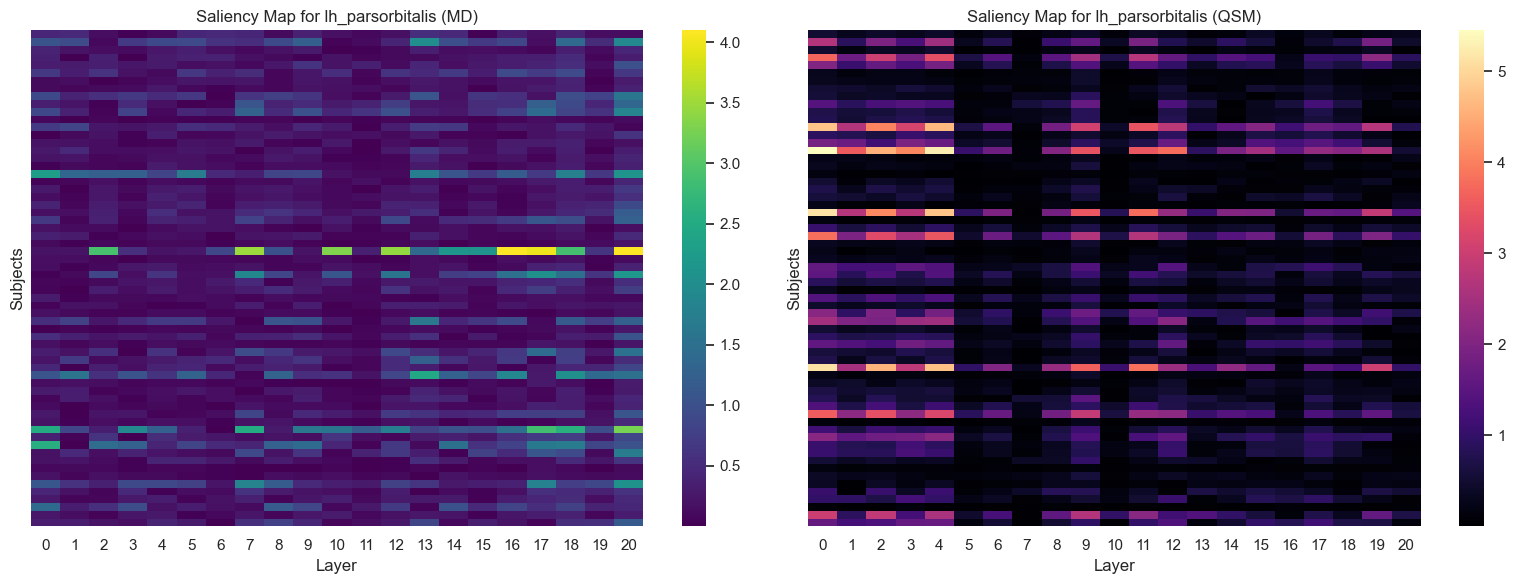

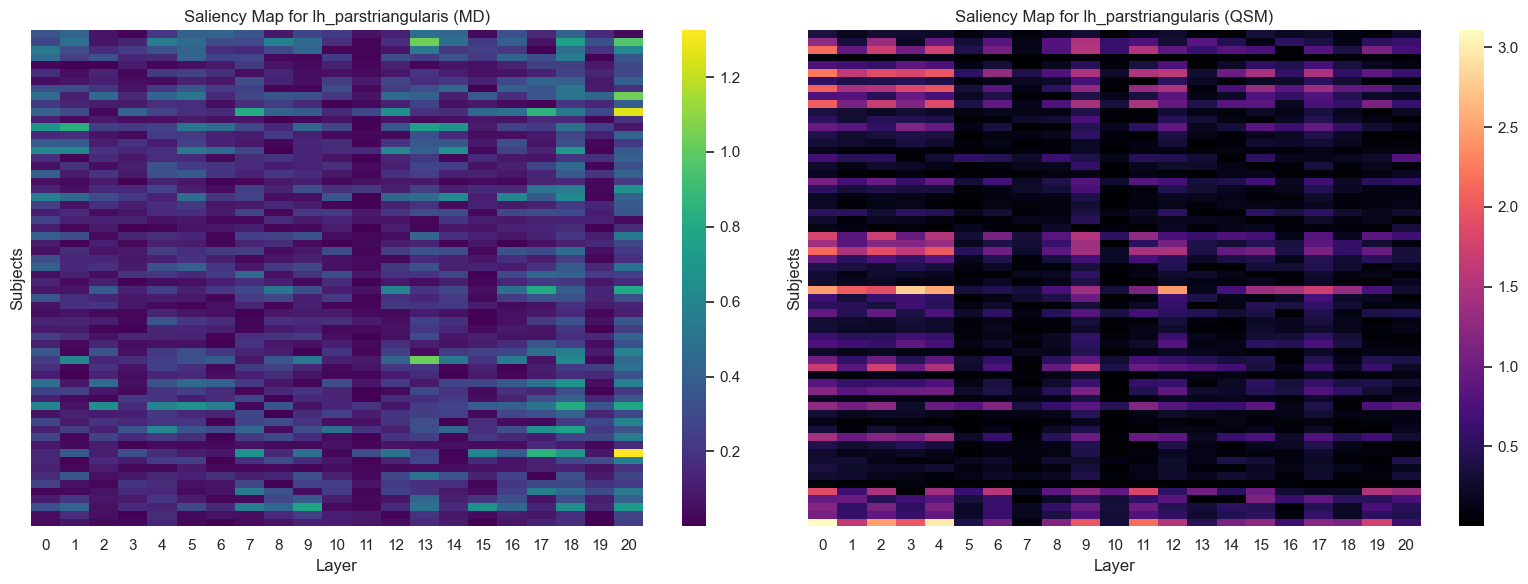

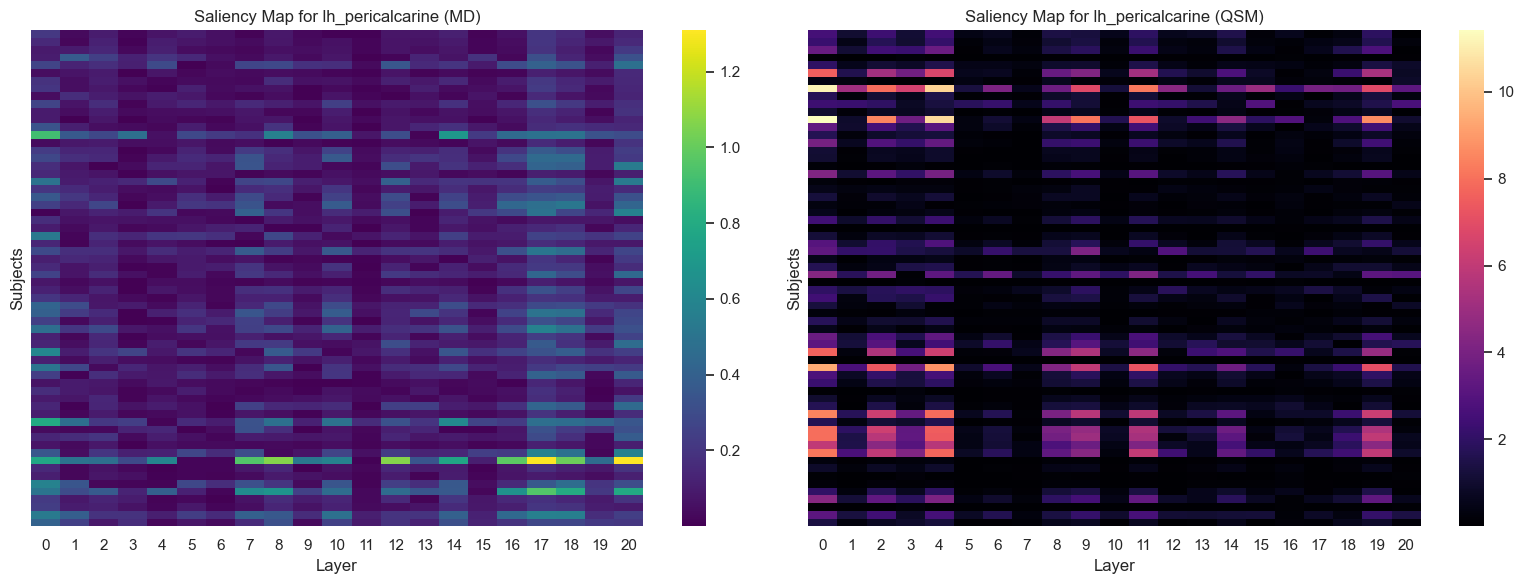

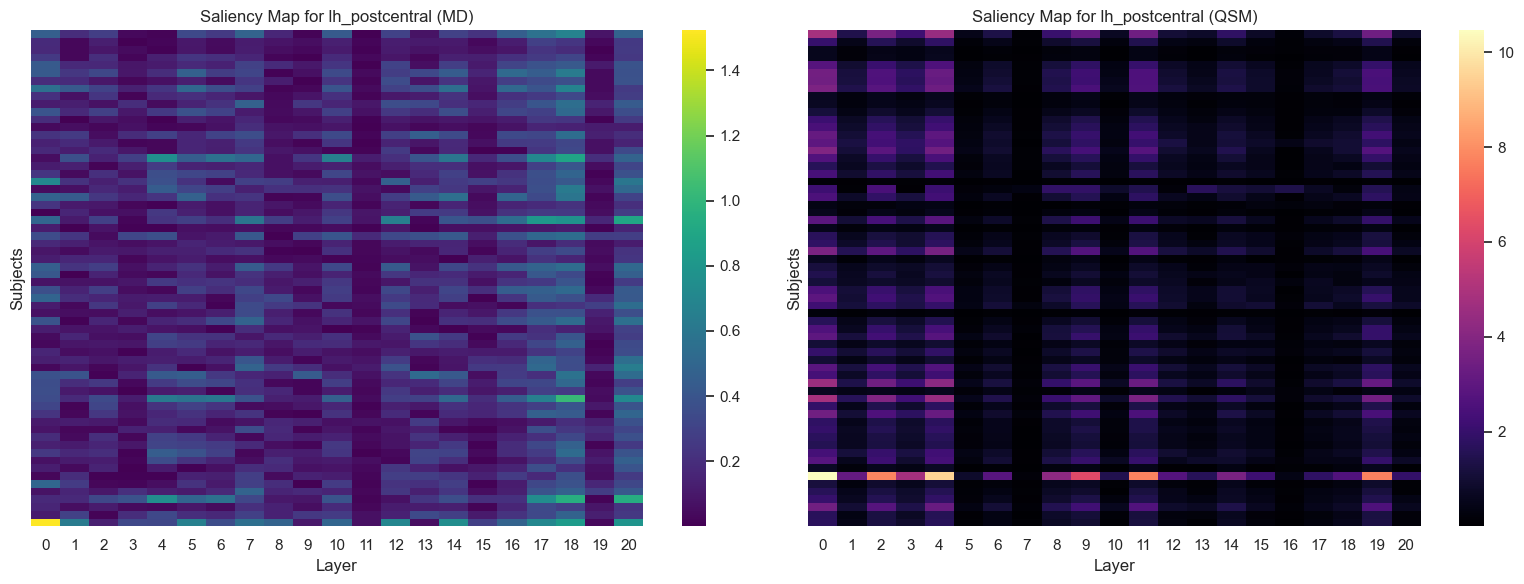

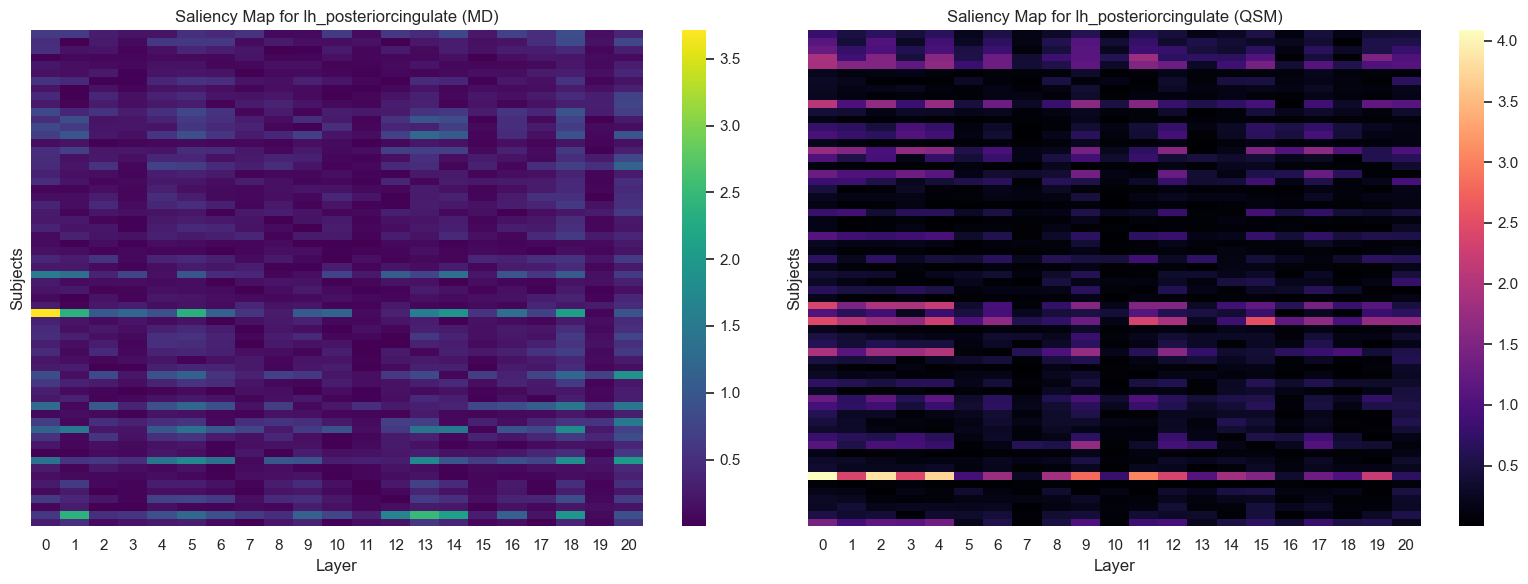

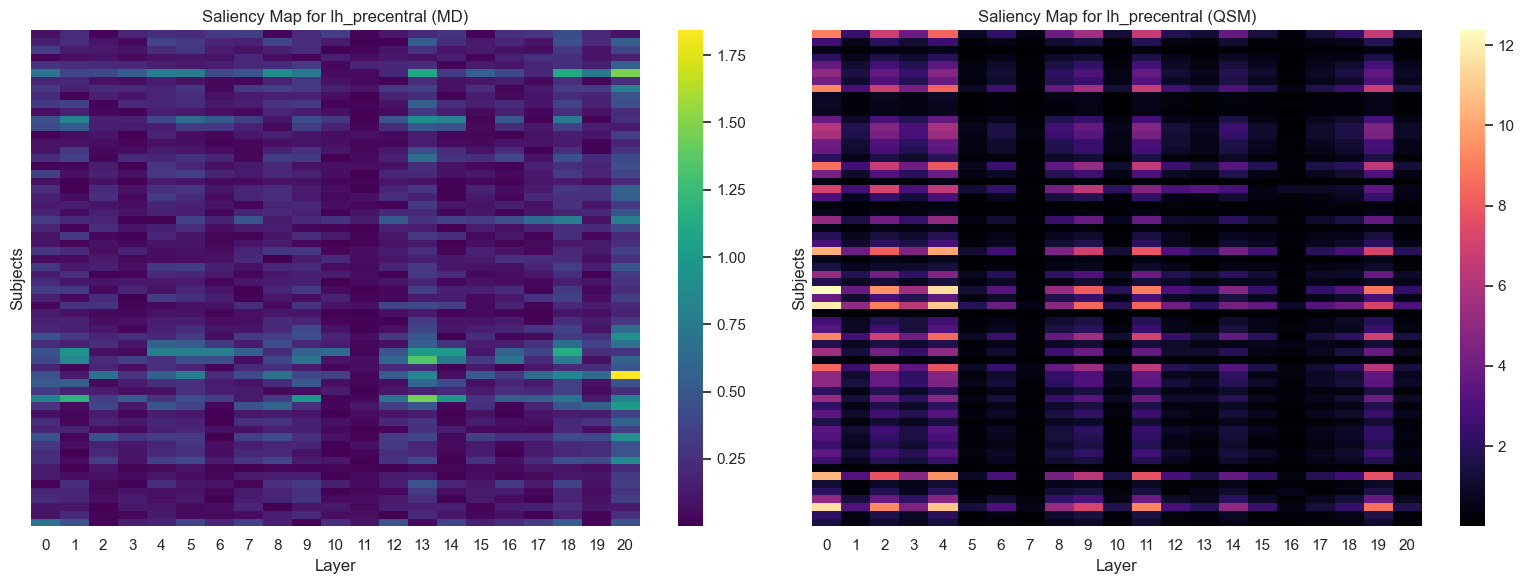

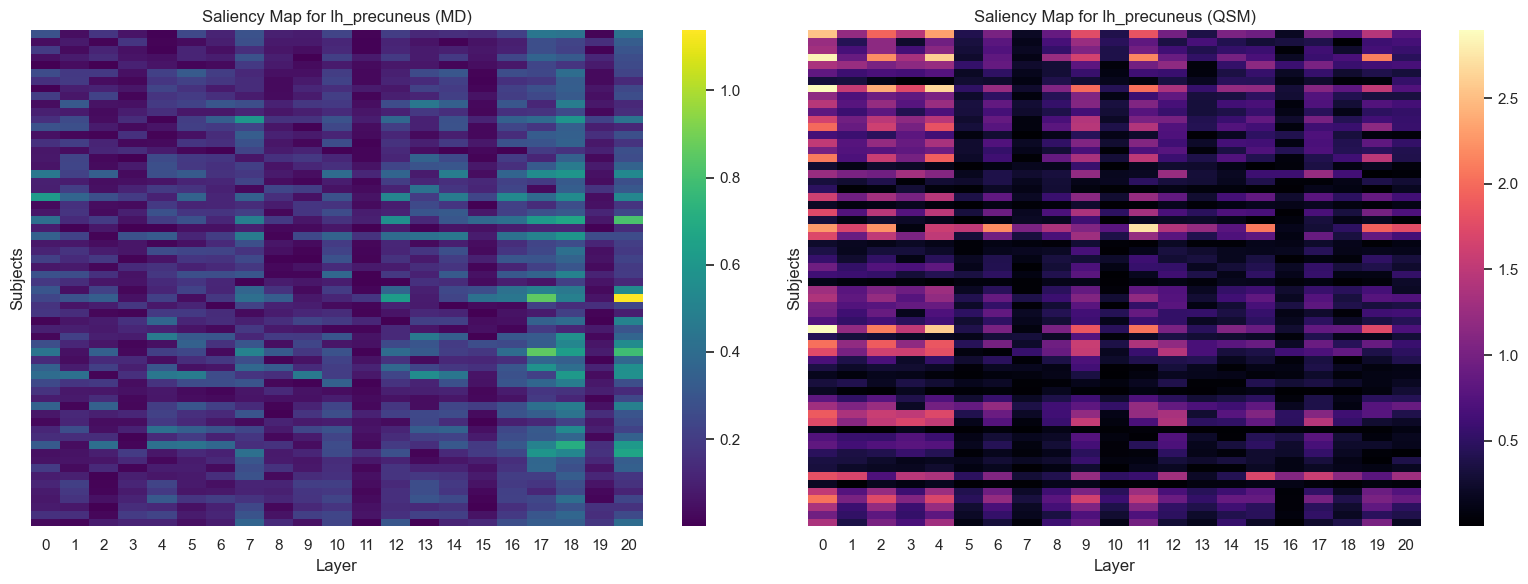

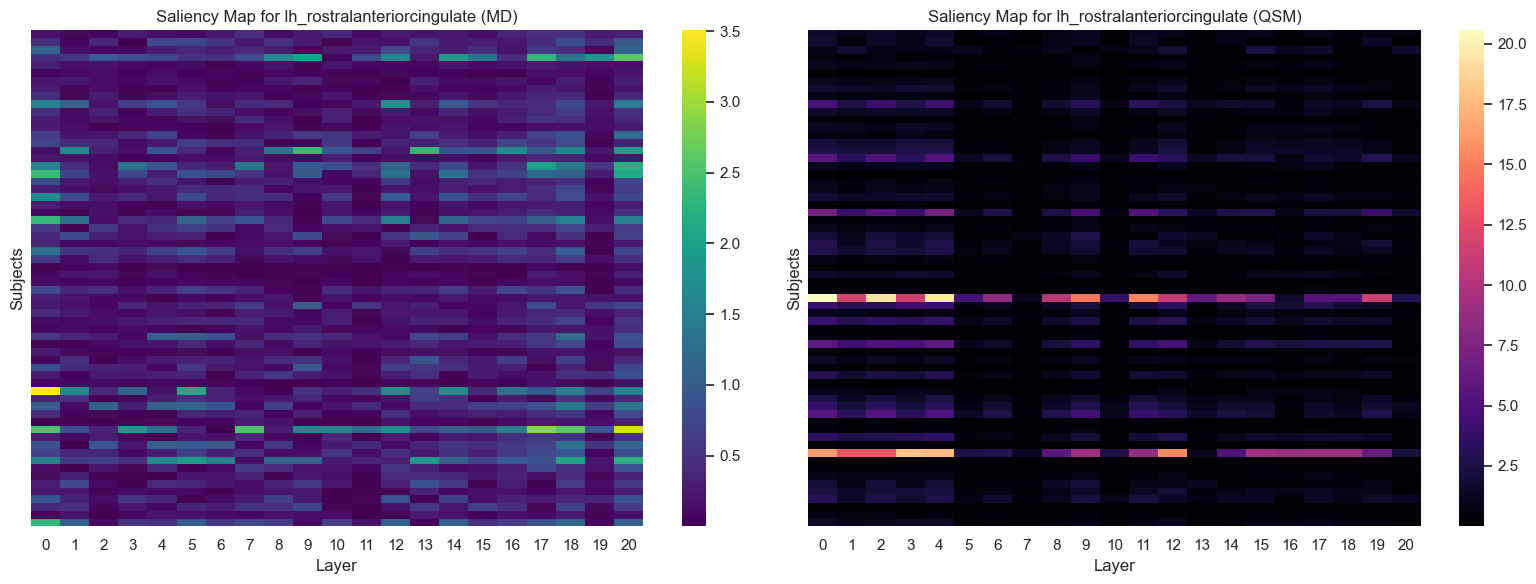

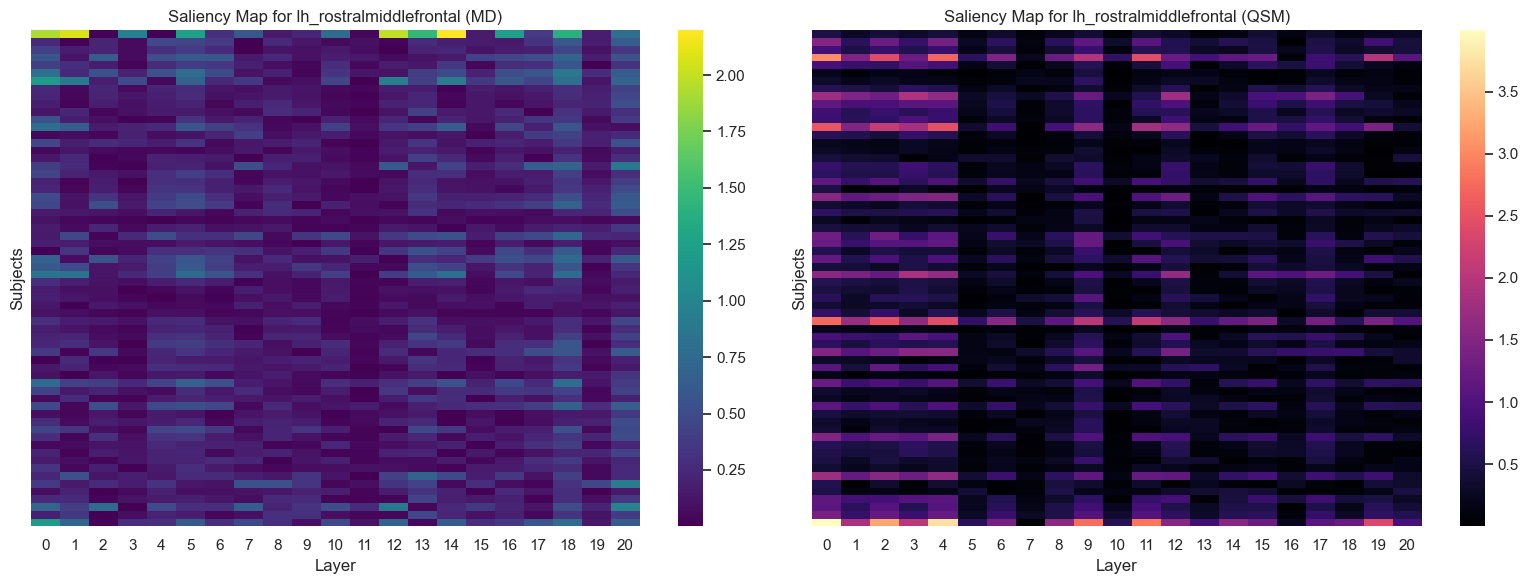

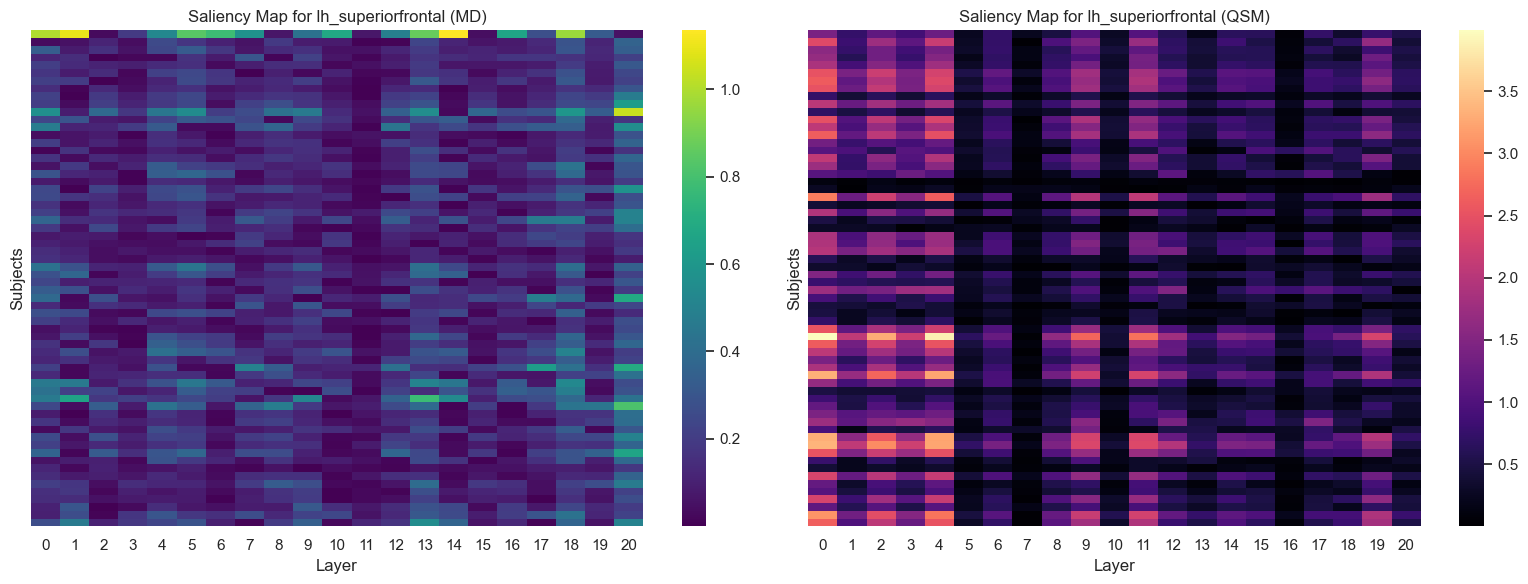

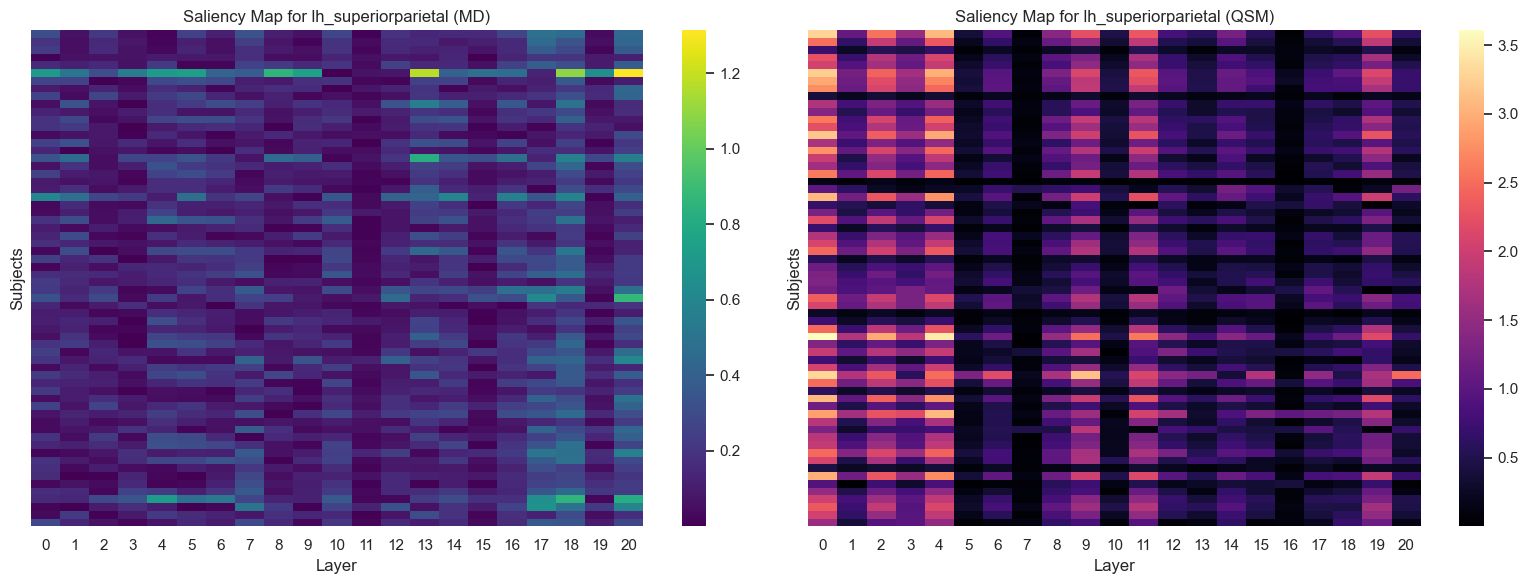

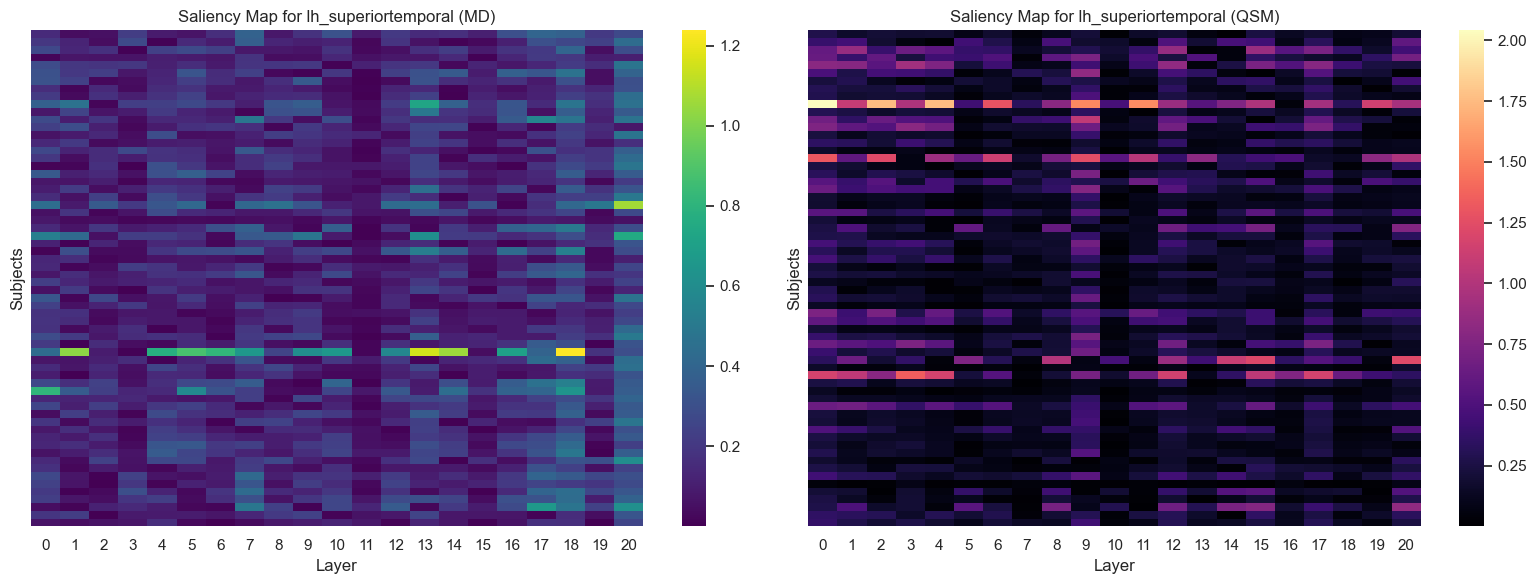

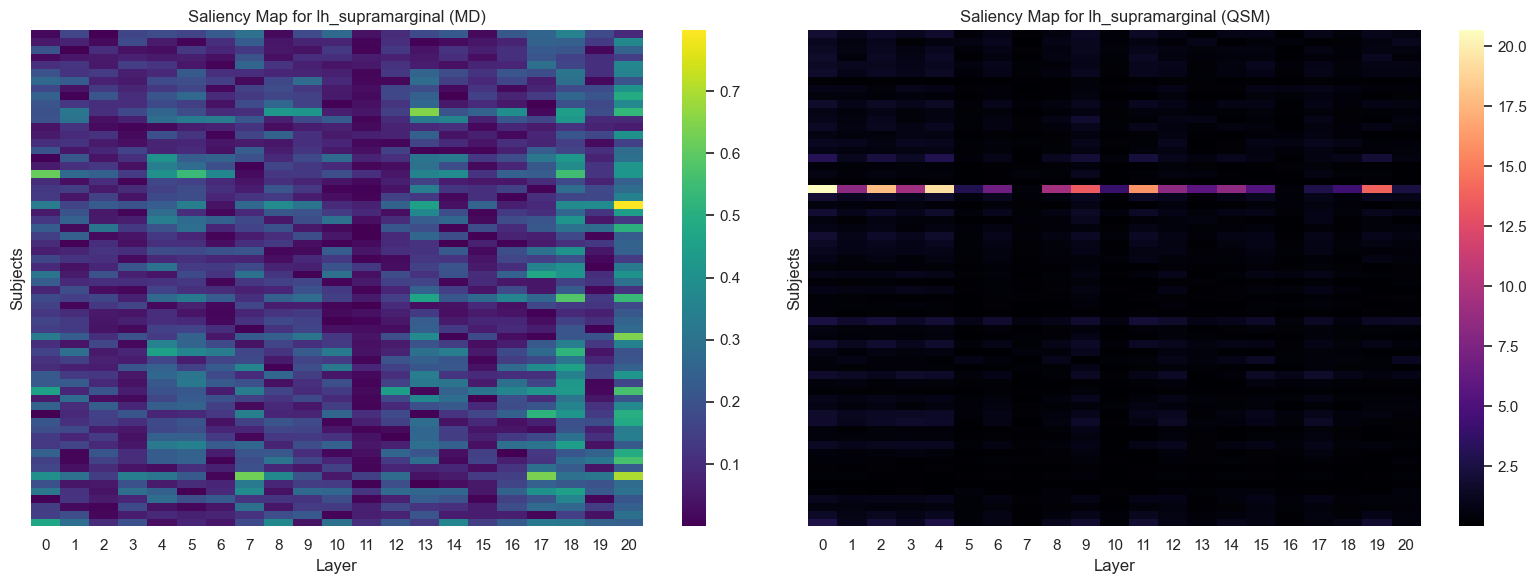

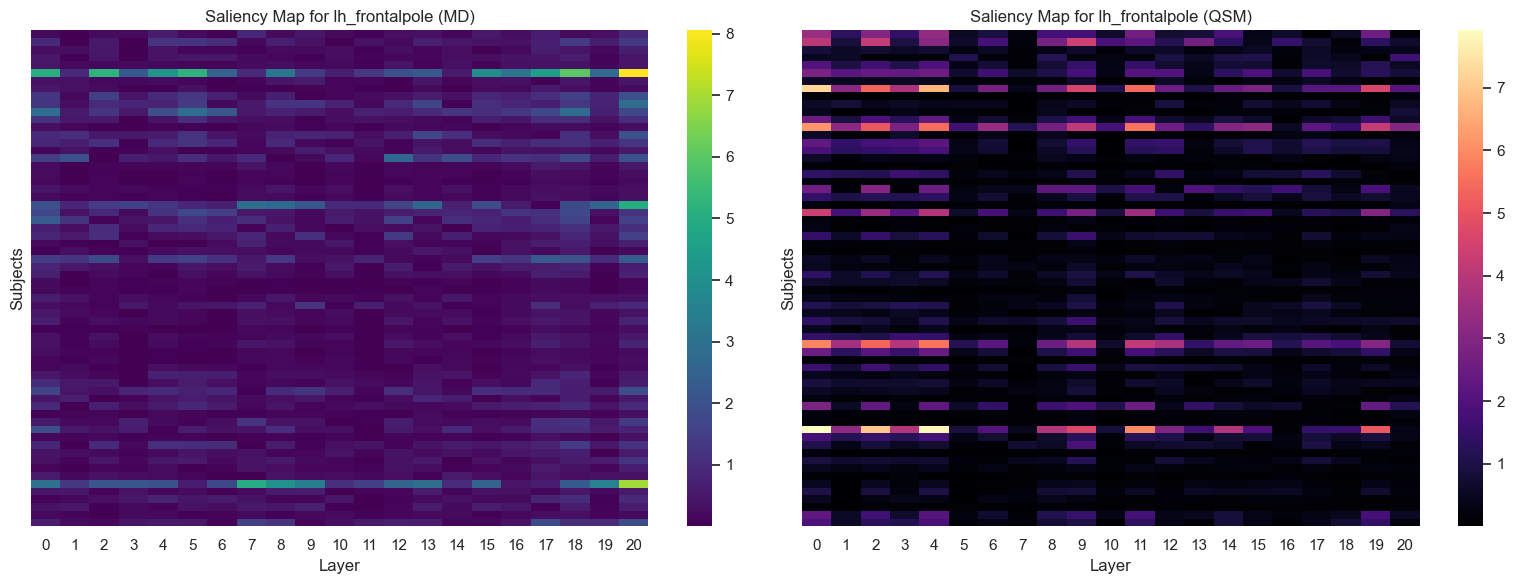

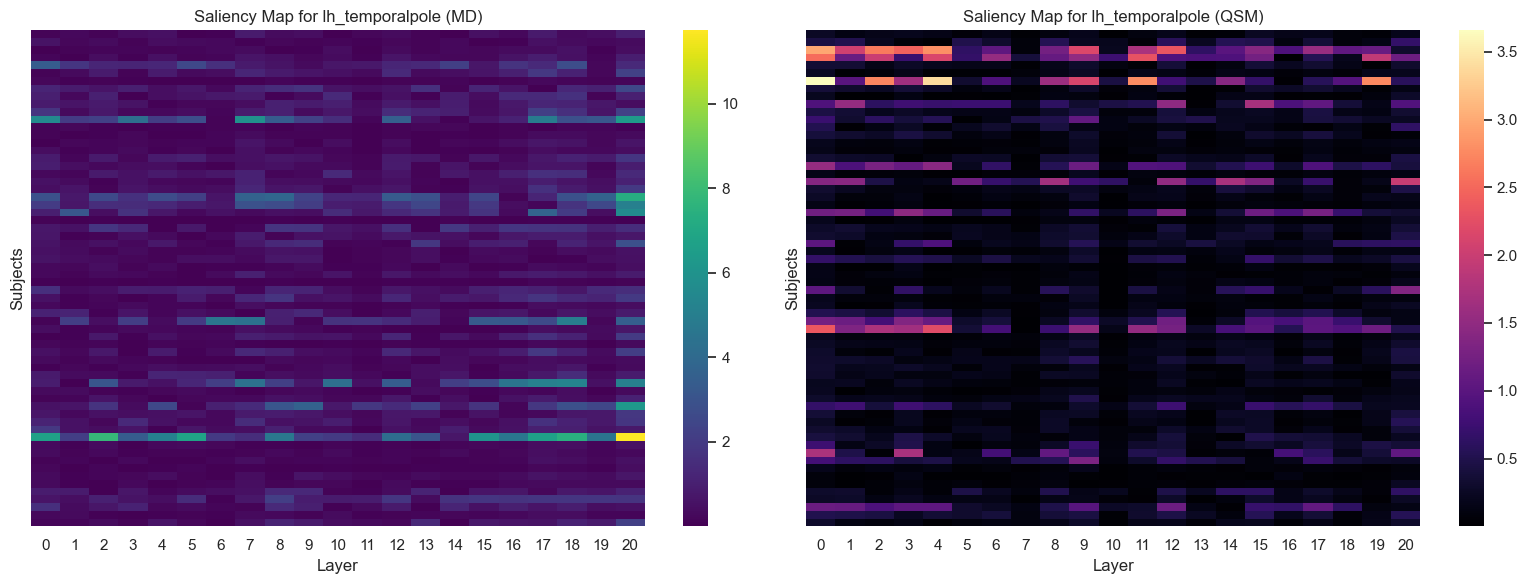

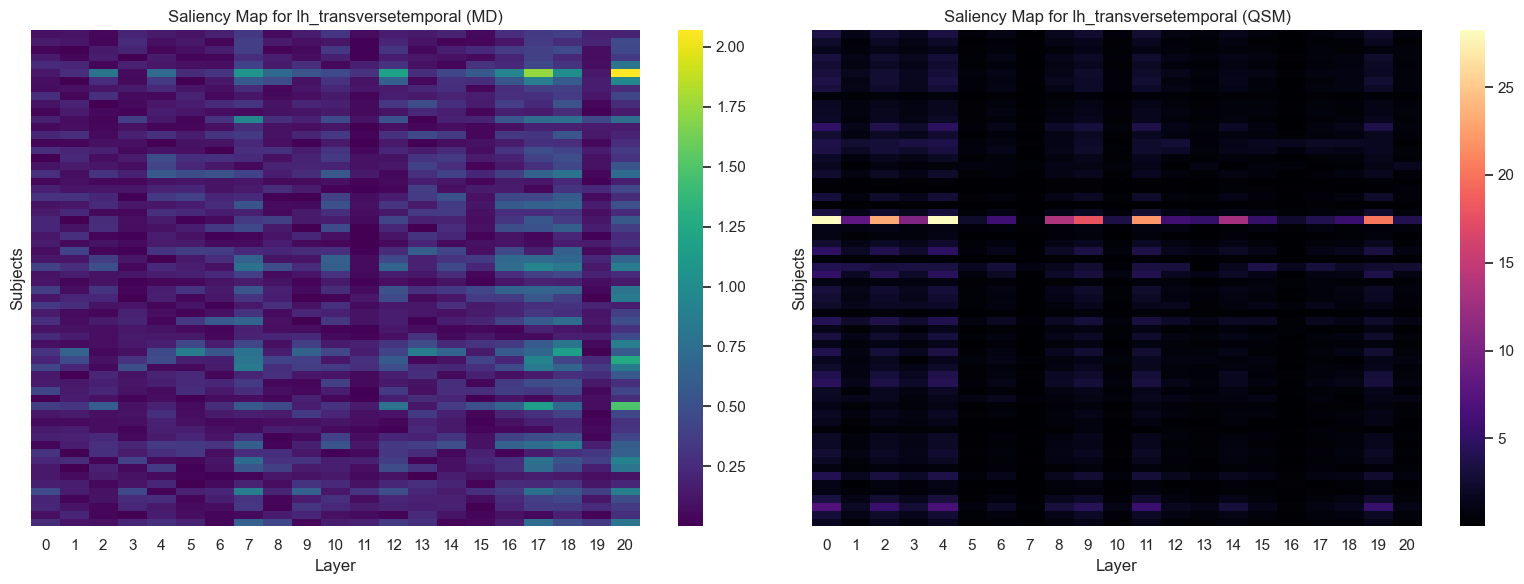

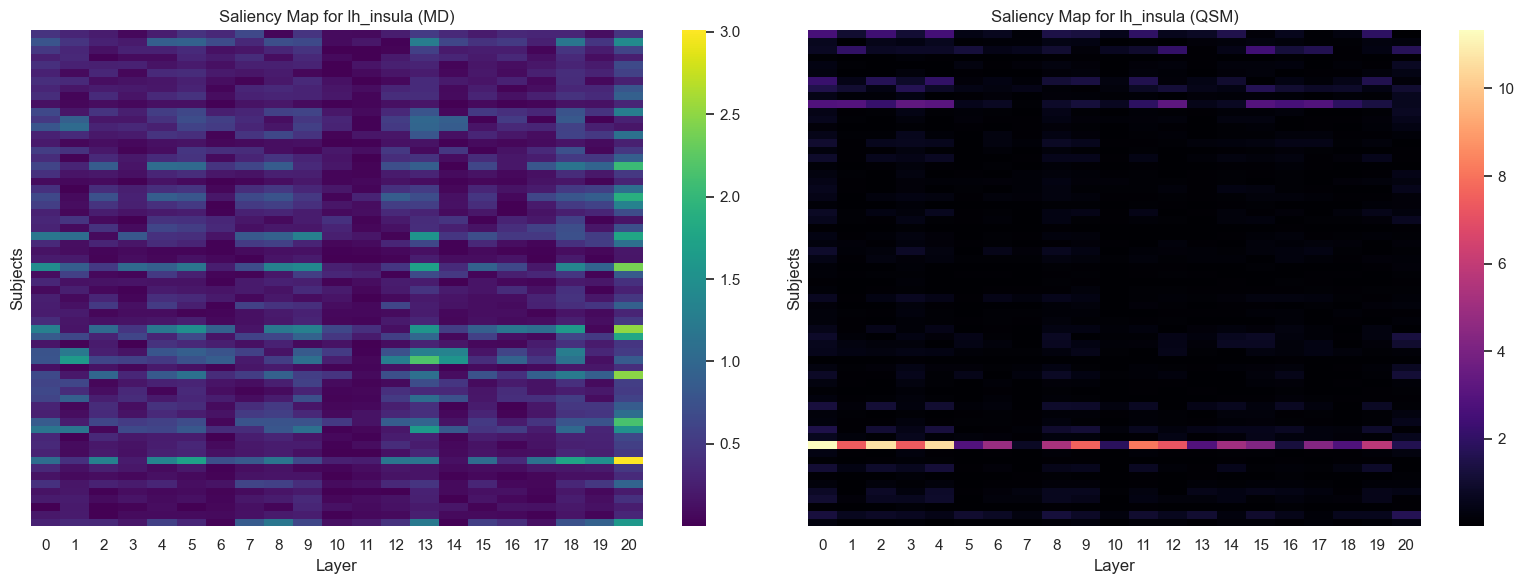

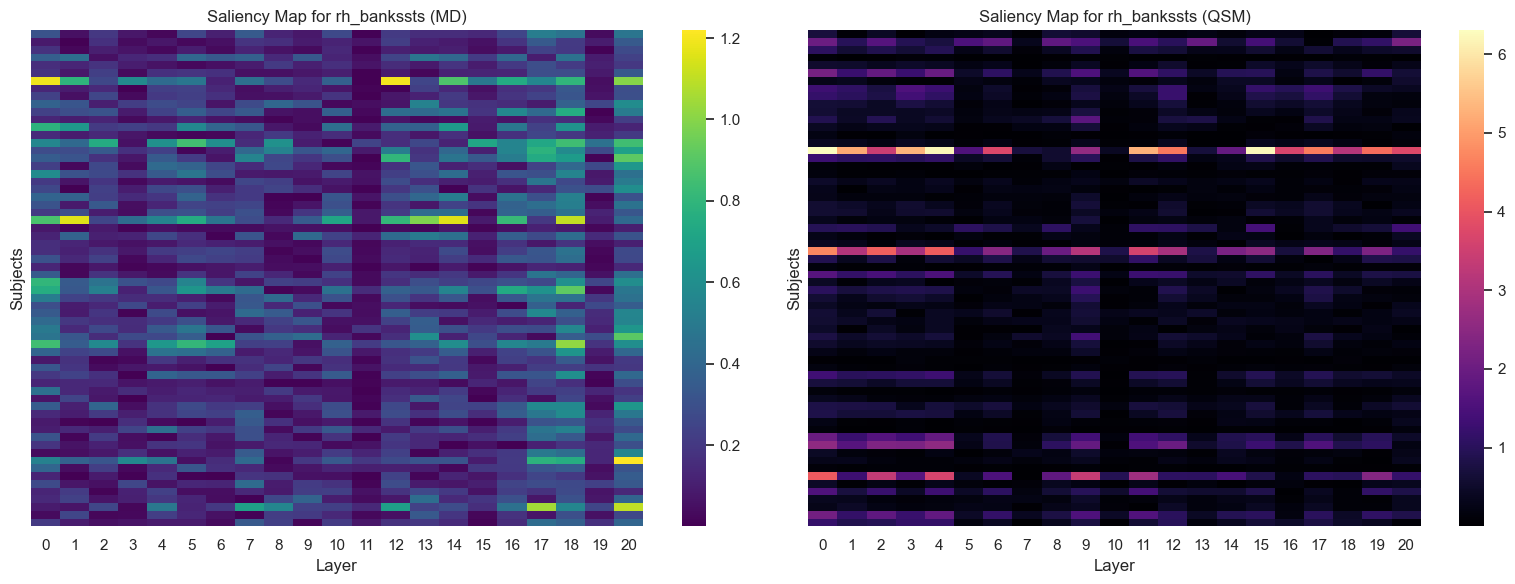

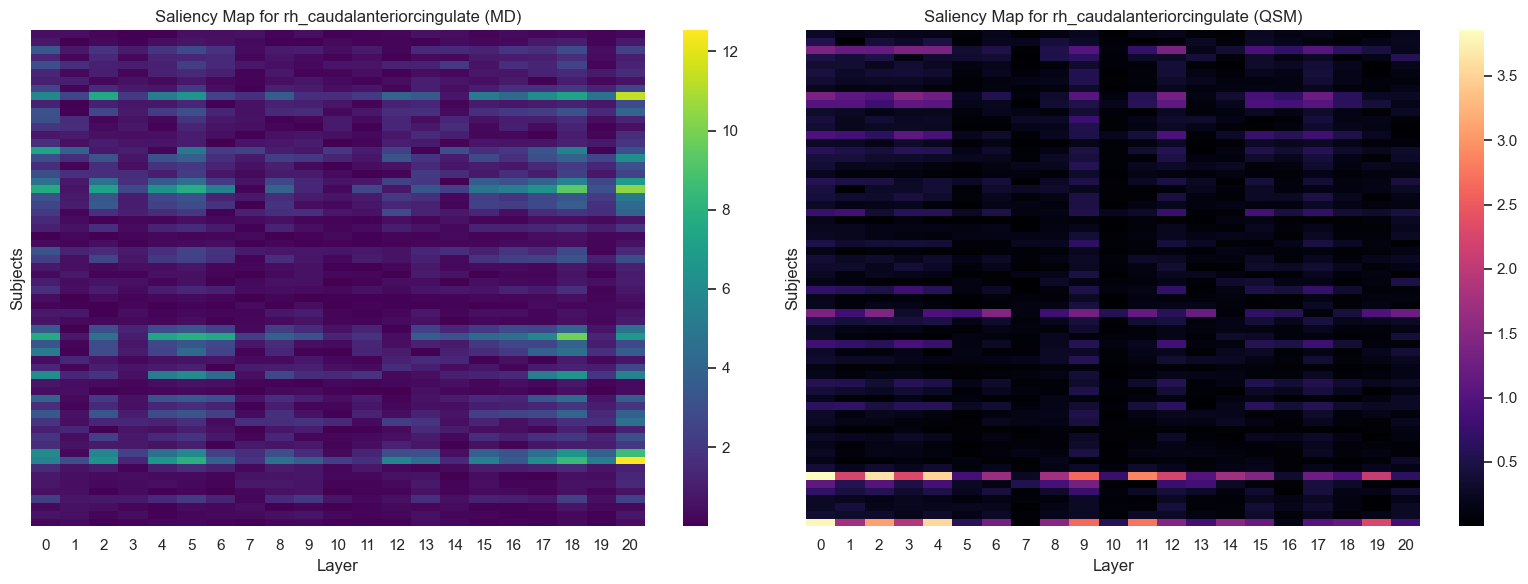

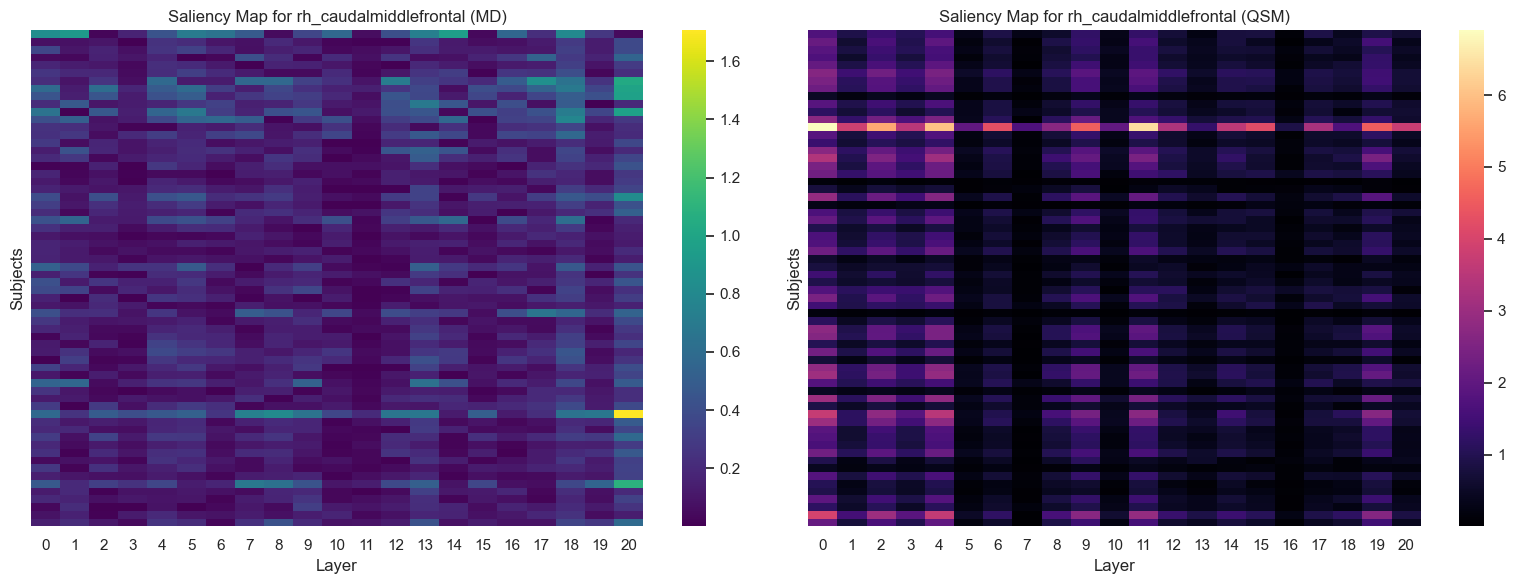

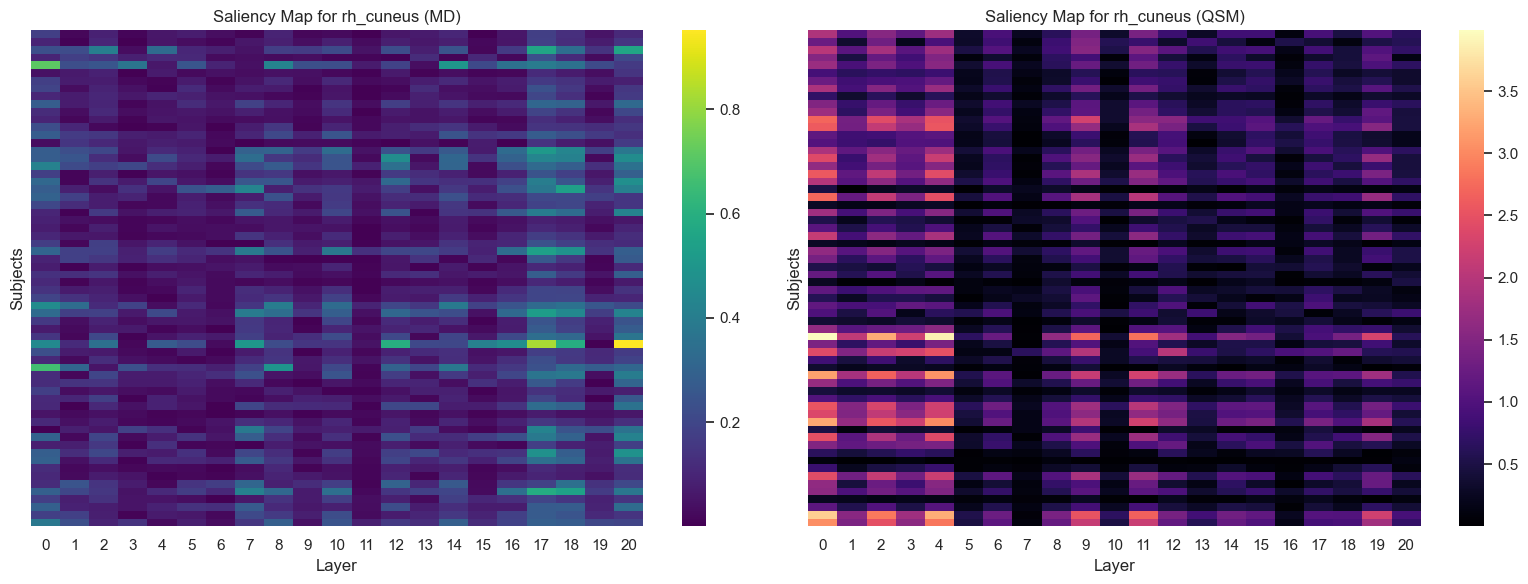

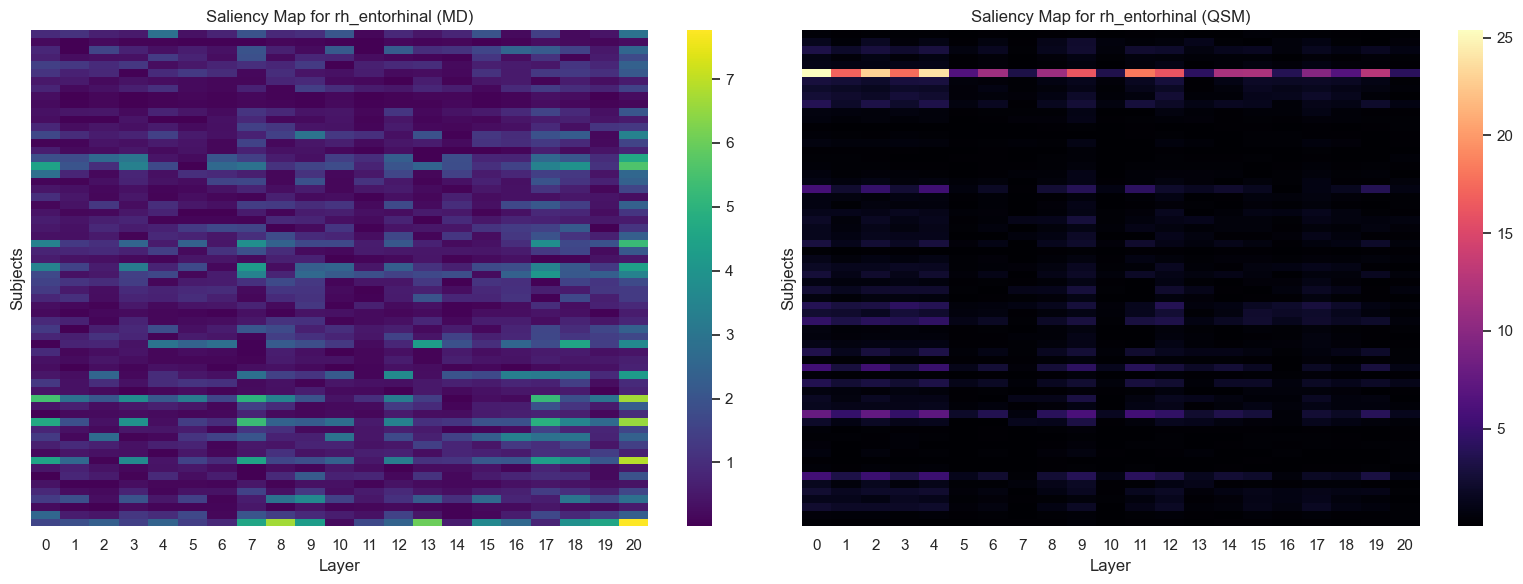

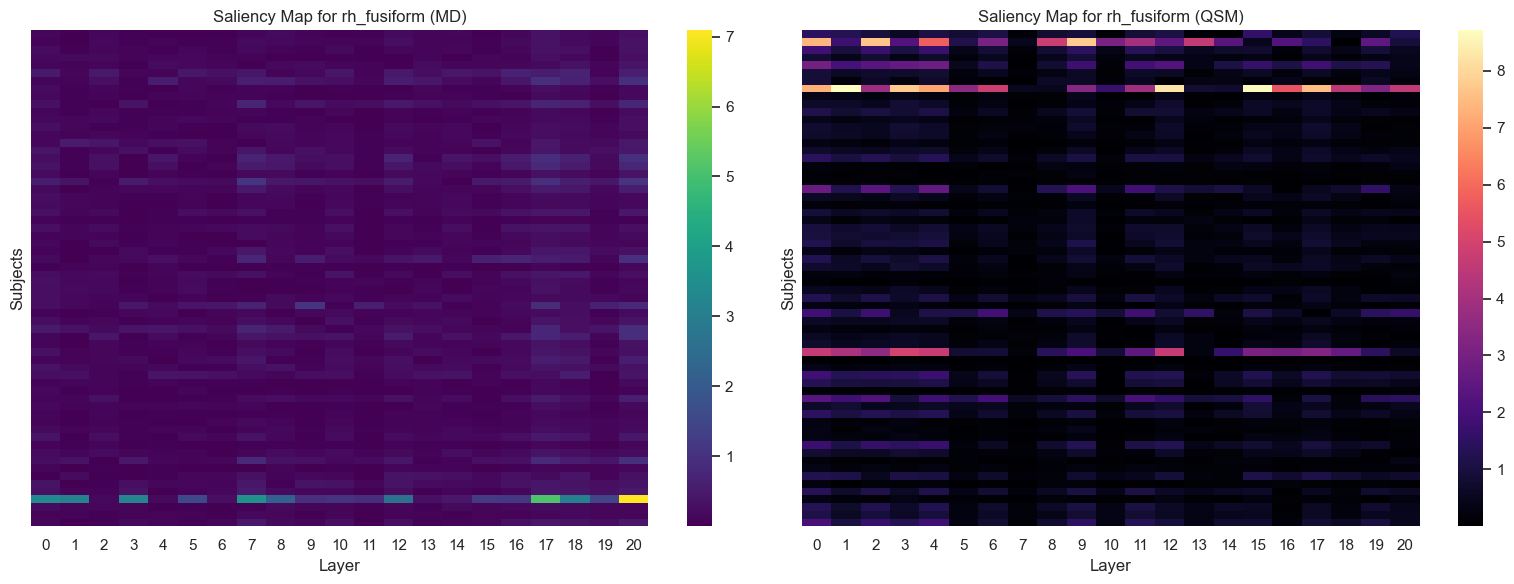

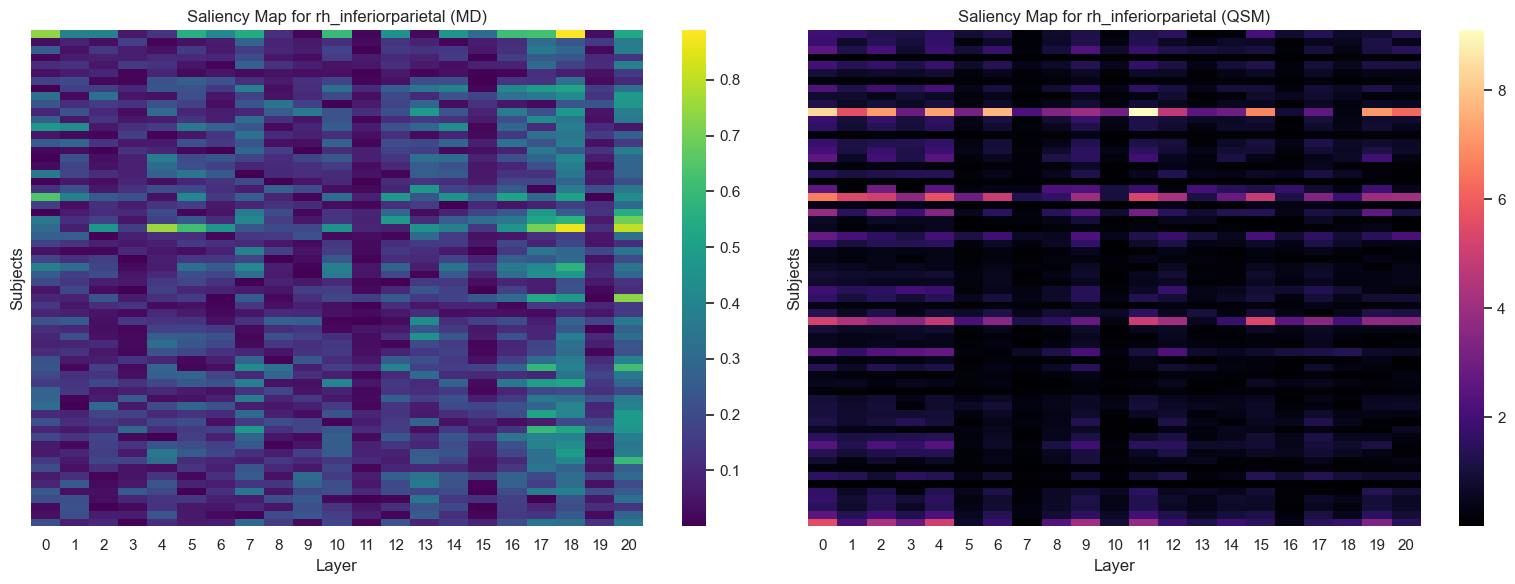

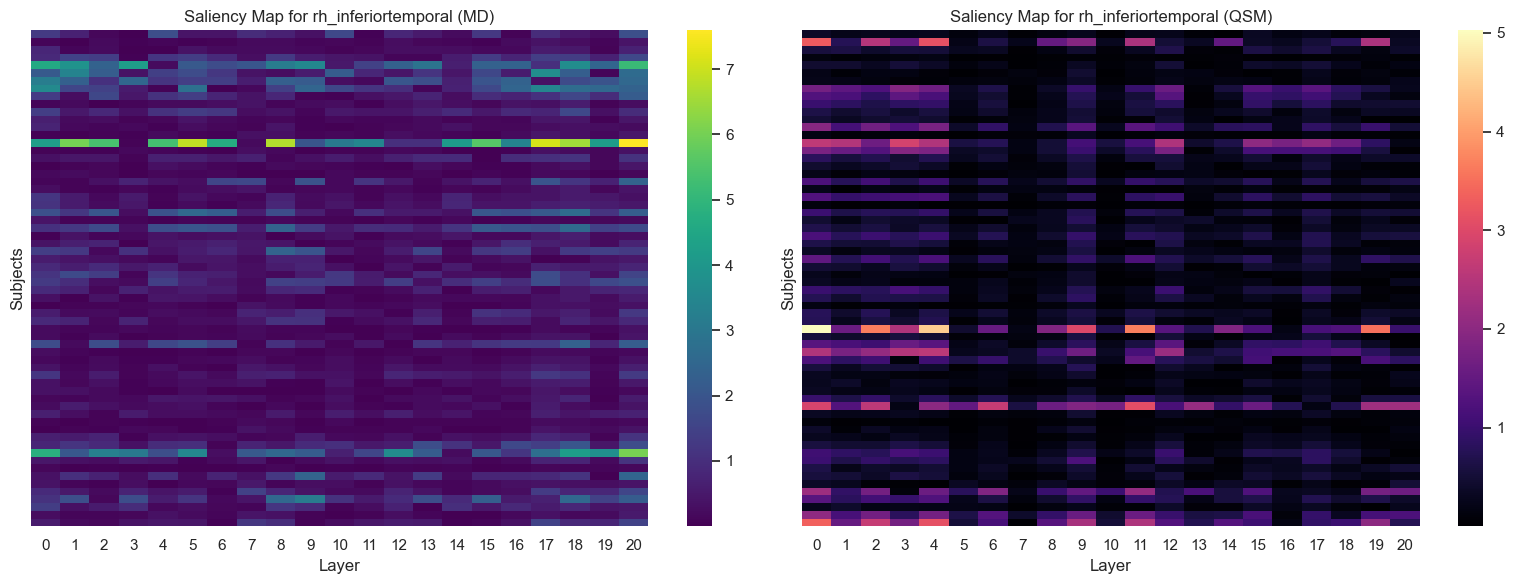

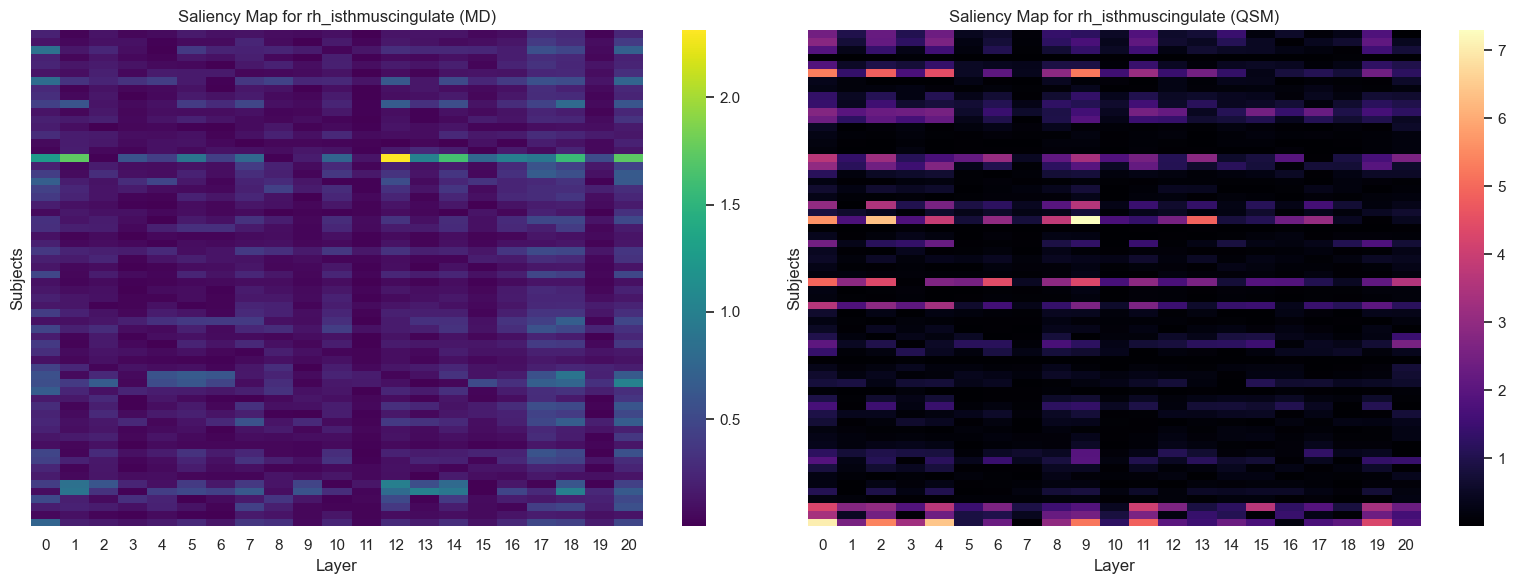

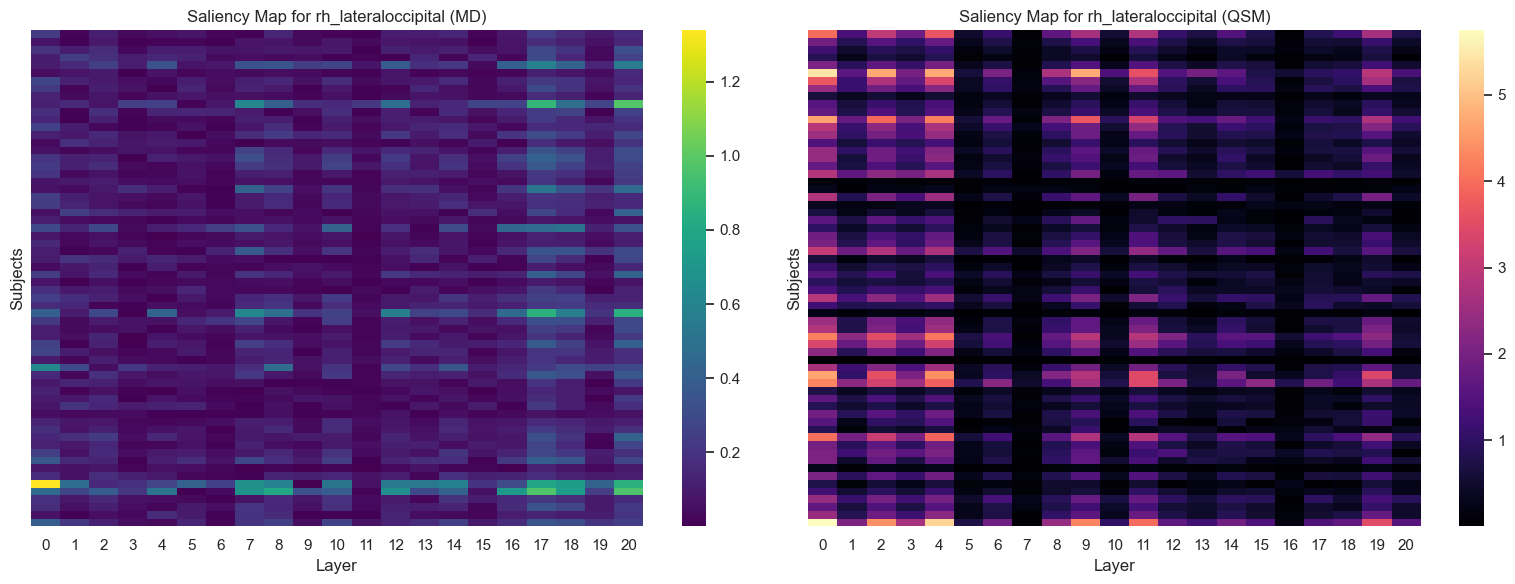

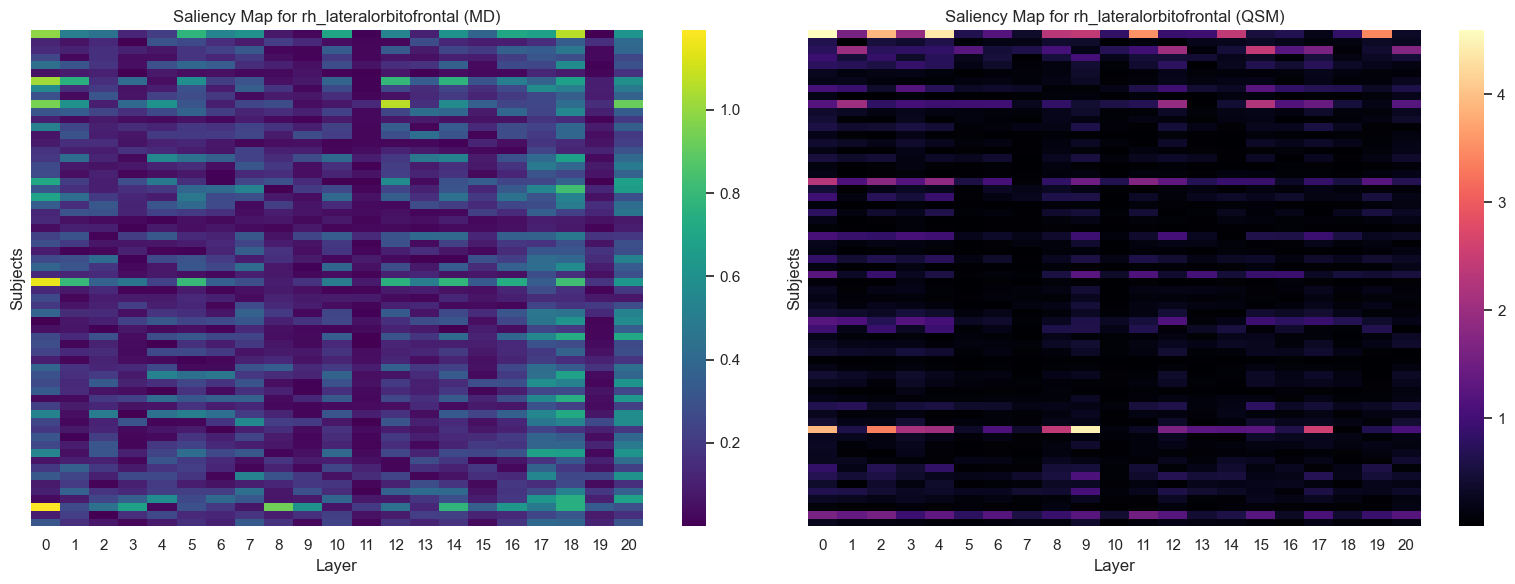

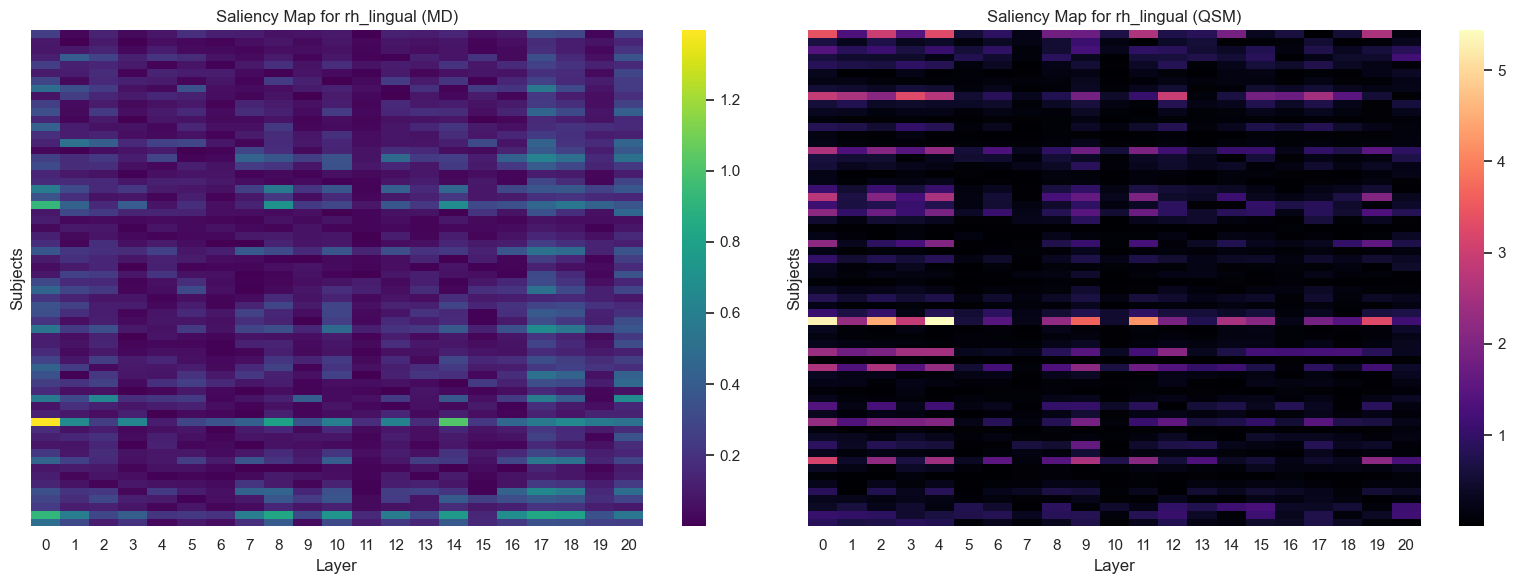

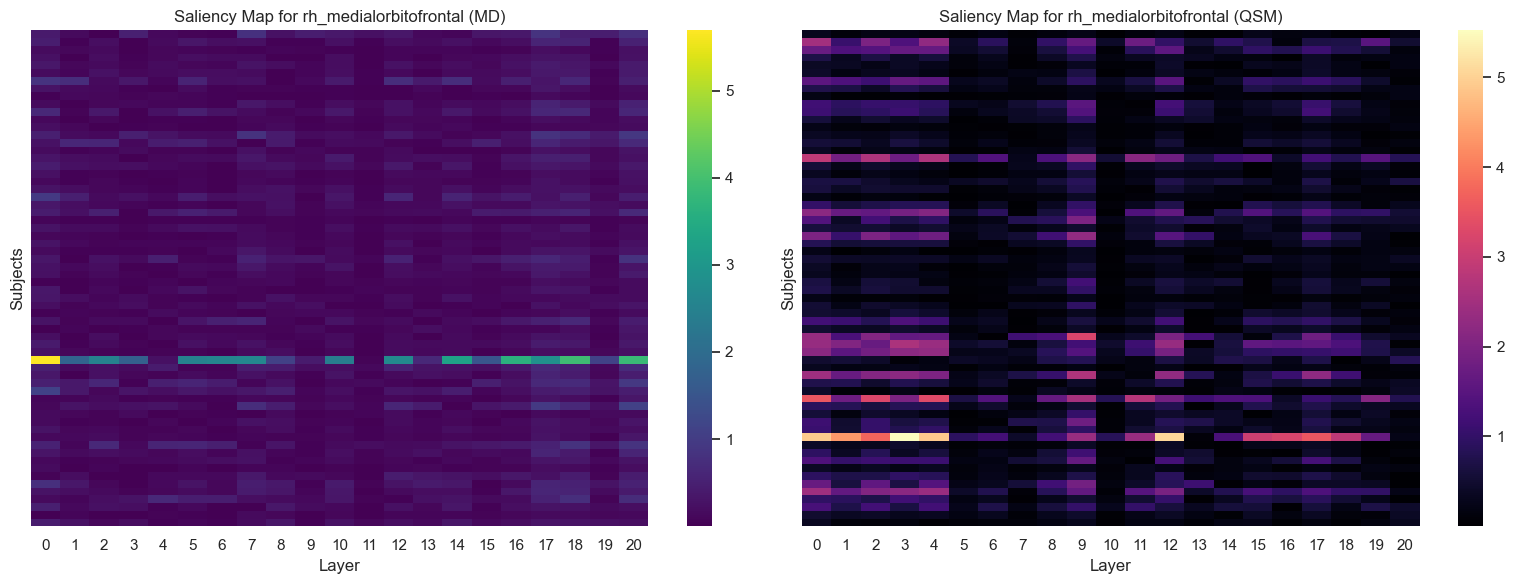

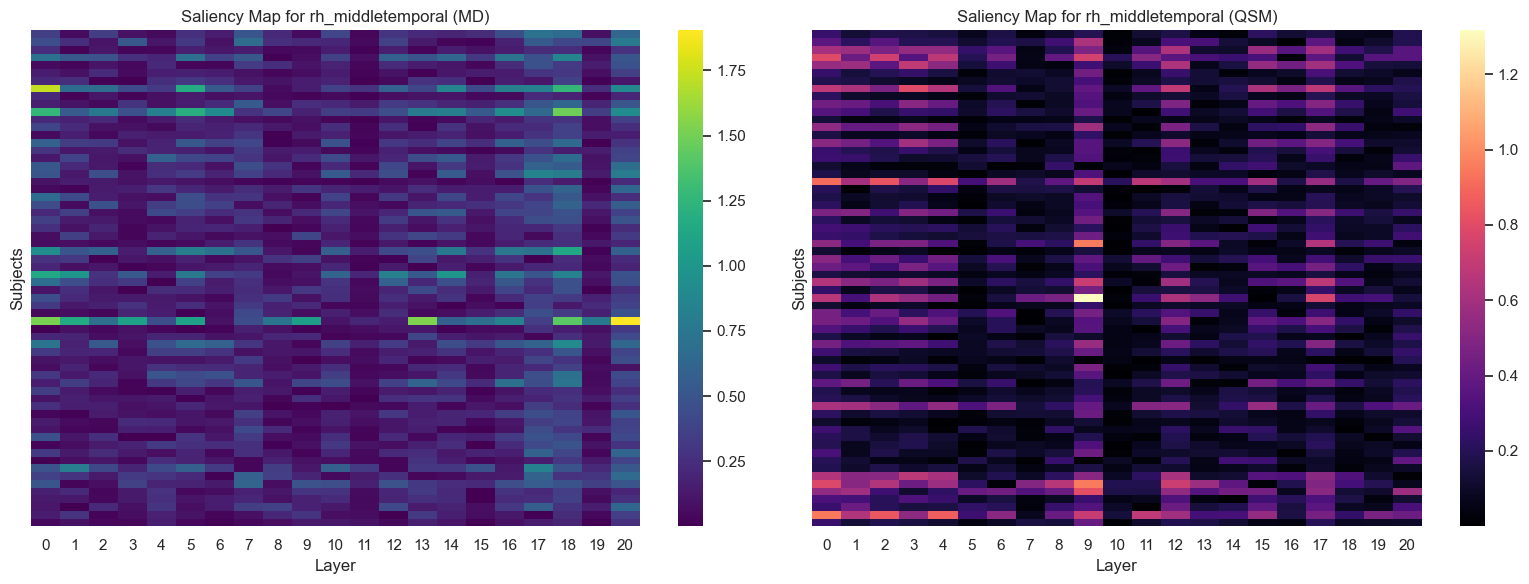

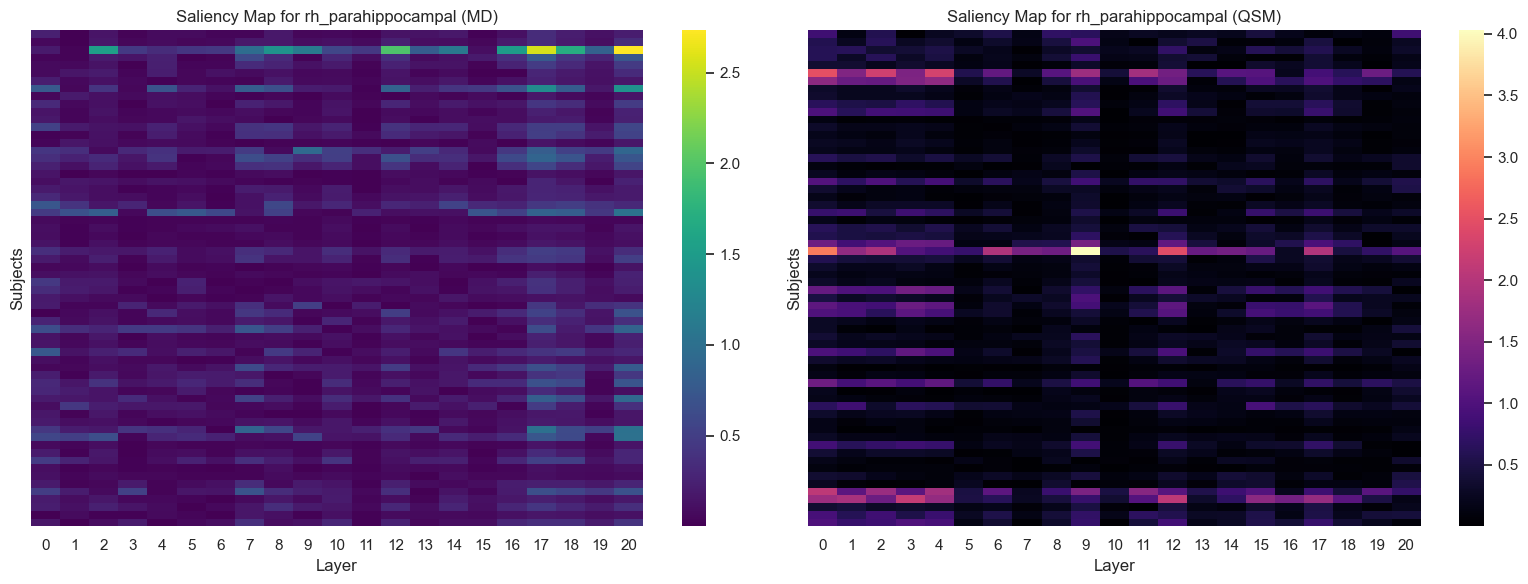

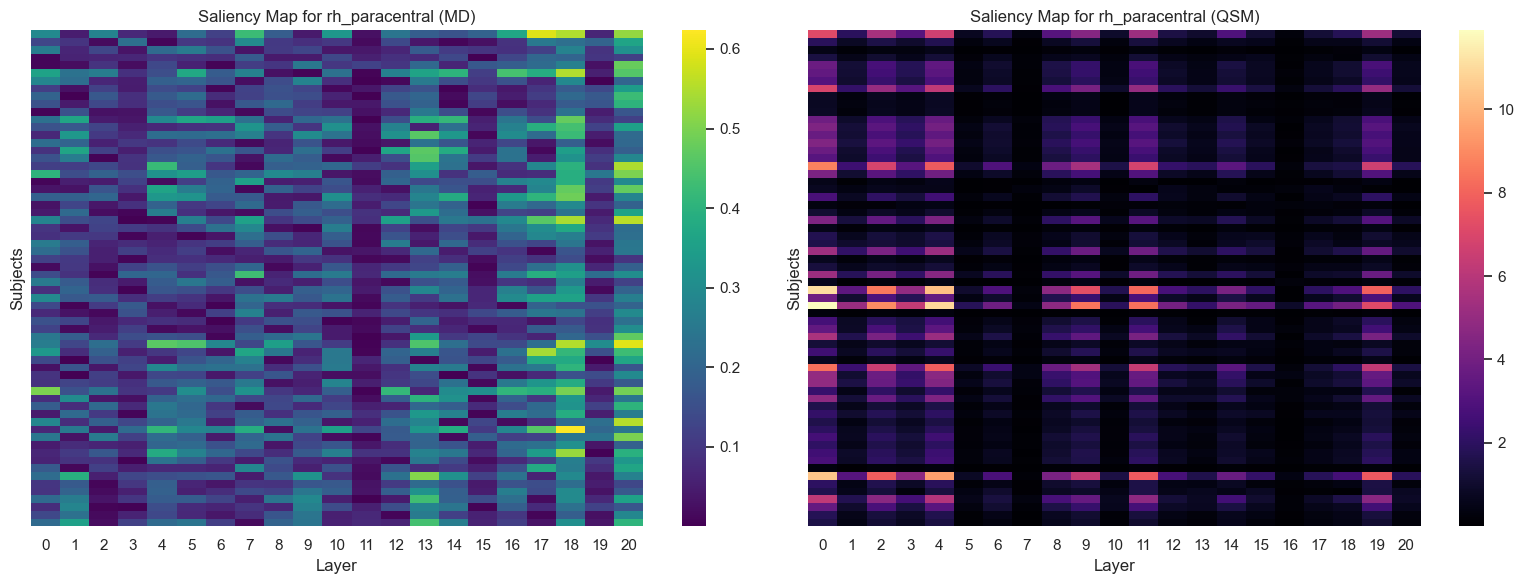

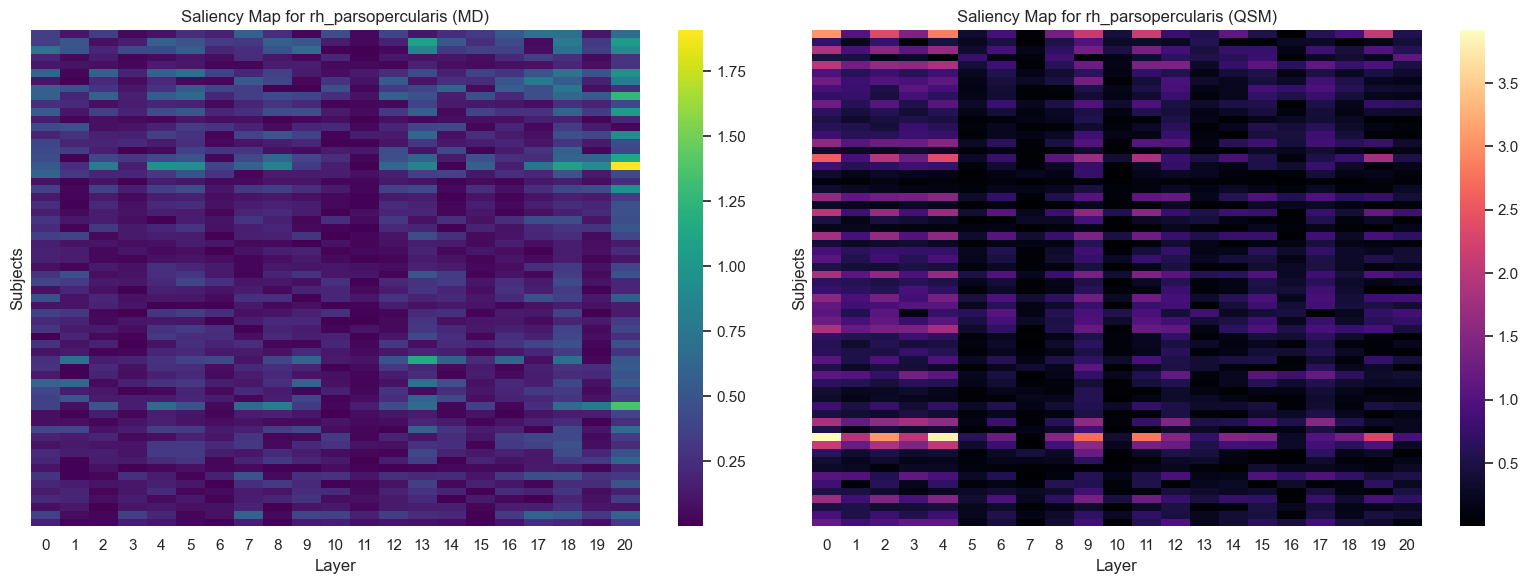

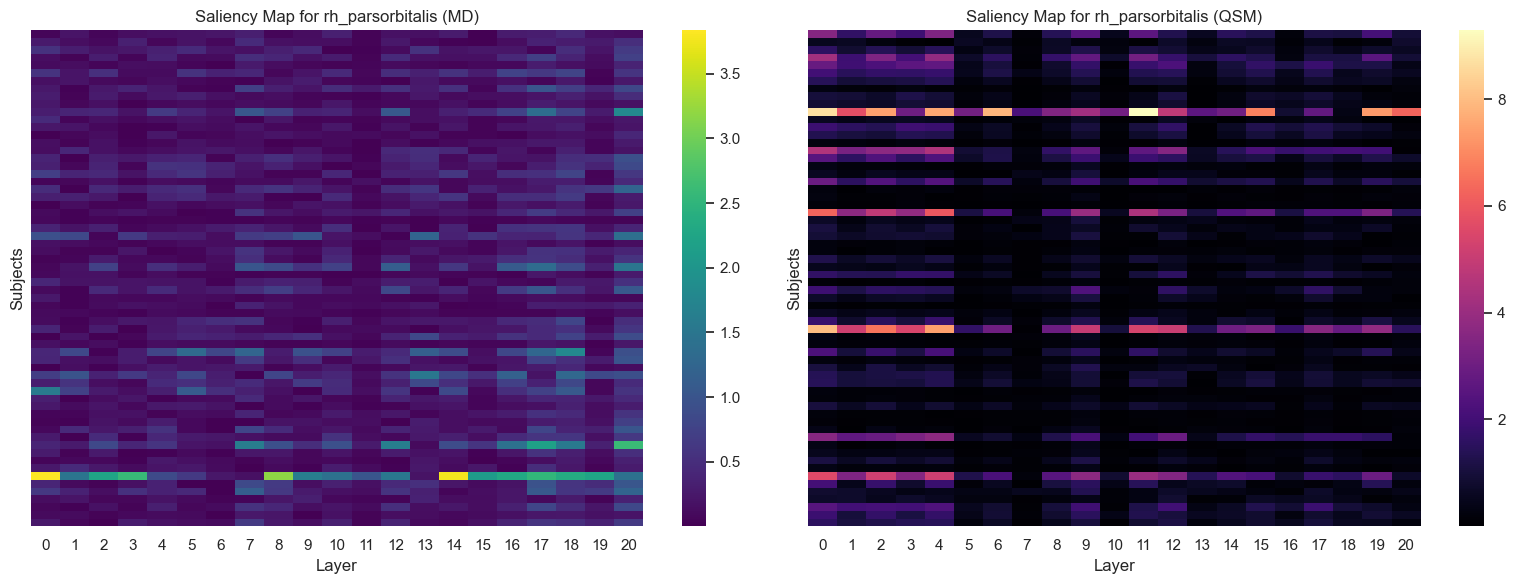

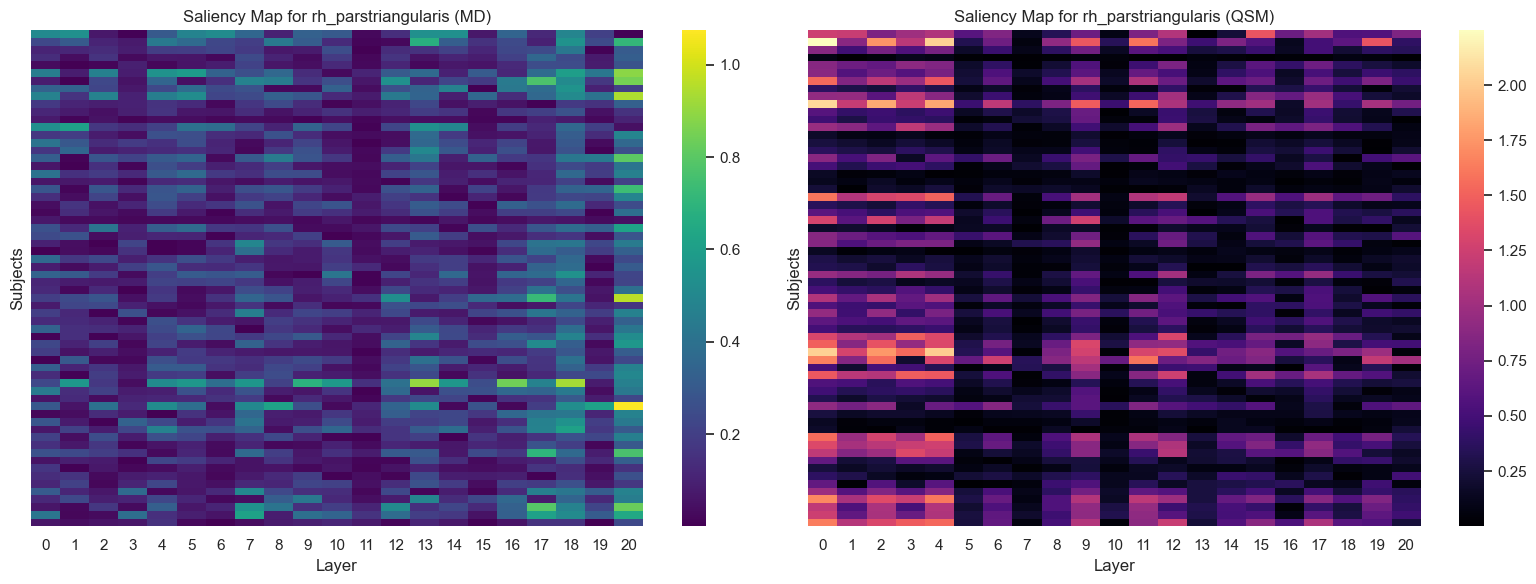

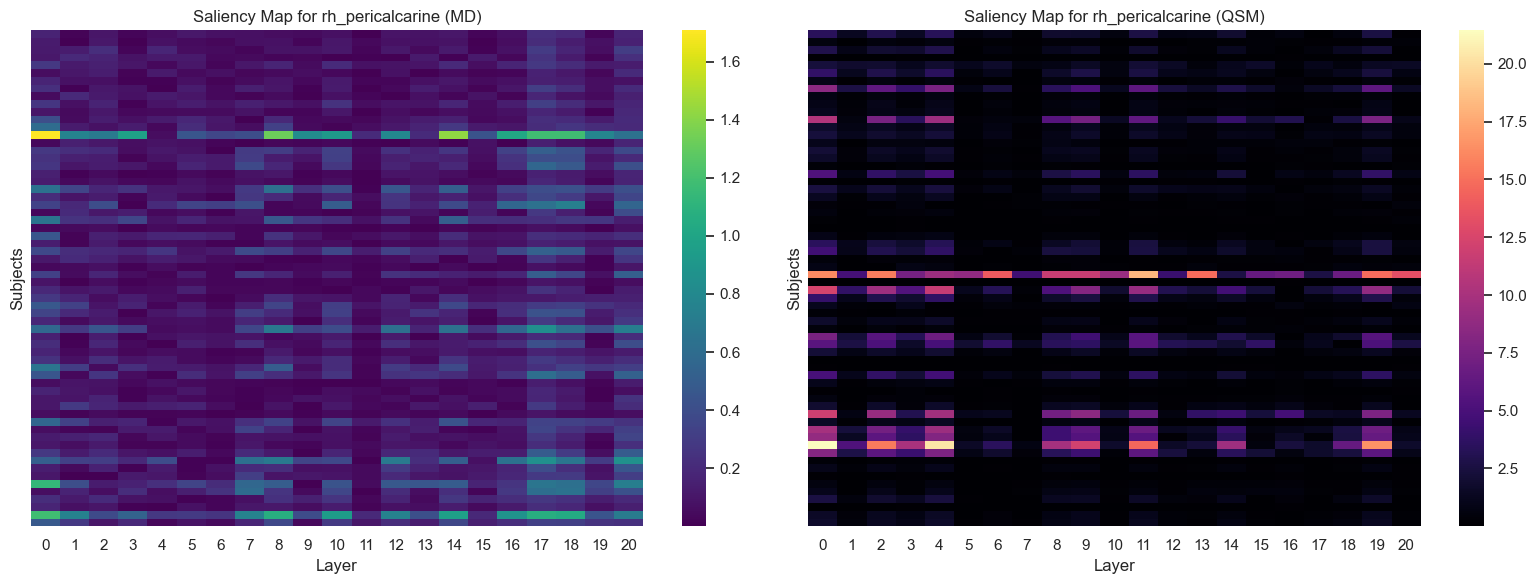

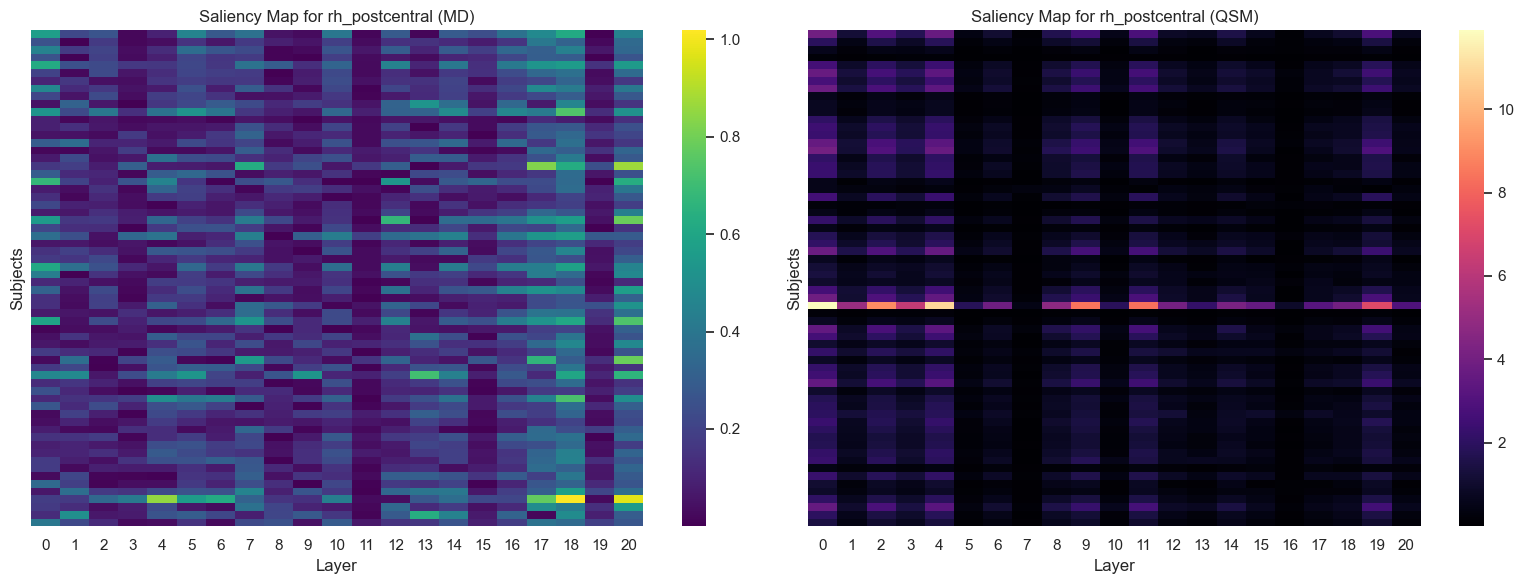

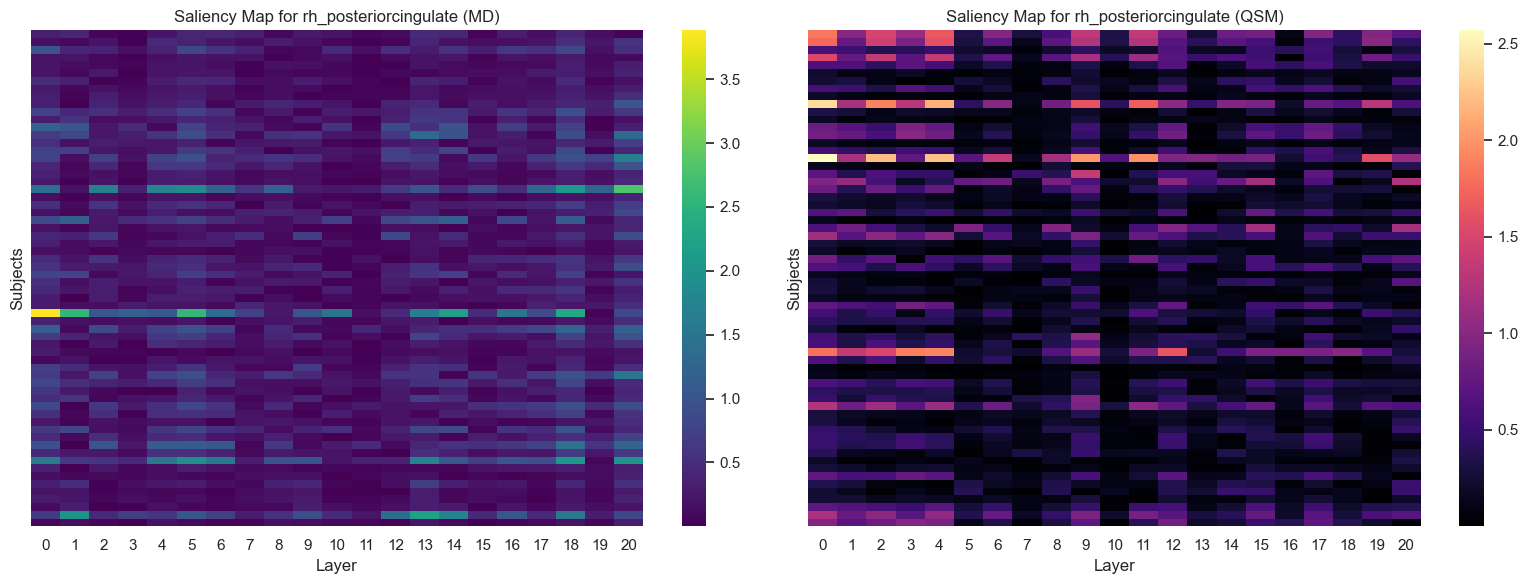

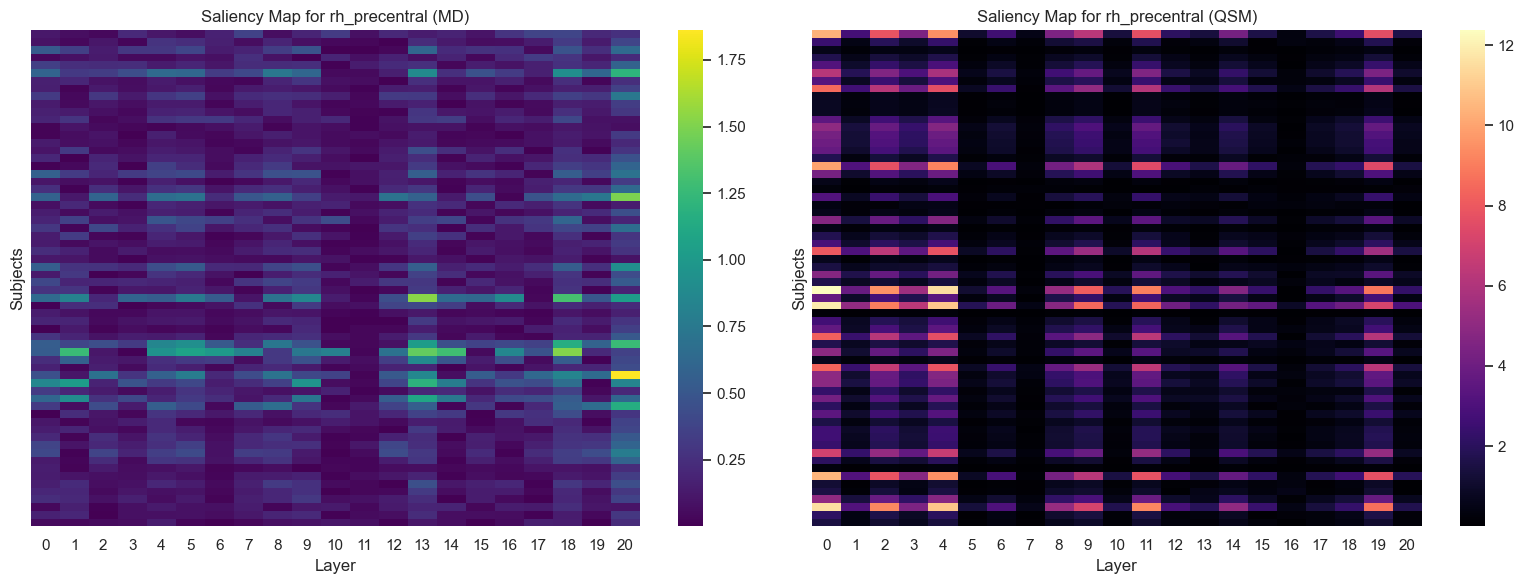

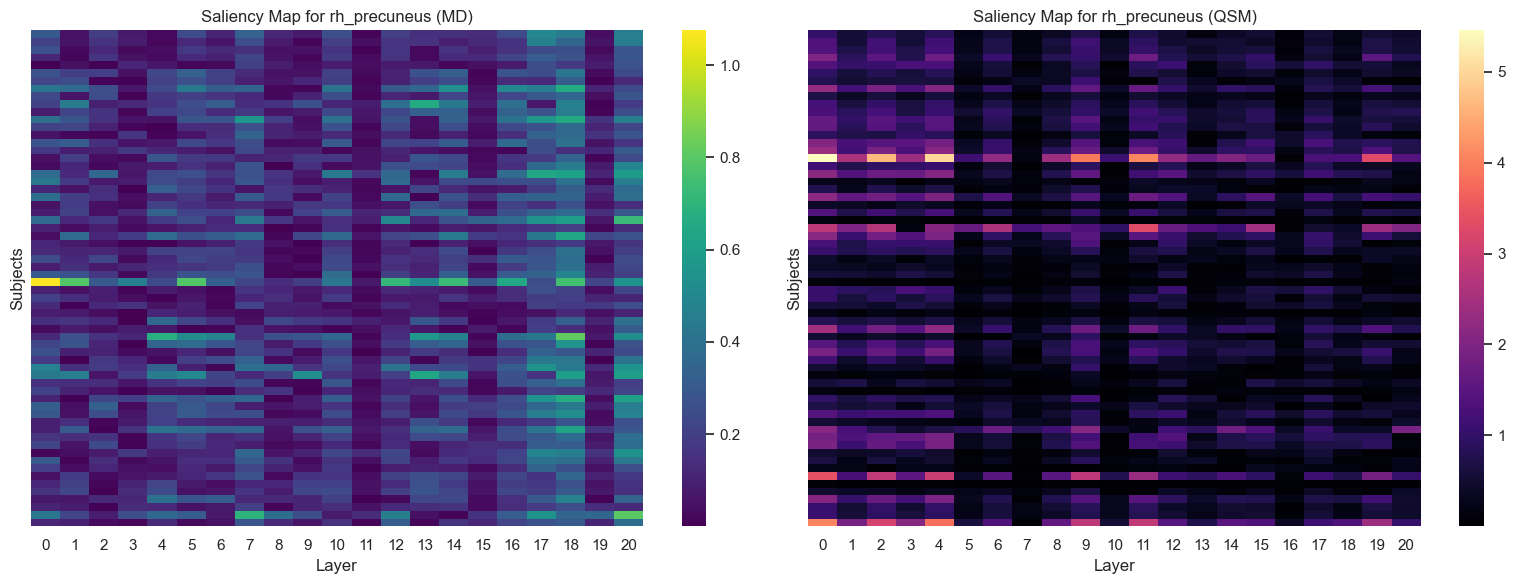

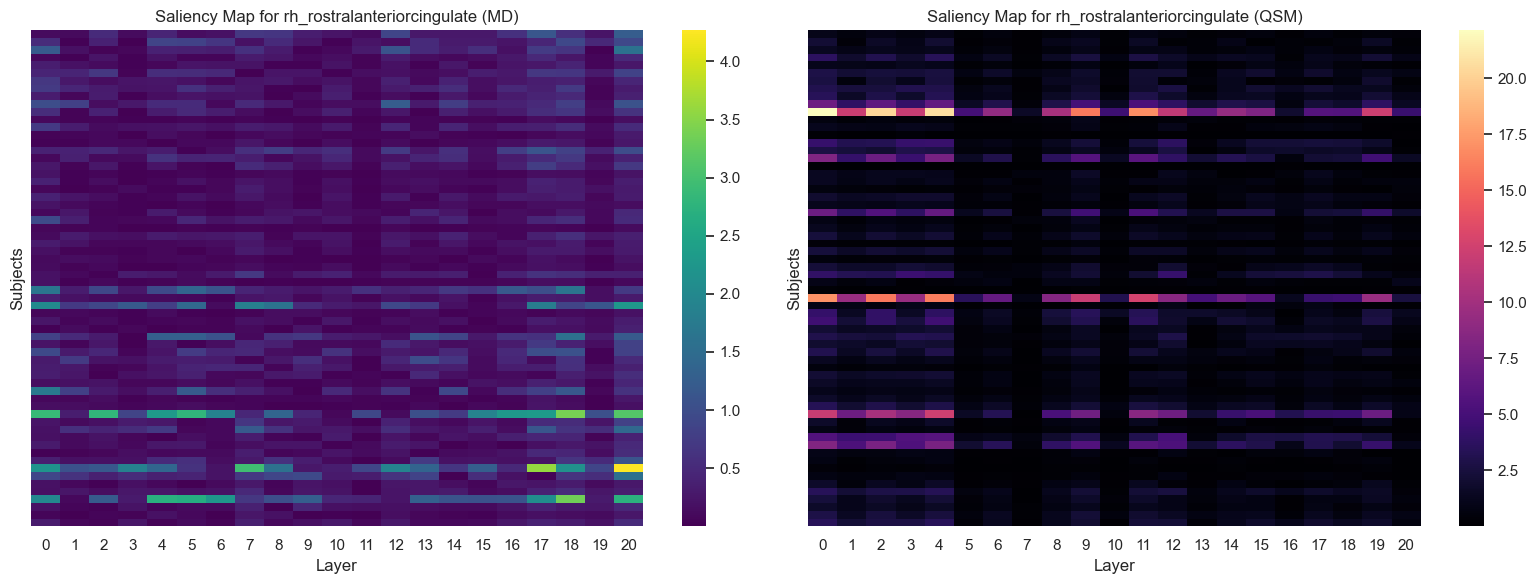

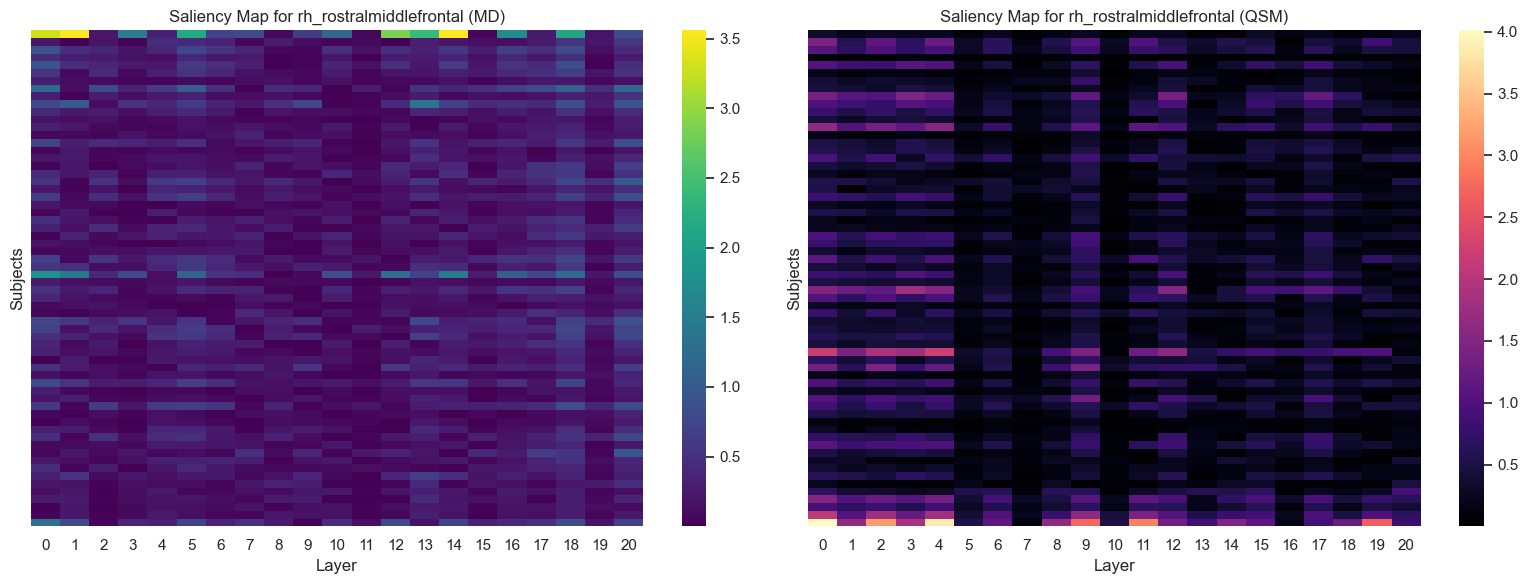

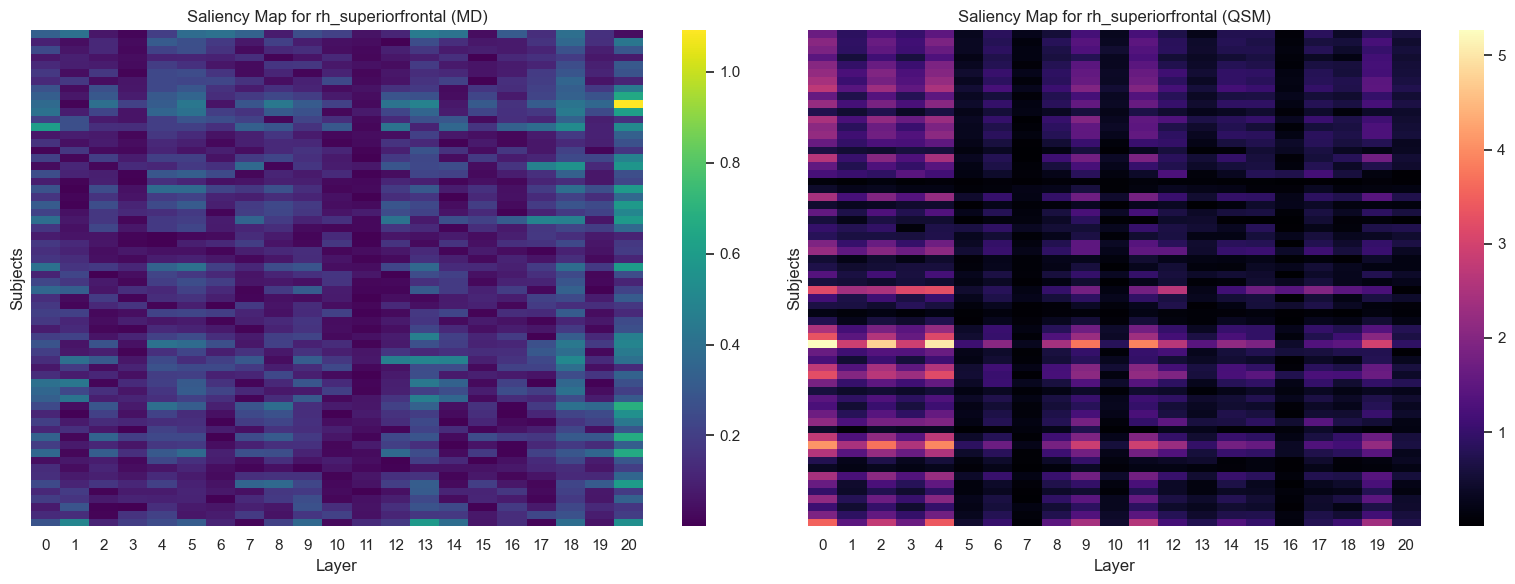

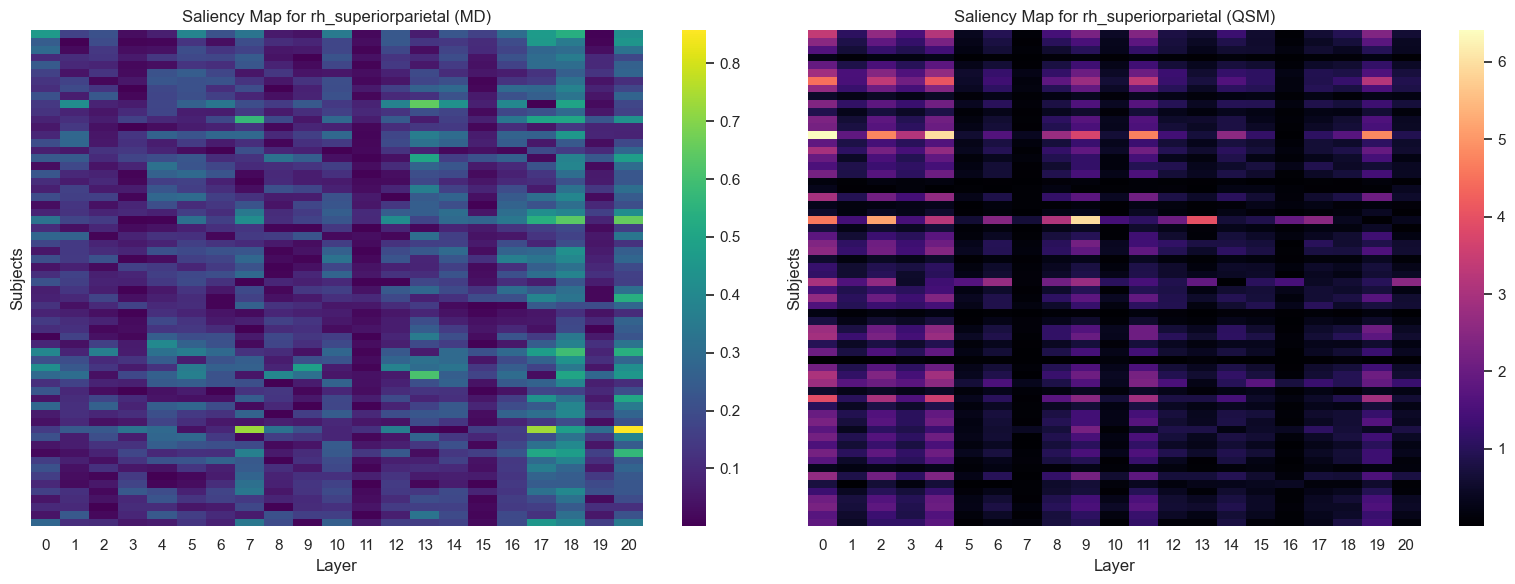

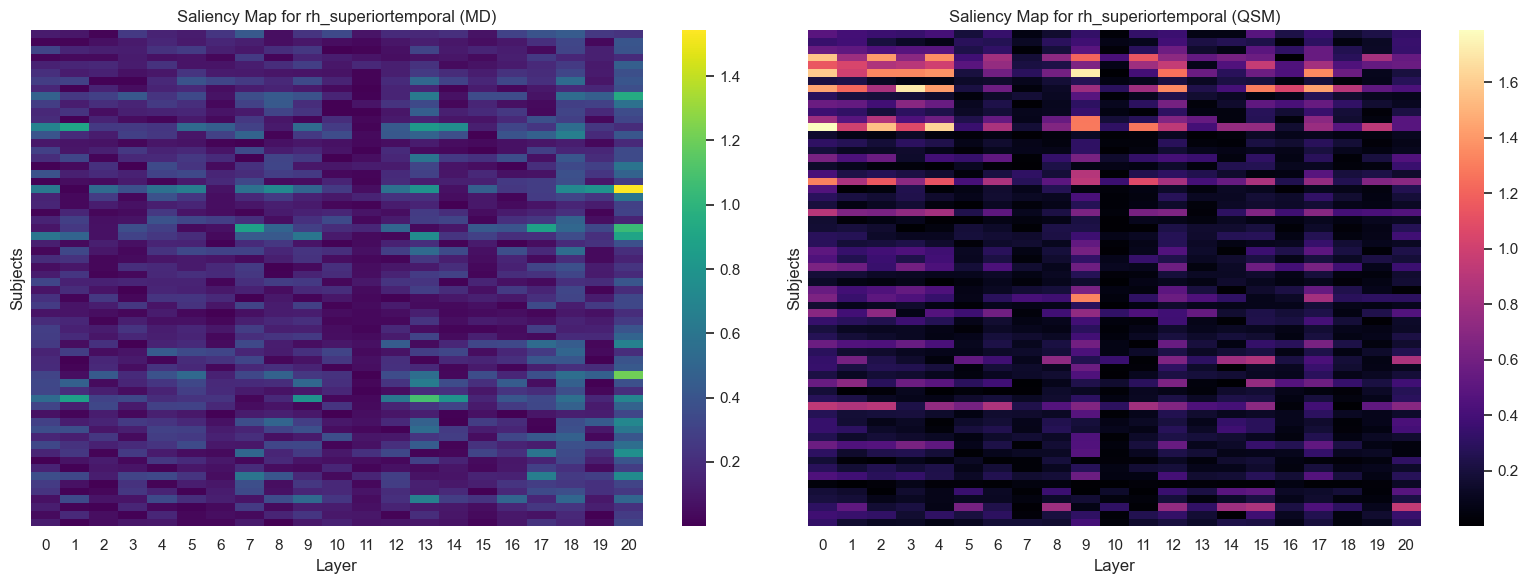

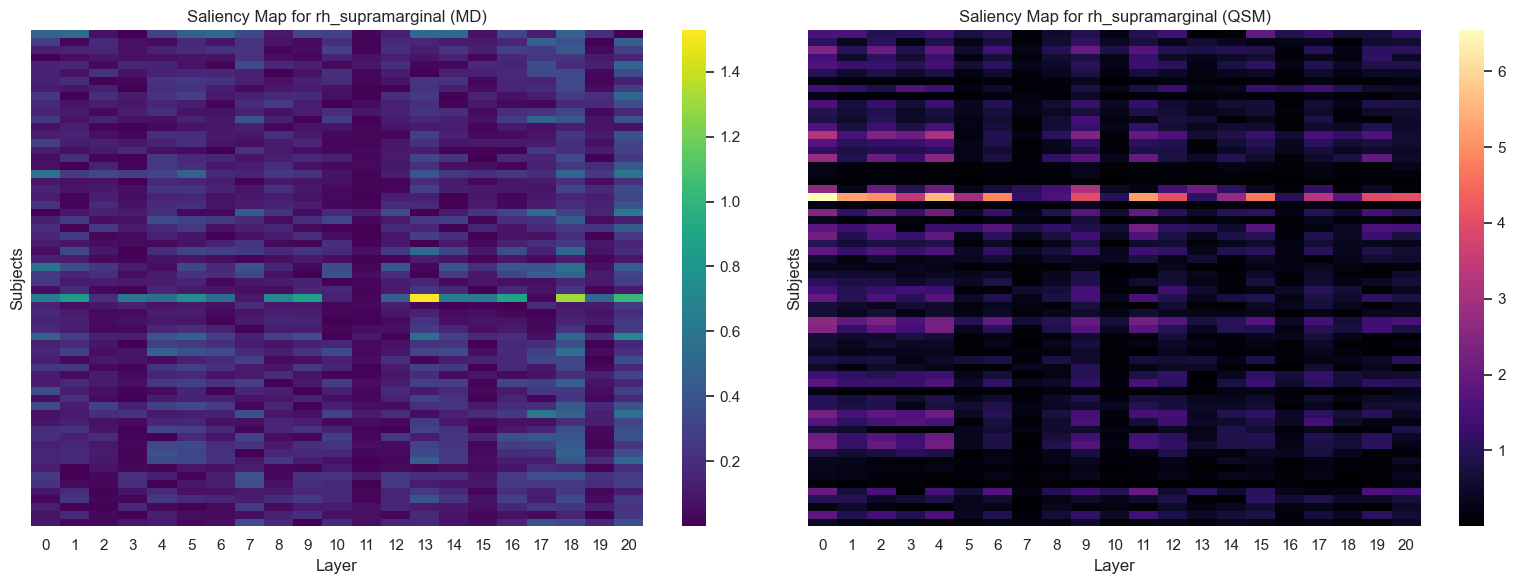

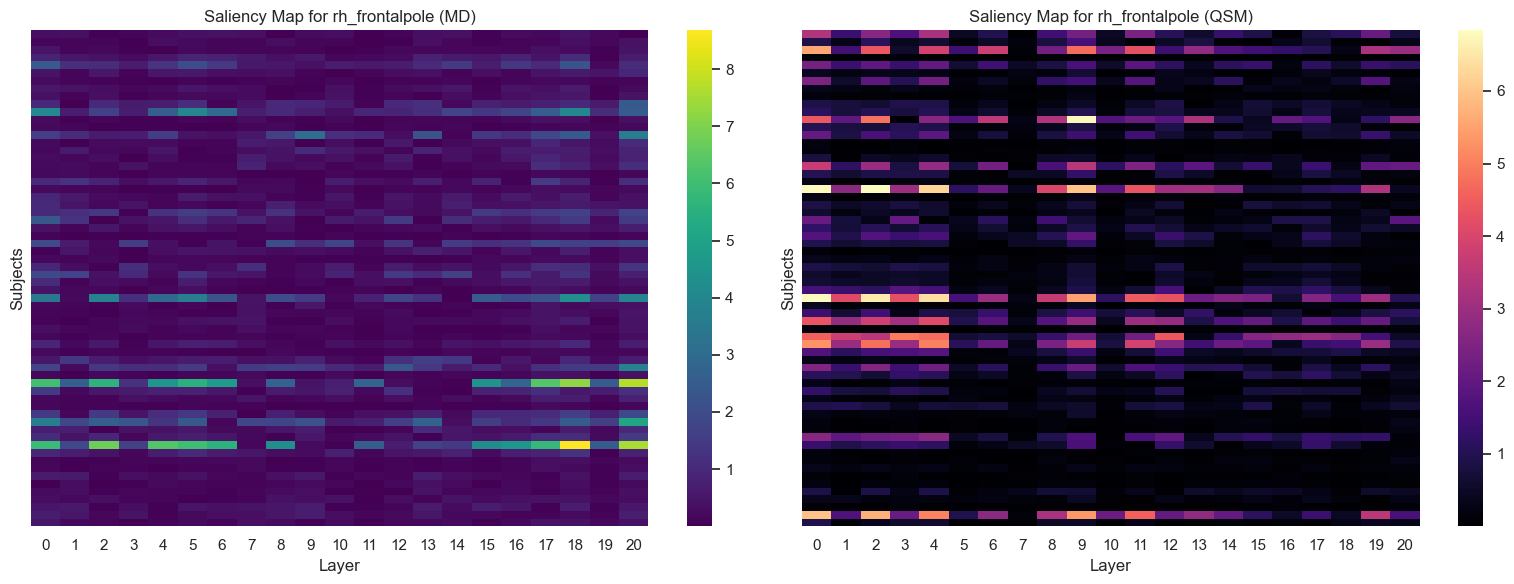

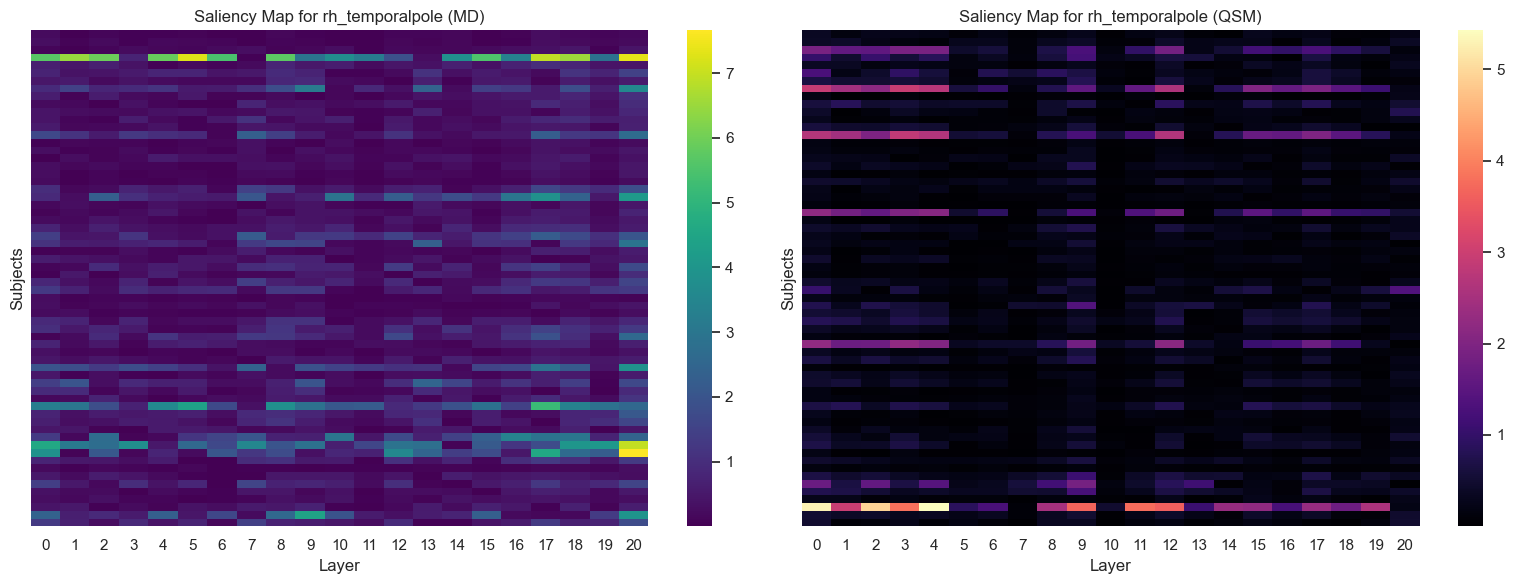

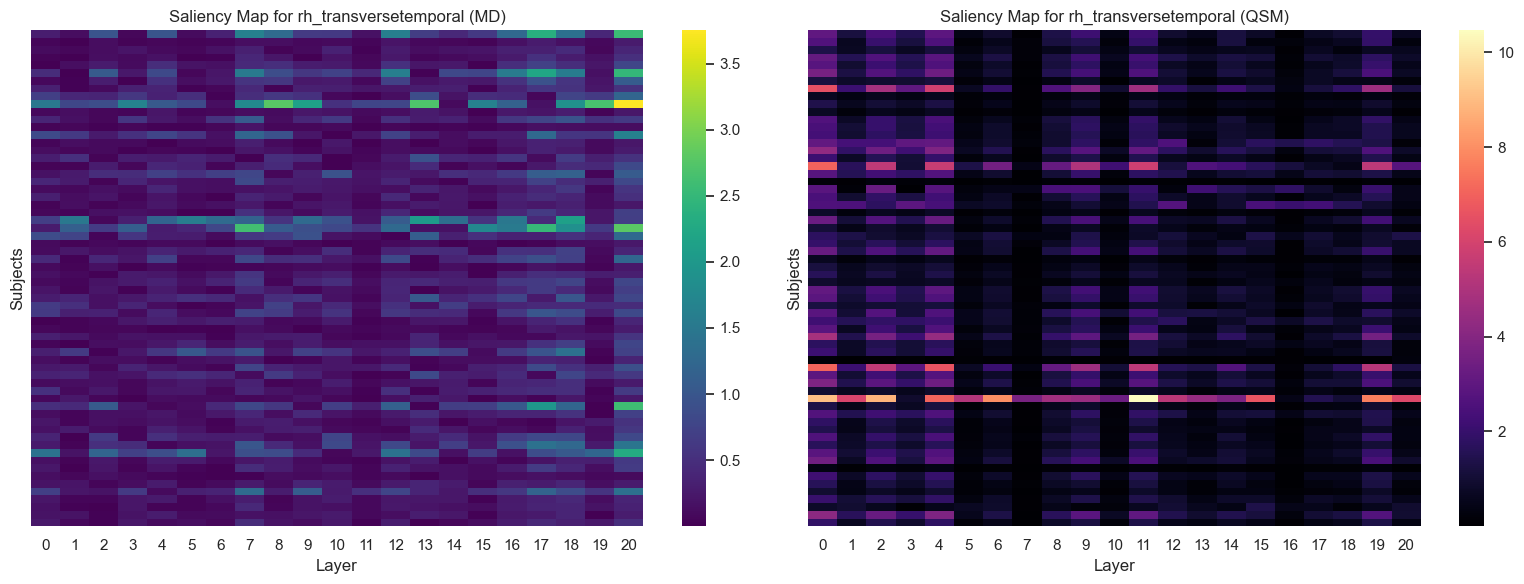

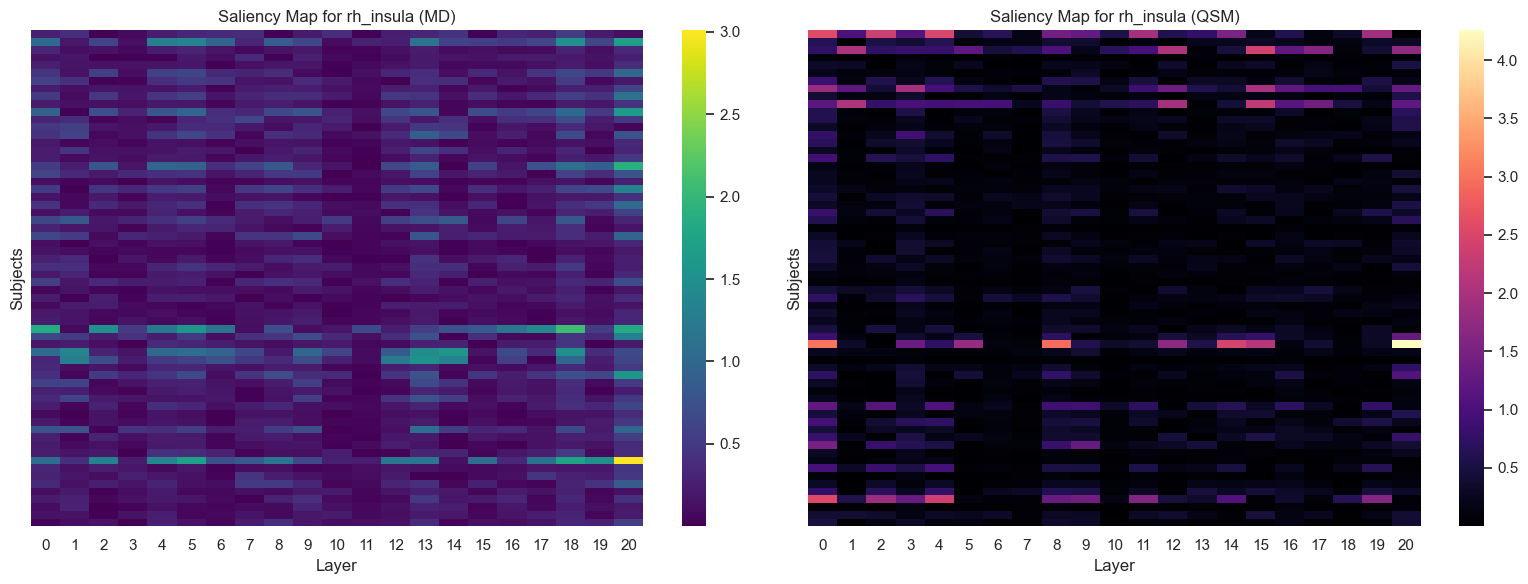

In [46]:
# Plot the saliency map of all subjects stacked
saliency_maps_md_all = [] # item: 68*22 matrix
saliency_maps_qsm_all = [] # item: 68*22 matrix
for graph in aligned_graph_list:
    saliency_map_md, saliency_map_qsm = compute_saliency_map_by_layer(model, graph)
    saliency_maps_md_all.append(saliency_map_md)
    saliency_maps_qsm_all.append(saliency_map_qsm)

# Convert to numpy array
saliency_maps_md_all = np.array(saliency_maps_md_all)
saliency_maps_qsm_all = np.array(saliency_maps_qsm_all)

# Save the saliency maps
# Create a saliency folder if it doesn't exist
import os
if not os.path.exists("saliency"):
    os.makedirs("saliency")
# Save the saliency maps as csv files for each subject
for i, graph in enumerate(aligned_graph_list):
    subject_id = graph[0].subject_id
    saliency_map_md = saliency_maps_md_all[i]
    saliency_map_qsm = saliency_maps_qsm_all[i]
    # Add column names: Depth
    column_names = [f"Depth_{j}" for j in range(saliency_map_md.shape[1])]
    # Add row names: Regions
    row_names = [f"{hemi}_{region}" for hemi in HEMIS for region in REGION_NAMES]
    # Create a DataFrame and save
    saliency_md_df = pd.DataFrame(saliency_map_md, columns=column_names, index=row_names)
    saliency_md_df.to_csv(f"saliency/saliency_{subject_id}_md.csv")

    saliency_qsm_df = pd.DataFrame(saliency_map_qsm, columns=column_names, index=row_names)
    saliency_qsm_df.to_csv(f"saliency/saliency_{subject_id}_qsm.csv")

# Visualize saliency map for all subjects
regions = []
for hemi in HEMIS:
    for region in REGION_NAMES:
        region_key = f"{hemi}_{region}"
        regions.append(region_key)

# Plot the saliency map for each region
for i, region in enumerate(regions):
    plt.figure(figsize=(16, 6))
    # MD saliency (left)
    plt.subplot(1, 2, 1)
    sns.heatmap(saliency_maps_md_all[:, i], cmap="viridis", cbar=True,
                xticklabels=np.arange(saliency_maps_md_all.shape[2]) if saliency_maps_md_all.ndim == 3 else np.arange(22),
                yticklabels=False)
    plt.title(f"Saliency Map for {region} (MD)")
    plt.xlabel("Layer")
    plt.ylabel("Subjects")

    # QSM saliency (right)
    plt.subplot(1, 2, 2)
    sns.heatmap(saliency_maps_qsm_all[:, i], cmap="magma", cbar=True,
                xticklabels=np.arange(saliency_maps_qsm_all.shape[2]) if saliency_maps_qsm_all.ndim == 3 else np.arange(22),
                yticklabels=False)
    plt.title(f"Saliency Map for {region} (QSM)")
    plt.xlabel("Layer")
    plt.ylabel("Subjects")

    plt.tight_layout()
    plt.show()

# SHAP (updated)

This section uses GNNExplainer to explain the independent influence of MD and QSM graphs. Then evaluate global attribution across modalities by assessing the SHAP values on concanated features.

## Single graph SHAP

Calculate the SHAP for individual MD and QSM graphs seperately.

In [48]:
import torch
from torch_geometric.explain import Explainer, ModelConfig
from torch_geometric.explain.algorithm import GNNExplainer
import shap
import numpy as np

# ---- STEP 1: GNNExplainer for graph features ----

# Wrap model forward for MD stream only (to analyze node features & edges)
class MDSubModel(torch.nn.Module):
    def __init__(self, full_model):
        super().__init__()
        self.full_model = full_model
        self.out_layer = torch.nn.Linear(128, 1)  # simple regressor

    def forward(self, x, edge_index, batch=None):
        x_md = F.relu(self.full_model.md_bn1(self.full_model.md_conv1(x, edge_index)))
        x_md = F.relu(self.full_model.md_bn2(self.full_model.md_conv2(x_md, edge_index)))
        x_md_res = x_md
        x_md = F.relu(self.full_model.md_bn3(self.full_model.md_conv3(x_md, edge_index)))
        x_md = x_md + x_md_res
        x_md = global_mean_pool(x_md, batch) if batch is not None else x_md.mean(dim=0, keepdim=True)
        return self.out_layer(x_md)  # [batch, 1]


# Wrap model forward for QSM stream only
class QSMSubModel(torch.nn.Module):
    def __init__(self, full_model):
        super().__init__()
        self.full_model = full_model
        self.out_layer = torch.nn.Linear(128, 1)  # simple regressor

    def forward(self, x, edge_index, batch=None):
        x_qsm = F.relu(self.full_model.qsm_bn1(self.full_model.qsm_conv1(x, edge_index)))
        x_qsm = F.relu(self.full_model.qsm_bn2(self.full_model.qsm_conv2(x_qsm, edge_index)))
        x_qsm_res = x_qsm
        x_qsm = F.relu(self.full_model.qsm_bn3(self.full_model.qsm_conv3(x_qsm, edge_index)))
        x_qsm = x_qsm + x_qsm_res
        x_qsm = global_mean_pool(x_qsm, batch) if batch is not None else x_qsm.mean(dim=0, keepdim=True)
        return self.out_layer(x_qsm)

md_submodel = MDSubModel(model).to(device)
qsm_submodel = QSMSubModel(model).to(device)

# Run GNNExplainer for each subject and node
model_config = ModelConfig(
    mode='regression',           # since your model predicts age (a scalar)
    task_level='graph',           # graph-level explanation
    return_type='raw'            # model outputs raw predictions (not logits)
)

explainer_md = Explainer(
    model=md_submodel,
    algorithm=GNNExplainer(epochs=200),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config=model_config
)

explainer_qsm = Explainer(
    model=qsm_submodel,
    algorithm=GNNExplainer(epochs=200),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config=model_config
)

# Create folder 'SHAP' to save results
os.makedirs("SHAP", exist_ok=True)
for sbj_idx, (md_graph, qsm_graph, thickness_vec) in enumerate(aligned_graph_list):
    MD_shap_array, QSM_shap_array = [], []

    batch_md = torch.zeros(md_graph.num_nodes, dtype=torch.long, device=device)
    batch_qsm = torch.zeros(qsm_graph.num_nodes, dtype=torch.long, device=device)

    exp_md = explainer_md(x=md_graph.x.to(device),
                        edge_index=md_graph.edge_index.to(device),
                        batch=batch_md)

    exp_qsm = explainer_qsm(x=qsm_graph.x.to(device),
                        edge_index=qsm_graph.edge_index.to(device),
                        batch=batch_qsm)


    MD_shap_array.append(exp_md.node_mask.cpu().numpy())
    QSM_shap_array.append(exp_qsm.node_mask.cpu().numpy())

    np.save(f"SHAP/MD_shap_values_subj_{sbj_idx}.npy", np.array(MD_shap_array))
    np.save(f"SHAP/QSM_shap_values_subj_{sbj_idx}.npy", np.array(QSM_shap_array))

    # Save the shap values in csv
    # Squeeze to remove the first dimension (1, 68, 21) -> (68, 21)
    md_shap_2d = np.squeeze(np.array(MD_shap_array), axis=0)
    qsm_shap_2d = np.squeeze(np.array(QSM_shap_array), axis=0)
    pd.DataFrame(md_shap_2d).to_csv(f"SHAP/MD_shap_values_subj_{sbj_idx}.csv", index=False)
    pd.DataFrame(qsm_shap_2d).to_csv(f"SHAP/QSM_shap_values_subj_{sbj_idx}.csv", index=False)

print("GNNExplainer shap values saved for all subjects.")

GNNExplainer shap values saved for all subjects.


## SHAP for global features

In [49]:
import os
import shap
import numpy as np
import torch

# === 1. Extract embeddings for SHAP input ===
def get_embeddings(data_md, data_qsm, data_thickness, model, device):
    model.eval()
    with torch.no_grad():
        # MD stream
        x_md = F.relu(model.md_bn1(model.md_conv1(data_md.x.to(device), data_md.edge_index.to(device))))
        x_md = F.relu(model.md_bn2(model.md_conv2(x_md, data_md.edge_index.to(device))))
        x_md_res = x_md
        x_md = F.relu(model.md_bn3(model.md_conv3(x_md, data_md.edge_index.to(device))))
        x_md = x_md + x_md_res
        batch_md = torch.zeros(data_md.num_nodes, dtype=torch.long, device=device)
        x_md = global_mean_pool(x_md, batch_md)
        x_md = model.dropout(x_md)

        # QSM stream
        x_qsm = F.relu(model.qsm_bn1(model.qsm_conv1(data_qsm.x.to(device), data_qsm.edge_index.to(device))))
        x_qsm = F.relu(model.qsm_bn2(model.qsm_conv2(x_qsm, data_qsm.edge_index.to(device))))
        x_qsm_res = x_qsm
        x_qsm = F.relu(model.qsm_bn3(model.qsm_conv3(x_qsm, data_qsm.edge_index.to(device))))
        x_qsm = x_qsm + x_qsm_res
        batch_qsm = torch.zeros(data_qsm.num_nodes, dtype=torch.long, device=device)
        x_qsm = global_mean_pool(x_qsm, batch_qsm)
        x_qsm = model.dropout(x_qsm)

        # Combine embeddings
        x = torch.cat([x_md, x_qsm, data_thickness.to(device)], dim=1)  # [1, 324]
        return x.cpu().numpy()

# === 2. Use only the MLP head (fc) for SHAP ===
mlp_head = model.fc.to(device)

def model_shap_fn(input_array):
    """
    input_array: numpy [B, 324]
    Returns model outputs [B, 1]
    """
    input_tensor = torch.tensor(input_array, dtype=torch.float32).to(device)
    with torch.no_grad():
        out = mlp_head(input_tensor)
    return out.cpu().numpy()

# === 3. Build background using ALL subjects ===
background = []
for subj_id, (md_graph, qsm_graph, thickness_vec) in enumerate(aligned_graph_list):
    thickness_vec = thickness_vec.unsqueeze(0)  # [1, 68]
    emb = get_embeddings(md_graph, qsm_graph, thickness_vec, model, device)  # [1, 324]
    background.append(emb.squeeze(0))

background = np.stack(background, axis=0)  # shape [N_subjects, 324]
print("Background shape:", background.shape)

# === 4. Run SHAP with full background ===
explainer = shap.KernelExplainer(model_shap_fn, background)

# Make folder
os.makedirs("SHAP", exist_ok=True)

# Define feature names
feature_names = [f"MD_emb_{i}" for i in range(128)] + \
                [f"QSM_emb_{i}" for i in range(128)] + \
                [f"Thickness_{r}" for r in range(68)]

# === 5. Per-subject SHAP values + aggregation ===
import pandas as pd
agg_rows = []

for subj_index, (md_graph, qsm_graph, thickness_vec) in enumerate(aligned_graph_list):
    test_emb = get_embeddings(md_graph, qsm_graph, thickness_vec.unsqueeze(0), model, device)  # [1, 324]
    shap_values = explainer.shap_values(test_emb)  # list with [array]
    shap_values = np.array(shap_values)[0]  # (324,) for regression

    # Save raw SHAP values
    np.save(f"SHAP/subject_{subj_index}_shap_values.npy", shap_values)
    pd.DataFrame(shap_values.reshape(1, -1), columns=feature_names).to_csv(f"SHAP/subject_{subj_index}_shap_values.csv", index=False)

    # Aggregate by modality
    md_contrib = np.sum(np.abs(shap_values[:128]))
    qsm_contrib = np.sum(np.abs(shap_values[128:256]))
    thickness_contrib = np.sum(np.abs(shap_values[256:]))

    agg_rows.append({
        "subject_id": subj_index,
        "MD_contrib": md_contrib,
        "QSM_contrib": qsm_contrib,
        "Thickness_contrib": thickness_contrib
    })

# Save aggregated results
df_agg = pd.DataFrame(agg_rows)
df_agg.to_csv("SHAP/aggregated_modality_importance.csv", index=False)

print("Saved per-subject SHAP values in 'SHAP/' and aggregated modality contributions in CSV.")


Background shape: (64, 324)


100%|██████████| 1/1 [00:00<00:00,  2.37it/s]

Saved per-subject SHAP values in 'SHAP/' and aggregated modality contributions in CSV.


In [ ]:
# Plot with wider rows (increase height per region)
xlabel = []
for hemi in HEMIS:
    for region in REGION_NAMES:
        region_key = f"{hemi}_{region}"
        xlabel.append(region_key)
plt.figure(figsize=(24, 18))  # Increase height from 10 to 18
plt.imshow(shap_ave, cmap='coolwarm', aspect='auto', interpolation='nearest')
plt.colorbar(label='SHAP Value')
plt.xticks(ticks=np.arange(num_depths), labels=[f"Depth {i}" for i in range(num_depths)])
plt.yticks(ticks=np.arange(n_total_columns), labels=xlabel)
plt.title('SHAP Values for Each Region and Depth')
plt.xlabel('Depth')
plt.ylabel('Region')
plt.tight_layout()
plt.show()



In [ ]:
# Read the saved SHAP values for each subject
shap_values_list = []
for graph in graph_data_list_all:
    subject_id = graph.subject_id
    shap_values = np.load(os.path.join("shap_values", f"shap_values_{subject_id}.npy"))
    shap_values_list.append(shap_values)
# Convert to numpy array
shap_values_array = np.array(shap_values_list)
# Hierarchical clustering of SHAP values (subjects)
from scipy.cluster.hierarchy import dendrogram, linkage, leaves_list
# Use subject IDs corresponding to the rows in shap_values_array
shap_subject_ids = [g.subject_id for g in graph_data_list_all]

# Cluster subjects (rows)
Z_shap = linkage(shap_values_array.reshape(shap_values_array.shape[0], -1), method='ward')
plt.figure(figsize=(10, 8))
dendrogram(Z_shap, labels=shap_subject_ids,  # Use correct subject IDs as labels
           leaf_rotation=90, leaf_font_size=10)
plt.title("Hierarchical Clustering of SHAP Values (Subjects)")
plt.xlabel("Subjects")
plt.ylabel("Distance")
plt.tight_layout()
# Do not show the grid
plt.grid(False)
plt.show()

# Group the subjects into 3 clusters based on the dendrogram
from scipy.cluster.hierarchy import fcluster
n_clusters = 4  # Set the number of clusters
clusters_shap = fcluster(Z_shap, n_clusters, criterion='maxclust')
# Create a DataFrame to store subjects and their cluster assignments
df_clusters_shap = pd.DataFrame({
    'subject_id': [str(sid).zfill(5) for sid in shap_subject_ids],
    'cluster': clusters_shap
})
# Define a color for each cluster (adjust as needed for n_clusters)
cluster_colors_shap = {
    1: "#66c2a5",
    2: "#fc8d62",
    3: "#8da0cb",
    4: "#e78ac3"
}
df_clusters_shap['color'] = df_clusters_shap['cluster'].map(cluster_colors_shap)
# Save the cluster assignments to a CSV file
df_clusters_shap.to_csv("subject_clusters_shap.csv", index=False)
# Plot the dendrogram with cluster colors
plt.figure(figsize=(10, 8))
dendrogram(Z_shap, labels=df_clusters_shap['subject_id'].values,
           leaf_rotation=90, leaf_font_size=10,
           color_threshold=0)  # Use color_threshold to color the clusters
for i, color in enumerate(df_clusters_shap['color']):
    plt.setp(plt.gca().get_xticklabels()[i], color=color)  # Set color for each subject label
plt.title("Hierarchical Clustering of SHAP Values (Subjects)")
plt.xlabel("Subjects")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.gridspec as gridspec  # <-- Add this import

# Show the clustering result on the y axis of the SHAP values
# Keep the mean absolute values of SHAP values of each region for each subject
shap_values_abs = np.abs(shap_values_array).mean(axis=2)  # Shape: [n_subjects, n_regions]
# Reorder the SHAP values rows according to the clustering order
shap_values_abs_reordered = shap_values_abs[leaves_list(Z_shap)]
plt.figure(figsize=(10, 10))
# Create a gridspec for dendrogram and heatmap side by side
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 8], wspace=0)
fig = plt.gcf()
# Plot dendrogram on the left
ax0 = plt.subplot(gs[0])
dendrogram(Z_shap, orientation='left', labels=np.array(shap_subject_ids)[leaves_list(Z_shap)],
           leaf_rotation=0, leaf_font_size=10, color_threshold=None, ax=ax0)
ax0.invert_yaxis()
ax0.axis('off')

# Plot heatmap on the right
ax1 = plt.subplot(gs[1])
sns.heatmap(shap_values_abs_reordered, cmap="viridis", cbar=True,
            xticklabels=xlabel, yticklabels=False, ax=ax1)
ax1.set_xticks(np.arange(len(xlabel)) + 0.5)
ax1.set_xticklabels(xlabel, rotation=90, ha='center')
plt.title("SHAP Values for All Subjects (Hierarchical Clustering Order)", pad=40)
plt.xlabel("Regions")
plt.tight_layout()
plt.show()

In [ ]:
# Plot histogram with x-axis being APOE-4 carrier and y-axis being the number of subjects in each cluster
df_clusters_shap = pd.merge(df_clusters_shap, df_matched[['MRI_Exam_fixed', 'genotype']], left_on='subject_id', right_on='MRI_Exam_fixed', how='left')
# Define APOE-4 carrier status
def define_apoe_status(genotype):
    if pd.isnull(genotype):
        return "Unknown"
    if "4" in str(genotype):
        return "APOE4 Carrier"
    else:
        return "Non-Carrier"
df_clusters_shap['APOE'] = df_clusters_shap['genotype'].apply(define_apoe_status)
# Plot histogram with cluster colors
plt.figure(figsize=(8, 6))
sns.histplot(data=df_clusters_shap, x='APOE', hue='cluster', multiple='stack', 
             palette=cluster_colors_shap, shrink=0.8, discrete=True)
plt.title("Distribution of APOE-4 Carrier Status Across SHAP Clusters")
plt.xlabel("APOE-4 Carrier Status")
plt.ylabel("Number of Subjects")
# Add legend with cluster colors
plt.legend(title='Cluster', loc='upper right', labels=[f'Cluster {i}' for i in cluster_colors_shap.keys()],
           bbox_to_anchor=(1.2, 1), frameon=False)
plt.tight_layout()
plt.show()

In [ ]:
# Plot histogram with x-axis being sex and y-axis being the number of subjects in each cluster
df_clusters_shap = pd.merge(df_clusters_shap, df_matched[['MRI_Exam_fixed', 'sex']], left_on='subject_id', right_on='MRI_Exam_fixed', how='left')
plt.figure(figsize=(8, 6))
sns.histplot(data=df_clusters_shap, x='sex', hue='cluster', multiple='stack',
             palette=cluster_colors_shap, shrink=0.8, discrete=True)
plt.title("Distribution of Sex Across SHAP Clusters")
plt.xlabel('Sex')
plt.ylabel("Number of Subjects")
# Add legend with cluster colors
plt.legend(title='Cluster', loc='upper right', labels=[f'Cluster {i}' for i in cluster_colors_shap.keys()],
           bbox_to_anchor=(1.2, 1), frameon=False)
plt.tight_layout()
plt.show()

In [ ]:
# Plot histogram with x-axis being Risk group and y-axis being the number of subjects in each cluster
df_clusters_shap = pd.merge(df_clusters_shap, df_matched[['MRI_Exam_fixed', 'risk_for_ad']], left_on='subject_id', right_on='MRI_Exam_fixed', how='left')
plt.figure(figsize=(8, 6))
sns.histplot(data=df_clusters_shap, x='risk_for_ad', hue='cluster', multiple='stack',
             palette=cluster_colors_shap, shrink=0.8, discrete=True)
plt.title("Distribution of Risk for AD Across SHAP Clusters")
plt.xlabel("Risk for AD")
plt.ylabel("Number of Subjects")
# Only show the x grid of 0,1,2,3
plt.xticks(ticks=[0, 1, 2, 3], labels=['No Risk', 'Familial', 'MCI', 'AD'])
# Add legend with cluster colors
plt.legend(title='Cluster', loc='upper right', labels=[f'Cluster {i}' for i in cluster_colors_shap.keys()],
           bbox_to_anchor=(1.2, 1), frameon=False)
plt.tight_layout()
plt.show()

In [ ]:
# Read the SHAP values for all subjects
shap_ave = []
for subj_id in df_results["subject_id"]:
    shap_values = np.load(os.path.join("shap_values", f"shap_values_{subj_id}.npy"))
    shap_ave.append(shap_values)  # Append the SHAP values for each subject
shap_ave = np.array(shap_ave)  # Convert to numpy array
# Average SHAP values across subjects
shap_ave = np.mean(shap_ave, axis=0)  # Shape: [n_total_columns, num_depths]
# Find the top 10 regions with the highest average absolute SHAP values
top_regions_indices = np.argsort(np.mean(np.abs(shap_ave), axis=1))[-10:]  # Get indices of top 10 regions
top_regions = [xlabel[i] for i in top_regions_indices]  # Get region names
print("Top 10 Regions with Highest Average Absolute SHAP Values:", top_regions)
# Extract the SHAP values for the top regions
# Read the shap values for the top regions
top_shap_values = []
for subj_id in df_results["subject_id"]:
    shap_values = np.load(os.path.join("shap_values", f"shap_values_{subj_id}.npy"))
    top_shap_values.append(shap_values[top_regions_indices, :])  # Extract only the top regions

# Convert to numpy array
top_shap_values = np.array(top_shap_values)
# Add the absolute shap values across layers
top_shap_values_abs = np.abs(top_shap_values).sum(axis=2)  # Sum across depths
# Visualize the top regions' SHAP values with region as x-axis and subjects as y-axis
plt.figure(figsize=(10, 10))
ax = sns.heatmap(top_shap_values_abs, cmap="viridis", cbar=True,
                 xticklabels=top_regions, yticklabels=False)
ax.set_xticks(np.arange(len(top_regions)) + 0.5)
ax.set_xticklabels(top_regions, rotation=90, ha='center')
plt.title("Top 10 Regions with Highest Average Absolute SHAP Values Across Subjects")
plt.xlabel("Top Regions")
plt.ylabel("Subjects")
plt.tight_layout()
plt.show()


In [ ]:
# Region-wise SHAP Summary
# Create a folder to save the SHAP summary plots
if not os.path.exists("shap_summary"):
    os.makedirs("shap_summary")

for region in xlabel:
    region_index = xlabel.index(region)

    plt.figure(figsize=(10, 6))
    shap_array = np.array(shap_list)  # Convert list to numpy array
    plt.imshow(shap_array[:, region_index, :], cmap='coolwarm', aspect='auto', interpolation='nearest')
    plt.colorbar(label='SHAP Value')
    plt.title(f'SHAP Values for {region}')
    plt.xlabel('Depth')
    plt.ylabel('Subjects')
    plt.xticks(ticks=np.arange(num_depths), labels=[f"{i}" for i in range(num_depths)])
    plt.yticks([])  # Remove yticks
    plt.tight_layout()
    plt.show()
    plt.savefig(f"shap_summary/shap_summary_{region}.png")